# Portfolio Optimization & Risk Analytics 

## Imports & Environment

In [ ]:
import warnings, io, zipfile, urllib.request, itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

for _pkg in ("statsmodels", "pandas_datareader"):
    try:
        __import__(_pkg)
    except ImportError:
        import sys, subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg])

%matplotlib inline
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)


Environment ready | numpy 2.3.5 | pandas 2.3.3


## Visual Theme

In [ ]:
NAVY, DARK_BLUE, BLUE, LIGHT_BLUE = "#17365D", "#2F5597", "#5B9BD5", "#9DC3E6"
TEAL, ORANGE, LIGHT_ORANGE = "#2A7F9E", "#ED7D31", "#F4B183"
DARK_GRAY, MEDIUM_GRAY, LIGHT_GRAY, VERY_LIGHT_GRAY = "#404040", "#7F7F7F", "#D9E2F3", "#F4F6F8"
GREEN, RED = "#548235", "#C00000"

STRATEGY_COLORS = {
    "Max Sharpe (Hist)": ORANGE,
    "Black-Litterman":   NAVY,
    "Min Variance":      DARK_BLUE,
    "Risk Parity":       BLUE,
    "HRP":               TEAL,
    "Equal Weight":      MEDIUM_GRAY,
    "SPY":               DARK_GRAY,
    "60/40":             LIGHT_BLUE,
    "Diversified (60/30/10)": LIGHT_ORANGE,
}
BENCHMARKS = ["SPY", "60/40", "Diversified (60/30/10)"]

def set_consulting_style():
    """Apply the house style to every subsequent matplotlib figure."""
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Aptos", "DejaVu Sans"],
        "figure.figsize": (11, 6), "figure.dpi": 150, "savefig.dpi": 150,
        "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": DARK_GRAY, "axes.labelcolor": DARK_GRAY,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "axes.grid.axis": "y",
        "grid.color": LIGHT_GRAY, "grid.linewidth": 0.8, "grid.alpha": 0.7,
        "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
        "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
        "xtick.color": DARK_GRAY, "ytick.color": DARK_GRAY,
        "legend.frameon": False, "legend.fontsize": 9,
        "lines.linewidth": 2.0, "figure.constrained_layout.use": True,
    })

set_consulting_style()

def titled(ax, title, subtitle=None, source=None):
    """Left-aligned business-takeaway title + explanatory subtitle + source note."""
    ax.set_title(title, loc="left", pad=18 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9,
                color=MEDIUM_GRAY, va="bottom", ha="left")
    if source:
        ax.figure.text(0.01, -0.02, source, fontsize=7.5, color=MEDIUM_GRAY, ha="left")

def money(x, _=None):
    return f"${x:,.0f}"

def pct_axis(ax, decimals=0):
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=decimals))

def money_axis(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(money))

def color_for(name):
    return STRATEGY_COLORS.get(name, MEDIUM_GRAY)

def style_for(name, recommended=None):
    """(color, linewidth, linestyle) — orange & thick for the recommendation."""
    if name == recommended:
        return color_for(name), 3.0, "-"
    if name in BENCHMARKS:
        return color_for(name), 1.8, "--"
    return color_for(name), 1.8, "-"


Consulting theme active | palette locked | strategy colours fixed


## Central Configuration

In [ ]:
# Single source of truth for every parameter
from datetime import date

CFG = dict(
    # Data vintage: PINNED
    # A moving end date makes every run a different dataset, so results drift and RESULT_FINGERPRINT can never match across days. Change this deliberately, then call refresh_snapshot() once to rebuild data/.
    START_DATE="2015-01-01",
    END_DATE="2026-07-25",
    DATA_DIR="data",
    USE_FROZEN_SNAPSHOT=True,      # False = always attempt a live download
    ALLOW_LIVE_FALLBACK=True,      # if no snapshot exists, try downloading
    TRADING_DAYS=252,
    BENCHMARK="SPY",
    LOOKBACK_DAYS=252,
    REBALANCE_FREQUENCY="monthly",
    MIN_OBS_FOR_ESTIMATION=200,
    # costs — charged on TOTAL TRADED NOTIONAL (= 2 x one-way turnover)
    TRANSACTION_COST_BPS=10,
    MIN_WEIGHT=0.02,
    MAX_WEIGHT=0.20,
    LONG_ONLY=True,
    # Risk-free: POINT-IN-TIME series is authoritative (see RF_SERIES / rf_at()).
    # This scalar is only a bootstrap default before the series loads, and is later
    # replaced by the LATEST available observation (never a full-sample average).
    RISK_FREE_RATE=0.03,
    RF_SERIES_ID="DGS3MO",
    BL_TAU=0.05,
    BL_DELTA_FLOOR=1.0,
    BL_DELTA_CAP=6.0,
    BL_VIEW_SPREAD=0.02,
    BL_MOMENTUM_LOOKBACK=252,
    BL_BASKET_SIZE=5,
    BLOCK_LENGTH=21,
    BLOCK_LENGTH_SENSITIVITIES=(21, 42, 63),
    N_PROJECTION_PATHS=4000,
    PROJECTION_HORIZON_YEARS=10,
    PROJECTION_CAPITAL=100_000,
    PROJECTION_REBALANCE_DAYS=21,
    N_RANDOM_PORTFOLIOS=20_000,
    RANDOM_SEED=42,
    VAR_CONFIDENCE=0.95,
)

TRANSACTION_COST_RATE = CFG["TRANSACTION_COST_BPS"] / 10_000

# Deterministic seed registry 
# Python's hash() is randomised per process (PYTHONHASHSEED), so hash-derived seeds are NOT reproducible across kernel restarts. Every seed is explicit.
SEEDS = {
    "random_portfolios": 1,
    "synthetic_prices": 2,
    "synthetic_factors": 7,
    "qa_reproducibility": 9,
    "projection_Conservative": 101,
    "projection_Balanced": 202,
    "projection_Aggressive": 303,
    "sensitivity_21": 411,
    "sensitivity_42": 422,
    "sensitivity_63": 433,
}
PROFILE_SEEDS = {"Conservative": 101, "Balanced": 202, "Aggressive": 303}

def new_rng(key):
    """Deterministic generator. `key` is a name in SEEDS or an explicit int."""
    if isinstance(key, str):
        if key not in SEEDS:
            raise KeyError(f"seed '{key}' not registered in SEEDS — add it explicitly")
        offset = SEEDS[key]
    else:
        offset = int(key)
    return np.random.default_rng(CFG["RANDOM_SEED"] + offset)

print(f"Config loaded | lookback {CFG['LOOKBACK_DAYS']}d | rebalance {CFG['REBALANCE_FREQUENCY']} | "
      f"cost {CFG['TRANSACTION_COST_BPS']}bps ({TRANSACTION_COST_RATE:.4%} of traded notional) | "
      f"bounds [{CFG['MIN_WEIGHT']:.0%}, {CFG['MAX_WEIGHT']:.0%}]")
print(f"Seeds registered explicitly: {len(SEEDS)} | base seed {CFG['RANDOM_SEED']} | no hash()-derived seeds")
print(f"Data window PINNED: {CFG['START_DATE']} -> {CFG['END_DATE']} "
      f"(frozen snapshot {'preferred' if CFG['USE_FROZEN_SNAPSHOT'] else 'disabled'})")

Config loaded | lookback 252d | rebalance monthly | cost 10bps (0.1000% of traded notional) | bounds [2%, 20%]
Seeds registered explicitly: 10 | base seed 42 | no hash()-derived seeds
Data window PINNED: 2015-01-01 -> 2026-07-25 (frozen snapshot preferred)


## Asset Taxonomy 

**Business question.** How much of the portfolio is genuinely *not equity*?

**Method.** The original labelled `IEF`, `GLD` **and `NEE`** as "defensive assets" and reported the
remainder as "equity exposure". NextEra Energy is a utility **common stock** - defensive in behaviour,
but equity in substance. Conflating the two overstates true diversification.

Three orthogonal dimensions are now tracked separately:

* **Asset class** — Equity / Fixed Income / Commodity (what the instrument *is*)
* **Sector** — GICS-style grouping (what it *does*)
* **Portfolio role** — Growth / Defensive / Diversifier (how it *behaves*)

In [ ]:
# Three-dimensional asset taxonomy 
# ticker: (asset_class, sector, portfolio_role)
ASSET_TAXONOMY = {
    "AAPL":  ("Equity", "Technology",  "Growth"),
    "MSFT":  ("Equity", "Technology",  "Growth"),
    "NVDA":  ("Equity", "Technology",  "Growth"),
    "AMZN":  ("Equity", "Technology",  "Growth"),
    "GOOGL": ("Equity", "Technology",  "Growth"),
    "META":  ("Equity", "Technology",  "Growth"),
    "JPM":   ("Equity", "Financials",  "Growth"),
    "GS":    ("Equity", "Financials",  "Growth"),
    "V":     ("Equity", "Financials",  "Growth"),
    "MA":    ("Equity", "Financials",  "Growth"),
    "LLY":   ("Equity", "Healthcare",  "Growth"),
    "UNH":   ("Equity", "Healthcare",  "Defensive"),
    "JNJ":   ("Equity", "Healthcare",  "Defensive"),
    "COST":  ("Equity", "Consumer",    "Defensive"),
    "WMT":   ("Equity", "Consumer",    "Defensive"),
    "KO":    ("Equity", "Consumer",    "Defensive"),
    "PG":    ("Equity", "Consumer",    "Defensive"),
    "XOM":   ("Equity", "Energy",      "Growth"),
    "CVX":   ("Equity", "Energy",      "Growth"),
    "CAT":   ("Equity", "Industrials", "Growth"),
    "NEE":   ("Equity", "Utilities",   "Defensive"),   # equity, NOT a bond proxy
    "PLD":   ("Equity", "Real Estate", "Diversifier"),
    "IEF":   ("Fixed Income", "Other", "Defensive"),
    "GLD":   ("Commodity",    "Other", "Diversifier"),
}
TICKERS = list(ASSET_TAXONOMY)
ASSET_CLASS = {t: v[0] for t, v in ASSET_TAXONOMY.items()}
SECTOR      = {t: v[1] for t, v in ASSET_TAXONOMY.items()}
ROLE        = {t: v[2] for t, v in ASSET_TAXONOMY.items()}

EQUITY_TICKERS       = [t for t in TICKERS if ASSET_CLASS[t] == "Equity"]
FIXED_INCOME_TICKERS = [t for t in TICKERS if ASSET_CLASS[t] == "Fixed Income"]
COMMODITY_TICKERS    = [t for t in TICKERS if ASSET_CLASS[t] == "Commodity"]
NON_EQUITY_TICKERS   = FIXED_INCOME_TICKERS + COMMODITY_TICKERS
DEFENSIVE_ROLE_TICKERS = [t for t in TICKERS if ROLE[t] == "Defensive"]   # spans asset classes

def exposure_report(weights):
    """Break a weight vector down by asset class, role and sector."""
    w = weights.reindex(TICKERS).fillna(0.0)
    by_class  = w.groupby(w.index.map(ASSET_CLASS)).sum()
    by_role   = w.groupby(w.index.map(ROLE)).sum()
    pos = w[w > 1e-6]
    by_sector = pos.groupby(pos.index.map(SECTOR)).sum().sort_values(ascending=False)
    return {"asset_class": by_class, "role": by_role, "sector": by_sector,
            "equity": float(by_class.get("Equity", 0.0)),
            "fixed_income": float(by_class.get("Fixed Income", 0.0)),
            "commodity": float(by_class.get("Commodity", 0.0)),
            "non_equity": float(by_class.get("Fixed Income", 0.0) + by_class.get("Commodity", 0.0)),
            "defensive_role": float(by_role.get("Defensive", 0.0))}

print(f"{len(TICKERS)} assets | Equity {len(EQUITY_TICKERS)} · Fixed Income {len(FIXED_INCOME_TICKERS)} · "
      f"Commodity {len(COMMODITY_TICKERS)} | Defensive-role sleeve spans {len(DEFENSIVE_ROLE_TICKERS)} names")
print("NEE reclassified: Equity / Utilities / Defensive-role (was counted as a non-equity asset)")

24 assets | Equity 22 · Fixed Income 1 · Commodity 1 | Defensive-role sleeve spans 8 names
NEE reclassified: Equity / Utilities / Defensive-role (was counted as a non-equity asset)


## Shared Primitives: Performance Metrics, Risk-free Convention & Weight Validation

**Business question:** Are two numbers labelled "Sharpe" in different sections actually computed the
same way, and do they use a risk-free rate that was knowable at the time?

**Method:** One `performance_summary()` for every table, one `validate_weights()` for every optimiser
output, and one risk-free convention.

### Risk-free rate convention 

The previous version averaged `DGS3MO` over the whole sample and used that single number at every
rebalance date, which leaks future interest rates into early estimates. This version keeps the full
series and never looks forward:

| Use | Rate used |
|-----|-----------|
| Walk-forward optimisation at date *t* | `rf_at(t)` — the latest observation on or before *t* |
| Realised Sharpe / Sortino / alpha | `RF_DAILY`, a date-aligned daily series |
| Black–Litterman δ, Π and tangency at date *t* | `rf_at(t)` |
| Policy engine (a forward-looking recommendation) | latest available observation, `RF_CURRENT` |

**Compounding convention:** The annualised Treasury yield is converted geometrically:
`rf_daily = (1 + rf_annual)^(1/252) − 1`. The same conversion is used everywhere; no simple division
by 252 appears in the notebook.

Other conventions fixed once: CAGR is geometric, arithmetic annualised is reported separately,
annualisation uses 252 days, and expected return (optimiser input) is never mixed into a table of
realised backtest returns.

In [ ]:
# Risk-free plumbing 
# Populated by the data cell. Declared here so the metric functions can close over them.
RF_SERIES = None      # annualised yield, point-in-time (index = observation dates)
RF_DAILY = None       # daily rate, aligned to the return calendar
RF_CURRENT = CFG["RISK_FREE_RATE"]

def annual_to_daily_rf(rf_annual, periods=None):
    """Geometric conversion — used EVERYWHERE. No rf/252 shortcuts in this notebook."""
    periods = periods or CFG["TRADING_DAYS"]
    return (1.0 + np.asarray(rf_annual, dtype=float)) ** (1.0 / periods) - 1.0

def rf_at(when, series=None):
    """Latest risk-free observation ON OR BEFORE `when`. Returns (rate, source_date)."""
    s = RF_SERIES if series is None else series
    if s is None or len(s) == 0:
        return float(CFG["RISK_FREE_RATE"]), pd.NaT
    hist = s.loc[:when]
    if hist.empty:                      # before the series starts: use first obs, flagged
        return float(s.iloc[0]), s.index[0]
    return float(hist.iloc[-1]), hist.index[-1]

def daily_rf_for(index, rf=None):
    """Date-aligned DAILY risk-free series for `index`.

    rf=None  -> the point-in-time RF_DAILY series (preferred)
    rf=float -> a constant ANNUAL rate, converted geometrically
    rf=Series-> an ANNUAL series, reindexed forward-filled then converted
    """
    if rf is None:
        if RF_DAILY is not None:
            return RF_DAILY.reindex(index).ffill().bfill()
        return pd.Series(annual_to_daily_rf(CFG["RISK_FREE_RATE"]), index=index)
    if np.isscalar(rf):
        return pd.Series(float(annual_to_daily_rf(float(rf))), index=index)
    return pd.Series(annual_to_daily_rf(pd.Series(rf).reindex(index).ffill().bfill()), index=index)

# Primitives
def to_returns(prices):
    return prices.pct_change().dropna(how="all")

def cumulative_wealth(r):
    return (1.0 + r).cumprod()

def cagr(r, periods=None):
    periods = periods or CFG["TRADING_DAYS"]
    r = r.dropna()
    if r.empty:
        return np.nan
    growth = float((1.0 + r).prod())
    years = len(r) / periods
    return growth ** (1.0 / years) - 1.0 if growth > 0 and years > 0 else np.nan

def arithmetic_annual(r, periods=None):
    periods = periods or CFG["TRADING_DAYS"]
    return r.dropna().mean() * periods

def ann_vol(r, periods=None):
    periods = periods or CFG["TRADING_DAYS"]
    return r.dropna().std(ddof=1) * np.sqrt(periods)

def drawdown_series(r):
    w = cumulative_wealth(r.dropna())
    return w / w.cummax() - 1.0

def max_drawdown(r):
    dd = drawdown_series(r)
    return float(dd.min()) if len(dd) else np.nan

def excess_returns(r, rf=None):
    """Daily excess return over the date-aligned point-in-time risk-free rate."""
    r = r.dropna()
    return r - daily_rf_for(r.index, rf)

def sharpe(r, rf=None, periods=None):
    periods = periods or CFG["TRADING_DAYS"]
    ex = excess_returns(r, rf)
    sd = r.dropna().std(ddof=1)
    return np.nan if sd == 0 else float(ex.mean() / sd * np.sqrt(periods))

def sortino(r, rf=None, periods=None):
    periods = periods or CFG["TRADING_DAYS"]
    ex = excess_returns(r, rf)
    dn = ex[ex < 0]
    dd = np.sqrt((dn ** 2).mean()) if len(dn) else np.nan
    return np.nan if (not dd or np.isnan(dd)) else float(ex.mean() / dd * np.sqrt(periods))

def calmar(r, periods=None):
    mdd = max_drawdown(r)
    return np.nan if (not mdd or np.isnan(mdd)) else cagr(r, periods) / abs(mdd)

def value_at_risk(r, conf=None):
    conf = conf or CFG["VAR_CONFIDENCE"]
    return float(max(-np.quantile(r.dropna(), 1 - conf), 0.0))

def cvar(r, conf=None):
    conf = conf or CFG["VAR_CONFIDENCE"]
    r = r.dropna()
    tail = r[r <= np.quantile(r, 1 - conf)]
    return float(max(-tail.mean(), 0.0)) if len(tail) else np.nan

def beta_alpha(r, bench, rf=None, periods=None):
    """CAPM beta and annualised alpha, both against the point-in-time risk-free series."""
    periods = periods or CFG["TRADING_DAYS"]
    a = pd.concat([r, bench], axis=1, join="inner").dropna()
    if len(a) < 30:
        return np.nan, np.nan
    rfd = daily_rf_for(a.index, rf)
    y = (a.iloc[:, 0] - rfd).to_numpy()
    x = (a.iloc[:, 1] - rfd).to_numpy()
    cov = np.cov(y, x)
    b = cov[0, 1] / cov[1, 1] if cov[1, 1] > 0 else np.nan
    al = (y.mean() - b * x.mean()) * periods if not np.isnan(b) else np.nan
    return float(b), float(al)

def information_ratio(r, bench, periods=None):
    periods = periods or CFG["TRADING_DAYS"]
    act = (r - bench).dropna()
    te = act.std(ddof=1)
    return np.nan if te == 0 else float(act.mean() / te * np.sqrt(periods))

def tracking_error(r, bench, periods=None):
    periods = periods or CFG["TRADING_DAYS"]
    return float((r - bench).dropna().std(ddof=1) * np.sqrt(periods))

def effective_holdings(w):
    """1 / Herfindahl index — the number of equally weighted positions this is equivalent to."""
    w = np.asarray(w, float)
    h = float((w ** 2).sum())
    return np.nan if h <= 0 else 1.0 / h

def performance_summary(returns_series, benchmark=None, cost_stats=None, name=None):
    """THE performance function — every table in this notebook uses it."""
    r = returns_series.dropna()
    out = {"CAGR": cagr(r), "Arith. Ann. Return": arithmetic_annual(r), "Volatility": ann_vol(r),
           "Sharpe": sharpe(r), "Sortino": sortino(r), "Max Drawdown": max_drawdown(r),
           "Calmar": calmar(r), "VaR 95%": value_at_risk(r), "CVaR 95%": cvar(r)}
    if benchmark is not None:
        b, a = beta_alpha(r, benchmark)
        out.update({"Beta": b, "Alpha": a,
                    "Info Ratio": information_ratio(r, benchmark.reindex(r.index)),
                    "Tracking Error": tracking_error(r, benchmark.reindex(r.index))})
    if cost_stats:
        for k in ("Gross CAGR", "Net CAGR", "CAGR drag (pp)", "Net Terminal Wealth",
                  "Terminal Wealth Drag", "Total Cost ($)", "Cost % of Gross Terminal",
                  "Avg Annual Turnover (1-way)", "Avg Annual Traded Notional",
                  "Annual Cost % of Avg Value"):
            if k in cost_stats:
                out[k] = cost_stats[k]
    return pd.Series(out, name=name)

# Weight validation 
class OptimizationError(RuntimeError):
    pass

SOLVER_LOG = []     # every solver problem, with full context
FALLBACK_LOG = []   # every fallback applied, with its validation result

def validate_weights(weights, min_weight=None, max_weight=None, tolerance=1e-6,
                     long_only=None, groups=None, label="", raise_on_fail=True):
    """Return (ok, [messages]). Checks finiteness, budget, bounds, group constraints."""
    min_weight = CFG["MIN_WEIGHT"] if min_weight is None else min_weight
    max_weight = CFG["MAX_WEIGHT"] if max_weight is None else max_weight
    long_only = CFG["LONG_ONLY"] if long_only is None else long_only
    w = np.asarray(weights, dtype=float)
    msgs = []
    if not np.all(np.isfinite(w)):
        msgs.append("non-finite weights")
    if abs(w.sum() - 1.0) > 1e-4:
        msgs.append(f"weights sum to {w.sum():.6f}, not 1")
    if long_only and (w < -tolerance).any():
        msgs.append(f"negative weight {w.min():.6f} violates long-only")
    if min_weight > 0 and (w < min_weight - 1e-4).any():
        msgs.append(f"min weight {w.min():.6f} < {min_weight}")
    if (w > max_weight + 1e-4).any():
        msgs.append(f"max weight {w.max():.6f} > {max_weight}")
    for gname, (idx, lo, hi) in (groups or {}).items():
        s = w[idx].sum()
        if s < lo - 1e-4 or s > hi + 1e-4:
            msgs.append(f"group '{gname}' = {s:.4f} outside [{lo}, {hi}]")
    ok = not msgs
    if not ok and raise_on_fail:
        raise OptimizationError(f"{label}: " + "; ".join(msgs))
    return ok, msgs


Primitives loaded | one performance_summary(), one validate_weights(), one risk-free convention


# Phase 1 - Foundation

## 1.1 Data Collection

Adjusted closes from Yahoo Finance, aligned on common trading dates, short gaps
forward-filled, tickers with excessive missing data dropped. The risk-free rate is downloaded from FRED
as a full time series (`DGS3MO`), forward-filled across non-publication days, and kept as a
point-in-time object, never collapsed to a full-sample average.

If any download fails the notebook falls back to a labelled synthetic dataset, never silently substitutes made-up numbers for real ones.

One limitation is selection bias: The universe was chosen in 2026 and contains names
that are famous because they won (NVDA, META, LLY). Removing this needs a point-in-time universe.
Every backtest and projection result below is inflated to an unknown degree by this bias.

### Data-freezing policy

Prices, the risk-free series and the Fama–French factors
are downloaded once into `data/`, every subsequent run loads from
those CSVs.


In [ ]:
# Load the frozen snapshot from data/ (no network, no synthetic) 
# This notebook reads a committed dataset. It does NOT download anything, so the numbers below are the same on every machine and every run.
import json, hashlib
from pathlib import Path

DATA_DIR   = Path(CFG["DATA_DIR"])
PRICES_CSV = DATA_DIR / "prices_adjclose.csv"
RF_CSV     = DATA_DIR / "rf_series.csv"
FF_CSV     = DATA_DIR / "ff_factors.csv"
MANIFEST   = DATA_DIR / "manifest.json"

def _sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]

def read_frozen_csv(path):
    """Read a snapshot CSV with EXACT float64 recovery.

    pandas' default C parser is fast but not correctly-rounded and reintroduces
    ~1e-11 errors, which propagate through the covariance estimate into an
    iterative SLSQP solve. float_precision='round_trip' is bitwise exact.
    """
    return pd.read_csv(path, index_col=0, parse_dates=[0],
                       float_precision="round_trip").sort_index()

def write_frozen_csv(obj, path, label=""):
    """Write, then ASSERT a bitwise round-trip. Used by QA and by any refresh."""
    df = obj.to_frame() if isinstance(obj, pd.Series) else obj.copy()
    df.index.name = df.index.name or "Date"
    df.to_csv(path)
    back = read_frozen_csv(path)
    if not (df.index.equals(back.index) and list(df.columns) == list(back.columns)
            and np.array_equal(df.to_numpy(dtype=float), back.to_numpy(dtype=float),
                               equal_nan=True)):
        raise IOError(f"{label or path}: CSV did not round-trip exactly")
    return {"sha": _sha256(path), "rows": int(len(df)), "cols": list(map(str, df.columns))}

def read_manifest():
    if not MANIFEST.exists():
        return None
    try:
        return json.loads(MANIFEST.read_text())
    except Exception:
        return None

def snapshot_status():
    """Is there an intact snapshot covering the configured universe?"""
    if not PRICES_CSV.exists():
        return {"usable": False, "reason": f"{PRICES_CSV} not found", "manifest": {}}
    header = pd.read_csv(PRICES_CSV, nrows=0, index_col=0)
    have, need = set(header.columns), set(TICKERS) | {CFG["BENCHMARK"]}
    missing = sorted(need - have)
    if missing:
        return {"usable": False, "manifest": read_manifest() or {},
                "reason": f"snapshot missing configured tickers: {missing[:6]}"}
    man = read_manifest() or {}
    meta = (man.get("files") or {}).get(PRICES_CSV.name, {})
    if meta.get("sha") and meta["sha"] != _sha256(PRICES_CSV):
        return {"usable": False, "manifest": man,
                "reason": "PRICES CSV HASH MISMATCH — file edited after snapshot"}
    return {"usable": True, "manifest": man, "sha": _sha256(PRICES_CSV),
            "hash_verified": bool(meta.get("sha")),
            "reason": "ok" if meta.get("sha") else "ok (no manifest — hash not verified)"}

def seal_snapshot():
    """Record digests of the CSVs already in data/ into manifest.json.

    No download. Run ONCE after placing the files, so that later runs can detect
    a file being edited. Sealing a file blesses whatever it currently contains,
    so only run this on files you trust.
    """
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    files, vintage = {}, None
    for f in (PRICES_CSV, RF_CSV, FF_CSV):
        if not f.exists():
            continue
        df = read_frozen_csv(f)
        files[f.name] = {"sha": _sha256(f), "rows": int(len(df)),
                         "cols": list(map(str, df.columns))}
        if f is PRICES_CSV:
            vintage = df.index.max().date().isoformat()
    MANIFEST.write_text(json.dumps({
        "vintage": vintage, "sealed_at": pd.Timestamp.now().isoformat(timespec="seconds"),
        "source": "Yahoo Finance (Adj Close) + FRED DGS3MO + Ken French 5-factor daily",
        "config": {"start": CFG["START_DATE"], "end": CFG["END_DATE"],
                   "tickers": list(TICKERS), "benchmark": CFG["BENCHMARK"]},
        "files": files}, indent=2))
    print(f"Sealed {len(files)} file(s) into {MANIFEST} | vintage {vintage}")
    return files

# Load 
_st = snapshot_status()
if not _st["usable"]:
    raise FileNotFoundError(
        f"Frozen snapshot unusable: {_st['reason']}\n"
        f"Expected {PRICES_CSV.resolve()} — check the notebook's working directory, "
        f"or rebuild the snapshot.")

_panel = read_frozen_csv(PRICES_CSV)
_panel = _panel[[c for c in _panel.columns if c in set(TICKERS) | {CFG['BENCHMARK']}]]
prices = _panel.drop(columns=[CFG["BENCHMARK"]])
benchmark_returns = _panel[CFG["BENCHMARK"]].pct_change().dropna()
daily = to_returns(prices)

DATA_VINTAGE = prices.index.max().date().isoformat()
DATA_SOURCE = f"FROZEN SNAPSHOT (vintage {DATA_VINTAGE}, sha {_st['sha']})"
IS_SYNTHETIC = False
IS_FROZEN = True

# Point-in-time risk-free series 
if not RF_CSV.exists():
    raise FileNotFoundError(f"{RF_CSV} not found — the risk-free series is required")
RF_SERIES = read_frozen_csv(RF_CSV).iloc[:, 0].dropna()
RF_SOURCE = f"FROZEN SNAPSHOT ({RF_CSV.name}, sha {_sha256(RF_CSV)})"
if RF_SERIES.index.min() > daily.index.min():
    print(f"  [!] risk-free series starts {RF_SERIES.index.min().date()}, after the first return "
          f"({daily.index.min().date()}) — early dates back-fill to the first observation")

RF_ANNUAL_ALIGNED = (RF_SERIES.reindex(daily.index.union(RF_SERIES.index))
                     .ffill().reindex(daily.index).bfill())
RF_DAILY = pd.Series(annual_to_daily_rf(RF_ANNUAL_ALIGNED.to_numpy()),
                     index=daily.index, name="rf_daily")
RF_CURRENT = float(RF_SERIES.iloc[-1])          # LATEST observation, not a sample mean
CFG["RISK_FREE_RATE"] = RF_CURRENT
RF_FULL_SAMPLE_MEAN = float(RF_SERIES.mean())   # kept ONLY so QA can prove it is unused

banner = "!" * 92
print("\n" + banner)
print(f"  PRICE SOURCE : {DATA_SOURCE}")
print(f"  DATA VINTAGE : {DATA_VINTAGE}   (hash verified: {_st.get('hash_verified', False)})")
print(f"  UNIVERSE     : {prices.shape[1]} assets | {prices.shape[0]} trading days | "
      f"{prices.index.min().date()} -> {prices.index.max().date()}")
print(f"  RF SOURCE    : {RF_SOURCE}")
print(f"  RF SERIES    : {len(RF_SERIES)} obs | {RF_SERIES.min():.2%} to {RF_SERIES.max():.2%} | "
      f"latest {RF_CURRENT:.2%} (as of {RF_SERIES.index[-1].date()})")
print(f"  RF USAGE     : point-in-time at every rebalance; full-sample mean "
      f"({RF_FULL_SAMPLE_MEAN:.2%}) is NEVER used in optimisation")
print(f"  NETWORK      : none. This notebook reads data/ only — no download path exists.")
print(banner)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  PRICE SOURCE : FROZEN SNAPSHOT (vintage 2026-07-24, sha 8ed57bec6f01fa67)
  DATA VINTAGE : 2026-07-24   (hash verified: True)
  UNIVERSE     : 24 assets | 2906 trading days | 2015-01-02 -> 2026-07-24
  RF SOURCE    : FROZEN SNAPSHOT (rf_series.csv, sha ce11aa2587b39525)
  RF SERIES    : 2891 obs | 0.00% to 5.63% | latest 3.96% (as of 2026-07-24)
  RF USAGE     : point-in-time at every rebalance; full-sample mean (2.13%) is NEVER used in optimisation
  NETWORK      : none. This notebook reads data/ only — no download path exists.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [ ]:
# Snapshot inventory
_man = read_manifest() or {}
print(f"Data directory : {DATA_DIR.resolve()}")
for f in (PRICES_CSV, RF_CSV, FF_CSV):
    if f.exists():
        meta = (_man.get("files") or {}).get(f.name, {})
        flag = "verified" if meta.get("sha") == _sha256(f) else (
               "no manifest entry" if not meta.get("sha") else "HASH MISMATCH")
        print(f"  {f.name:22s} {f.stat().st_size/1e6:6.2f} MB  sha {_sha256(f)}  [{flag}]")
    else:
        print(f"  {f.name:22s} MISSING")
if _man:
    print(f"Vintage        : {_man.get('vintage','?')}   built {_man.get('downloaded_at','?')}")
    _cfg = _man.get("config", {})
    if _cfg and (_cfg.get("end") != CFG["END_DATE"] or set(_cfg.get("tickers", [])) != set(TICKERS)):
        print("  [!] snapshot was built with a different END_DATE or ticker list — rebuild it.")
else:
    print("No manifest.json — files load fine, but their digests are not verified.")
    print("Run seal_snapshot() ONCE to record them, then re-run this notebook.")
    seal_snapshot()
print("\nTo rebuild the snapshot you need the download helpers; this notebook ships read-only")
print("so a normal run can never silently re-download and change a finished report.")

Data directory : /Users/rosenguyen/Documents/Finance Project/data
  prices_adjclose.csv      1.35 MB  sha 8ed57bec6f01fa67  [verified]
  rf_series.csv            0.06 MB  sha ce11aa2587b39525  [verified]
  ff_factors.csv           0.20 MB  sha 5f0eaf2b7a91ad34  [verified]
Vintage        : 2026-07-24   built 2026-08-01T18:19:46

To rebuild the snapshot you need the download helpers; this notebook ships read-only
so a normal run can never silently re-download and change a finished report.


In [ ]:
# Risk-free look-ahead audit 
# Proves that the rate used at each rebalance date has an observation date no later than that rebalance date. Built here on a provisional monthly grid; the QA section re-runs the same test on the FINAL rebalance schedule.
_probe_dates = daily.groupby(daily.index.to_period("M")).tail(1).index
rows = []
for d in _probe_dates:
    rate, src = rf_at(d)
    rows.append({"Rebalance date": d, "RF observation date": src,
                 "RF annualised": rate, "RF daily": annual_to_daily_rf(rate),
                 "Look-ahead free": bool(pd.notna(src) and src <= d)})
rf_audit = pd.DataFrame(rows)
RF_AUDIT_PASS = bool(rf_audit["Look-ahead free"].all())

print(f"Risk-free audit | {len(rf_audit)} dates checked | all source dates <= rebalance date: {RF_AUDIT_PASS}")
print(f"Rate actually varies over time (std = {rf_audit['RF annualised'].std():.3%}) — "
      f"a single full-sample average would be {RF_FULL_SAMPLE_MEAN:.2%} at every date")
display(pd.concat([rf_audit.head(3), rf_audit.tail(3)]).style.format({
    "Rebalance date": lambda d: d.date(),
    "RF observation date": lambda d: d.date() if pd.notna(d) else "-",
    "RF annualised": "{:.3%}", "RF daily": "{:.6%}"}))

Risk-free audit | 139 dates checked | all source dates <= rebalance date: True
Rate actually varies over time (std = 1.970%) — a single full-sample average would be 2.13% at every date


,Rebalance date,RF observation date,RF annualised,RF daily,Look-ahead free
0,2015-01-30,2015-01-30,0.020%,0.000079%,True
1,2015-02-27,2015-02-27,0.020%,0.000079%,True
2,2015-03-31,2015-03-31,0.030%,0.000119%,True
136,2026-05-29,2026-05-29,3.690%,0.014380%,True
137,2026-06-30,2026-06-30,3.870%,0.015069%,True
138,2026-07-24,2026-07-24,3.960%,0.015412%,True


## 1.2 Exploratory Analysis

**Business question:** What does the risk-return landscape look like before any optimisation?

**Method:** Annualised return/volatility plus distribution shape per asset, aggregated by the corrected
taxonomy. The cumulative-growth chart uses a log axis and greys out the crowd so one extreme winner
cannot render the others unreadable, the correlation heatmap uses a diverging blue↔orange
scale centred at zero with assets ordered by hierarchical clustering.

In [ ]:
# Descriptive statistics 
def summary_statistics(rets):
    s = pd.DataFrame(index=rets.columns)
    s["Ann. Return (geo)"] = rets.apply(cagr)
    s["Ann. Volatility"]   = rets.apply(ann_vol)
    s["Sharpe"]            = rets.apply(sharpe)
    s["Skew"]              = rets.skew()
    s["Excess Kurtosis"]   = rets.kurtosis()
    s["Max Drawdown"]      = rets.apply(max_drawdown)
    s["Asset Class"]       = s.index.map(ASSET_CLASS)
    s["Sector"]            = s.index.map(SECTOR)
    s["Role"]              = s.index.map(ROLE)
    return s.sort_values("Ann. Return (geo)", ascending=False)

stats = summary_statistics(daily)
by_class = (stats.groupby("Asset Class")[["Ann. Return (geo)", "Ann. Volatility"]]
            .mean().sort_values("Ann. Return (geo)", ascending=False))
by_sector = (stats.groupby("Sector")[["Ann. Return (geo)", "Ann. Volatility"]]
             .mean().sort_values("Ann. Return (geo)", ascending=False))

print("Mean annualised statistics by ASSET CLASS (corrected taxonomy):")
display(by_class.style.format("{:.2%}"))
print("\nBy SECTOR:")
display(by_sector.style.format("{:.2%}"))
display(stats.head(10).style.format({
    "Ann. Return (geo)": "{:.2%}", "Ann. Volatility": "{:.2%}", "Sharpe": "{:.2f}",
    "Skew": "{:.2f}", "Excess Kurtosis": "{:.1f}", "Max Drawdown": "{:.2%}"}))

Mean annualised statistics by ASSET CLASS (corrected taxonomy):


,Ann. Return (geo),Ann. Volatility
Asset Class,,
Equity,19.92%,27.57%
Commodity,10.79%,16.08%
Fixed Income,1.07%,6.56%



By SECTOR:


,Ann. Return (geo),Ann. Volatility
Sector,,
Technology,31.08%,33.98%
Industrials,24.84%,30.71%
Healthcare,18.87%,25.83%
Financials,18.01%,26.74%
Real Estate,14.53%,26.38%
Utilities,14.04%,24.60%
Consumer,12.80%,19.98%
Energy,9.30%,28.26%
Other,5.93%,11.32%


,Ann. Return (geo),Ann. Volatility,Sharpe,Skew,Excess Kurtosis,Max Drawdown,Asset Class,Sector,Role
NVDA,69.17%,48.23%,1.29,0.55,8.2,-66.34%,Equity,Technology,Growth
LLY,30.16%,29.75%,0.96,0.69,10.7,-34.48%,Equity,Healthcare,Growth
AMZN,26.51%,32.84%,0.82,0.39,6.0,-56.15%,Equity,Technology,Growth
AAPL,25.54%,28.74%,0.86,0.13,6.4,-38.52%,Equity,Technology,Growth
CAT,24.84%,30.71%,0.81,-0.01,4.2,-43.36%,Equity,Industrials,Growth
GOOGL,24.22%,29.03%,0.82,0.28,6.2,-44.32%,Equity,Technology,Growth
MSFT,21.70%,27.24%,0.78,0.09,7.6,-37.15%,Equity,Technology,Growth
COST,20.06%,21.57%,0.86,-0.29,7.8,-31.40%,Equity,Consumer,Defensive
JPM,19.33%,27.00%,0.71,0.29,13.1,-43.63%,Equity,Financials,Growth
META,19.31%,37.80%,0.60,-0.19,19.3,-76.74%,Equity,Technology,Growth


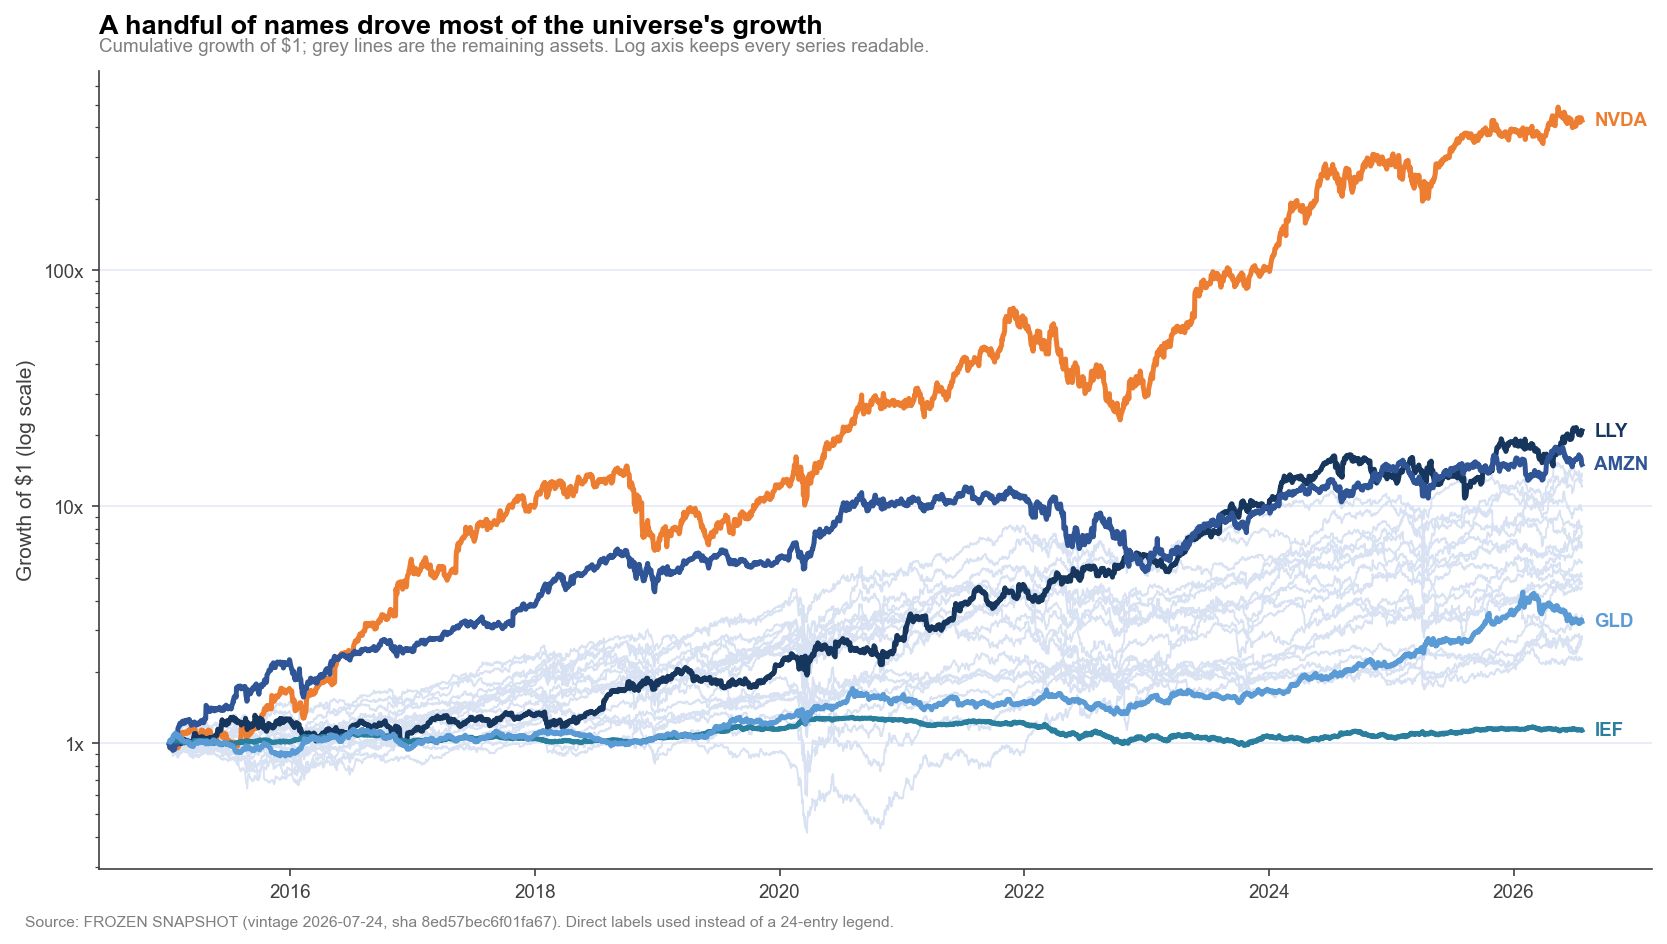

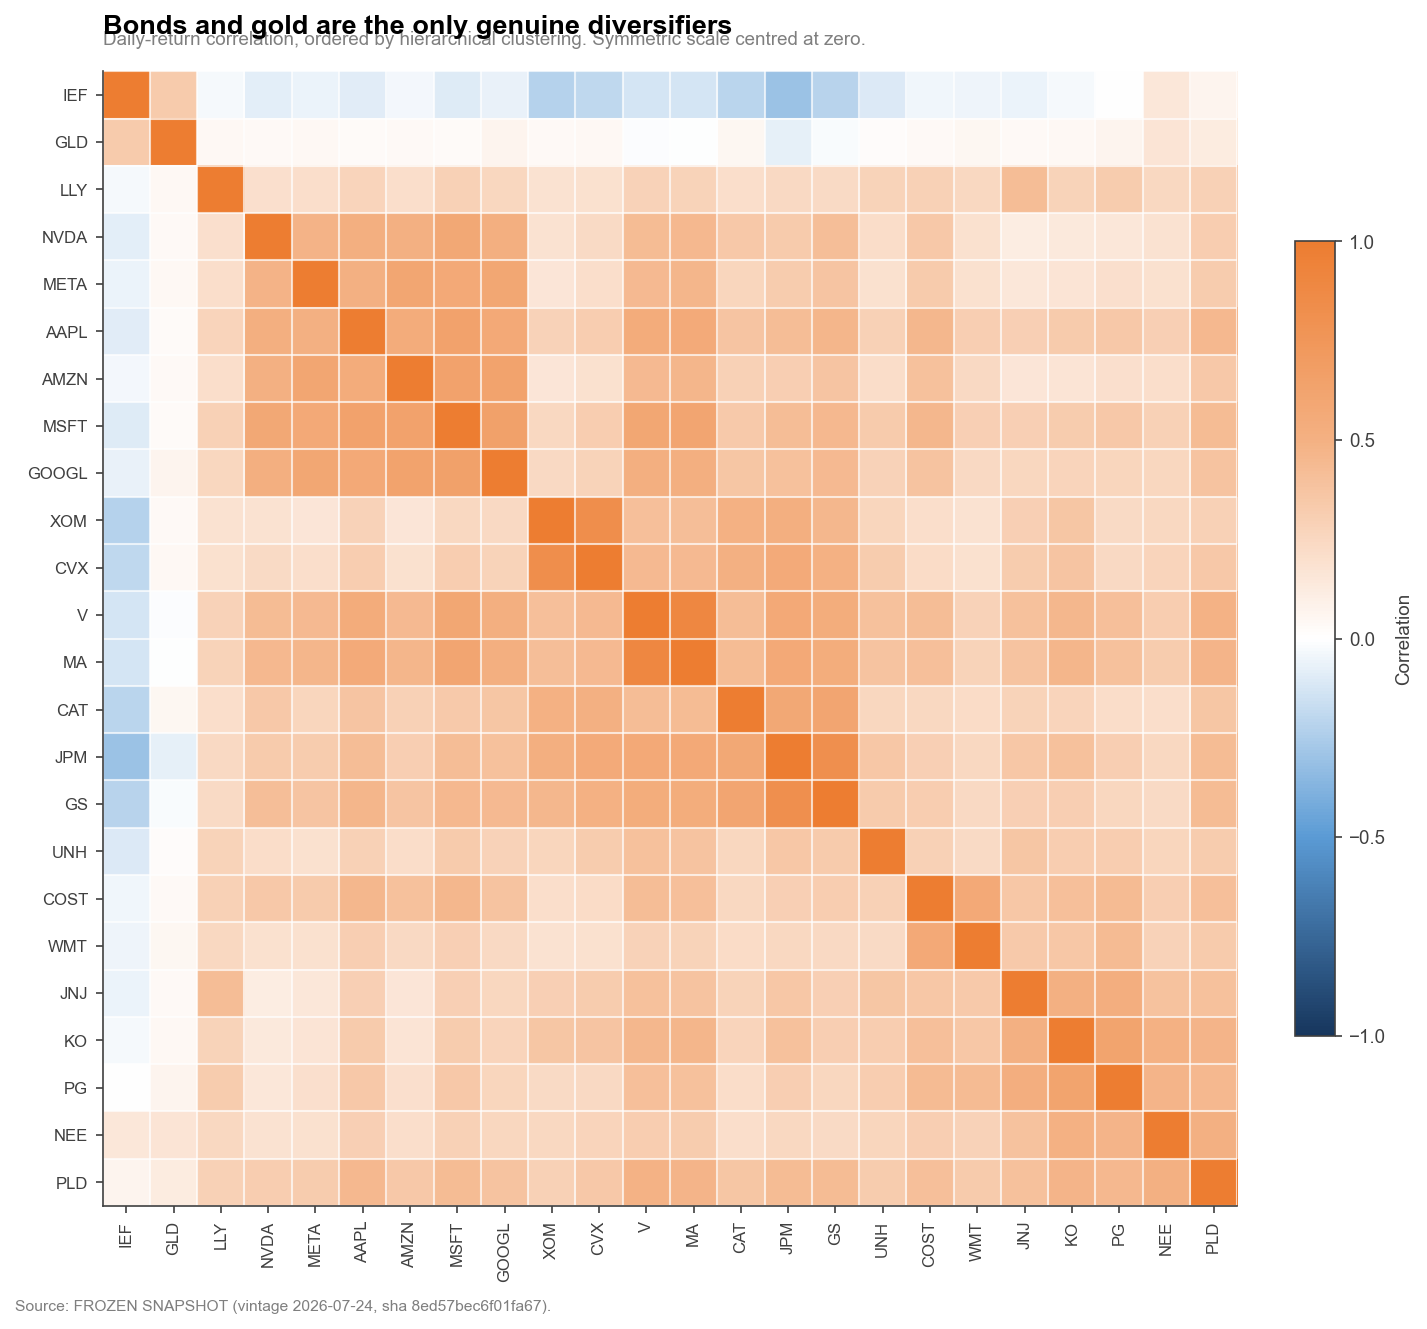

In [ ]:
# Chart 1: cumulative growth, log scale, crowd greyed out 
wealth_assets = cumulative_wealth(daily)
top3 = stats.index[:3].tolist()
defensive_names = [t for t in NON_EQUITY_TICKERS if t in wealth_assets.columns]
highlight = list(dict.fromkeys(top3 + defensive_names))

fig, ax = plt.subplots(figsize=(11, 6))
for c in wealth_assets.columns:
    if c not in highlight:
        ax.plot(wealth_assets.index, wealth_assets[c], color=LIGHT_GRAY, lw=0.9, zorder=1)
palette = [ORANGE, NAVY, DARK_BLUE, TEAL, BLUE, LIGHT_BLUE]
for i, c in enumerate(highlight):
    ax.plot(wealth_assets.index, wealth_assets[c], color=palette[i % len(palette)],
            lw=2.4, zorder=3, label=c)
    ax.annotate(c, (wealth_assets.index[-1], wealth_assets[c].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", fontsize=9,
                color=palette[i % len(palette)], va="center", fontweight="bold")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}x"))
ax.set_ylabel("Growth of $1 (log scale)")
titled(ax, "A handful of names drove most of the universe's growth",
       "Cumulative growth of $1; grey lines are the remaining assets. Log axis keeps every series readable.",
       f"Source: {DATA_SOURCE}. Direct labels used instead of a 24-entry legend.")
plt.show()

# --- Chart 2: correlation heatmap, diverging, clustered (Part 12B) ----------
corr = daily.corr()
_d = np.sqrt(np.clip(0.5 * (1 - corr), 0, None)).to_numpy()
order = corr.index[leaves_list(linkage(squareform(_d, checks=False), method="average"))]
corr_ord = corr.loc[order, order]
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "blue_orange", [NAVY, BLUE, "#FFFFFF", LIGHT_ORANGE, ORANGE])

fig, ax = plt.subplots(figsize=(9.5, 8.5))
im = ax.imshow(corr_ord.to_numpy(), cmap=cmap, vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_xticks(np.arange(-.5, len(order), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(order), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
cb = fig.colorbar(im, ax=ax, shrink=0.7, ticks=[-1, -0.5, 0, 0.5, 1])
cb.set_label("Correlation", fontsize=9)
titled(ax, "Bonds and gold are the only genuine diversifiers",
       "Daily-return correlation, ordered by hierarchical clustering. Symmetric scale centred at zero.",
       f"Source: {DATA_SOURCE}.")
plt.show()

## 1.3 Optimisation Engine: Solver Logging and Constraint-safe Fallbacks

**Business question:** When the optimiser fails, what exactly failed, where, and what did we use instead?

**Full-context solver logging:** Every solve now records the strategy, the rebalance date,
the estimation-window start and end, the solver name, `result.success`, `result.status`,
`result.message`, the specific constraint violations found by `validate_weights()`, the fallback used,
and whether that fallback itself passed validation. The rebalance date is threaded through the
strategy functions, so no walk-forward log entry has an empty context.

**Constraint-safe fallback hierarchy:** The previous fallback was equal weight clipped into
the box - which can violate group constraints (for example a fixed-income minimum). The fallback is now
tried in order and must pass the same `validate_weights()` as a normal result:

1. **Previous valid weights**, if still feasible under the current constraints.
2. **A policy baseline** allocation supplied by the caller, if feasible.
3. **A feasible projection** minimise squared distance from equal weight subject to all constraints.
4. **Stop with a clear error** if nothing feasible exists. The notebook never continues on invalid weights.

**Covariance.** Ledoit–Wolf shrinkage → symmetrised → eigenvalue-clipped to positive semi-definite.

**Expected returns.** Historical means are a baseline only, labelled noisy estimates throughout.

In [ ]:
# Moment estimation 
def expected_returns_hist(window, periods=None):
    """NOISY historical mean estimate. Not a forecast — labelled as such everywhere."""
    return window.mean() * (periods or CFG["TRADING_DAYS"])

def covariance_matrix(window, periods=None, shrinkage=True):
    """Ledoit-Wolf shrunk, symmetrised, PSD-stabilised annual covariance."""
    periods = periods or CFG["TRADING_DAYS"]
    w = window.dropna()
    if shrinkage and len(w) > len(w.columns):
        try:
            from sklearn.covariance import LedoitWolf
            c = pd.DataFrame(LedoitWolf().fit(w.to_numpy()).covariance_,
                             index=w.columns, columns=w.columns)
        except Exception:
            c = w.cov()
    else:
        c = w.cov()
    c = (c + c.T) / 2.0
    vals, vecs = np.linalg.eigh(c.to_numpy())
    if vals.min() < 1e-10:
        vals = np.clip(vals, 1e-10, None)
        c = pd.DataFrame(vecs @ np.diag(vals) @ vecs.T, index=c.index, columns=c.columns)
        c = (c + c.T) / 2.0
    return c * periods

def port_return(w, mu):
    return float(np.asarray(w) @ np.asarray(mu))

def port_vol(w, cov):
    w = np.asarray(w)
    return float(np.sqrt(max(float(w @ np.asarray(cov) @ w), 0.0)))

def port_sharpe(w, mu, cov, rf):
    v = port_vol(w, cov)
    return -np.inf if v <= 0 else (port_return(w, mu) - rf) / v

def risk_contribution(w, cov):
    w = np.asarray(w, float); M = np.asarray(cov)
    pv = float(w @ M @ w)
    if pv <= 0:
        return pd.Series(np.nan, index=getattr(cov, "index", range(len(w))))
    return pd.Series(w * (M @ w) / pv, index=getattr(cov, "index", range(len(w))))

# Constraint-safe fallback hierarchy 
def _feasible(w, min_w, max_w, groups):
    return validate_weights(w, min_w, max_w, groups=groups, raise_on_fail=False)[0]

def constrained_fallback(assets, min_w, max_w, groups=None, previous_weights=None,
                         baseline_weights=None, extra_constraints=None, label="", context=None):
    """Return (weights, fallback_type). Raises if no feasible fallback exists."""
    n = len(assets)
    # 1. previous valid weights, if still feasible
    if previous_weights is not None:
        cand = pd.Series(previous_weights).reindex(assets).fillna(0.0)
        if cand.sum() > 0:
            cand = cand / cand.sum()
            if _feasible(cand, min_w, max_w, groups):
                return cand, "previous valid weights"
    # 2. caller-supplied policy baseline
    if baseline_weights is not None:
        cand = pd.Series(baseline_weights).reindex(assets).fillna(0.0)
        if cand.sum() > 0:
            cand = cand / cand.sum()
            if _feasible(cand, min_w, max_w, groups):
                return cand, "policy baseline"
    # 3. feasible projection: closest point to equal weight satisfying ALL constraints
    eq = np.repeat(1.0 / n, n)
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}] + list(extra_constraints or [])
    res = minimize(lambda w: float(np.sum((w - eq) ** 2)), np.clip(eq, min_w, max_w) / max(np.clip(eq, min_w, max_w).sum(), 1e-12),
                   method="SLSQP", bounds=tuple((min_w, max_w) for _ in range(n)),
                   constraints=cons, options={"maxiter": 500, "ftol": 1e-12})
    cand = pd.Series(res.x, index=assets)
    if res.success and _feasible(cand, min_w, max_w, groups):
        return cand, "feasible projection toward equal weight"
    # 4. no feasible fallback -> stop loudly
    raise OptimizationError(
        f"{label}: no feasible fallback portfolio exists (context={context}). "
        f"Constraints are mutually infeasible — review bounds and group limits.")

def _log_solver(label, context, res, msgs, fallback_type, fallback_ok, fallback_msgs):
    ctx = context or {}
    SOLVER_LOG.append({
        "Strategy": label,
        "Rebalance date": ctx.get("rebalance_date", ctx.get("section", "in-sample")),
        "Window start": ctx.get("window_start"), "Window end": ctx.get("window_end"),
        "Solver": "SLSQP",
        "success": bool(getattr(res, "success", False)),
        "status": int(getattr(res, "status", -1)),
        "message": str(getattr(res, "message", "")),
        "Constraint violations": "; ".join(msgs) if msgs else "none",
        "Fallback used": fallback_type,
        "Fallback validated": fallback_ok,
    })
    FALLBACK_LOG.append({
        "Strategy": label,
        "Date / section": ctx.get("rebalance_date", ctx.get("section", "in-sample")),
        "Reason for failure": ("solver did not converge" if not getattr(res, "success", False)
                               else "; ".join(msgs)),
        "Fallback type": fallback_type,
        "Weight sum": fallback_ok["sum"], "Min weight": fallback_ok["min"],
        "Max weight": fallback_ok["max"], "Group constraints": fallback_ok["groups"],
        "Final validation": fallback_ok["result"],
    })

def optimize(objective, assets, min_w=None, max_w=None, extra_constraints=None,
             label="", context=None, groups=None, x0=None,
             previous_weights=None, baseline_weights=None):
    """Solve, CHECK success, validate, log with FULL context, fall back safely."""
    min_w = CFG["MIN_WEIGHT"] if min_w is None else min_w
    max_w = CFG["MAX_WEIGHT"] if max_w is None else max_w
    n = len(assets)
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}] + list(extra_constraints or [])
    start = np.clip(np.repeat(1.0 / n, n), min_w, max_w) if x0 is None else np.asarray(x0, float)
    start = start / start.sum()
    res = minimize(objective, start, method="SLSQP",
                   bounds=tuple((min_w, max_w) for _ in range(n)),
                   constraints=cons, options={"maxiter": 1000, "ftol": 1e-10})
    w = pd.Series(res.x, index=assets)
    ok, msgs = validate_weights(w, min_w, max_w, groups=groups, label=label, raise_on_fail=False)
    if res.success and ok:
        return w
    fb, fb_type = constrained_fallback(assets, min_w, max_w, groups=groups,
                                       previous_weights=previous_weights,
                                       baseline_weights=baseline_weights,
                                       extra_constraints=extra_constraints,
                                       label=label, context=context)
    fb_ok, fb_msgs = validate_weights(fb, min_w, max_w, groups=groups, label=label + " [fallback]",
                                      raise_on_fail=False)
    gstat = "n/a" if not groups else ("satisfied" if not any("group" in m for m in fb_msgs) else "VIOLATED")
    _log_solver(label, context, res, msgs, fb_type,
                {"sum": float(fb.sum()), "min": float(fb.min()), "max": float(fb.max()),
                 "groups": gstat, "result": "PASS" if fb_ok else "FAIL: " + "; ".join(fb_msgs)},
                fb_msgs)
    if not fb_ok:
        raise OptimizationError(f"{label}: fallback itself failed validation — {'; '.join(fb_msgs)}")
    return fb

def min_variance(mu, cov, **kw):
    C = cov.to_numpy()
    return optimize(lambda w: port_vol(w, C), list(cov.index), label="Min Variance", **kw)

def max_sharpe(mu, cov, rf=None, **kw):
    rf = RF_CURRENT if rf is None else rf
    m, C = mu.to_numpy(), cov.to_numpy()
    return optimize(lambda w: -port_sharpe(w, m, C, rf), list(cov.index), label="Max Sharpe", **kw)

def risk_parity(mu, cov, **kw):
    C, n = cov.to_numpy(), len(cov)
    def obj(w):
        pv = w @ C @ w
        return float(np.sum((w * (C @ w) - pv / n) ** 2))
    return optimize(obj, list(cov.index), label="Risk Parity", **kw)

def target_return(mu, cov, target, **kw):
    m, C = mu.to_numpy(), cov.to_numpy()
    cons = [{"type": "eq", "fun": lambda w: port_return(w, m) - target}]
    return optimize(lambda w: port_vol(w, C), list(cov.index),
                    extra_constraints=cons, label=f"Target {target:.1%}", **kw)

Optimisers loaded | full-context solver logging | 4-level constraint-safe fallback hierarchy


In [ ]:
# Hierarchical Risk Parity, validated 
def hrp_weights(window, max_w=1.0, validate=True):
    """Lopez de Prado HRP. Uses only the rows passed in (i.e. only past data)."""
    cov, corr = window.cov(), window.corr().fillna(0.0)
    dist = np.sqrt(np.clip(0.5 * (1.0 - corr), 0, None))          # correlation distance
    link = linkage(squareform(dist.to_numpy(), checks=False), method="single")
    order = corr.index[leaves_list(link)].tolist()                # quasi-diagonalisation
    assert sorted(order) == sorted(corr.index.tolist()), "quasi-diagonalisation lost assets"

    def cluster_var(items):
        sub = cov.loc[items, items]
        iv = 1.0 / np.diag(sub.to_numpy())
        iv = iv / iv.sum()
        return float((iv @ sub.to_numpy() @ iv).item())

    w = pd.Series(1.0, index=order)
    clusters = [order]
    while clusters:
        clusters = [c[a:b] for c in clusters
                    for a, b in ((0, len(c) // 2), (len(c) // 2, len(c))) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            c0, c1 = clusters[i], clusters[i + 1]
            v0, v1 = cluster_var(c0), cluster_var(c1)
            alpha = 1.0 - v0 / (v0 + v1)
            w[c0] *= alpha
            w[c1] *= 1.0 - alpha
    w = w.reindex(window.columns).fillna(0.0)
    w = w / w.sum()
    if max_w < 1.0:                       # optional cap, iteratively redistributed
        for _ in range(50):
            if w.max() <= max_w + 1e-9:
                break
            excess = (w - max_w).clip(lower=0).sum()
            w = w.clip(upper=max_w)
            room = (max_w - w).clip(lower=0)
            w = w + excess * room / room.sum() if room.sum() > 0 else w / w.sum()
        w = w / w.sum()
    if validate:
        validate_weights(w, min_weight=0.0, max_weight=max(max_w, float(w.max())) + 1e-6,
                         label="HRP", long_only=True)
    return w

_hrp_full = hrp_weights(daily)
print(f"HRP validation | weights sum = {_hrp_full.sum():.10f} | min = {_hrp_full.min():.4f} | "
      f"max = {_hrp_full.max():.4f} | non-zero = {(_hrp_full > 1e-6).sum()}/{len(_hrp_full)}")
print(f"HRP concentration | top-1 {_hrp_full.max():.1%}, top-3 {_hrp_full.nlargest(3).sum():.1%} "
      f"(concentration in low-volatility assets is expected HRP behaviour, not an implementation error)")

# Risk-parity diagnostic: target vs realised RC
_cov_full = covariance_matrix(daily)
_rp_full = risk_parity(expected_returns_hist(daily), _cov_full)
_rc = risk_contribution(_rp_full.to_numpy(), _cov_full)
rp_diag = pd.DataFrame({"Weight": _rp_full, "Target RC": 1.0 / len(_rp_full), "Realised RC": _rc})
rp_diag["Deviation"] = rp_diag["Realised RC"] - rp_diag["Target RC"]
print(f"\nRisk Parity diagnostic | max |deviation from equal RC| = "
      f"{rp_diag['Deviation'].abs().max():.4%} | RC sum = {rp_diag['Realised RC'].sum():.6f}")
display(rp_diag.sort_values("Realised RC", ascending=False).head(8)
        .style.format({"Weight": "{:.2%}", "Target RC": "{:.2%}",
                       "Realised RC": "{:.2%}", "Deviation": "{:+.2%}"}))

HRP validation | weights sum = 1.0000000000 | min = 0.0056 | max = 0.5128 | non-zero = 24/24
HRP concentration | top-1 51.3%, top-3 65.1% (concentration in low-volatility assets is expected HRP behaviour, not an implementation error)

Risk Parity diagnostic | max |deviation from equal RC| = 4.2361% | RC sum = 1.000000


,Weight,Target RC,Realised RC,Deviation
GLD,14.59%,4.17%,5.07%,+0.90%
JNJ,5.88%,4.17%,4.97%,+0.80%
KO,5.41%,4.17%,4.76%,+0.59%
PLD,3.32%,4.17%,4.74%,+0.58%
PG,5.16%,4.17%,4.60%,+0.43%
CVX,3.31%,4.17%,4.52%,+0.35%
WMT,5.08%,4.17%,4.50%,+0.33%
V,3.12%,4.17%,4.41%,+0.24%


In-sample illustration only — uses the LATEST available risk-free rate, not a full-sample average.
Random portfolios drawn from the constrained feasible set | acceptance rate 50.0%
IN-SAMPLE optimiser outputs (expected returns, NOT realised performance):


,Expected Return,Volatility,Sharpe
Min Variance,14.09%,10.11%,1.00
Max Sharpe (Hist),28.54%,17.50%,1.41
Risk Parity,16.86%,12.52%,1.03


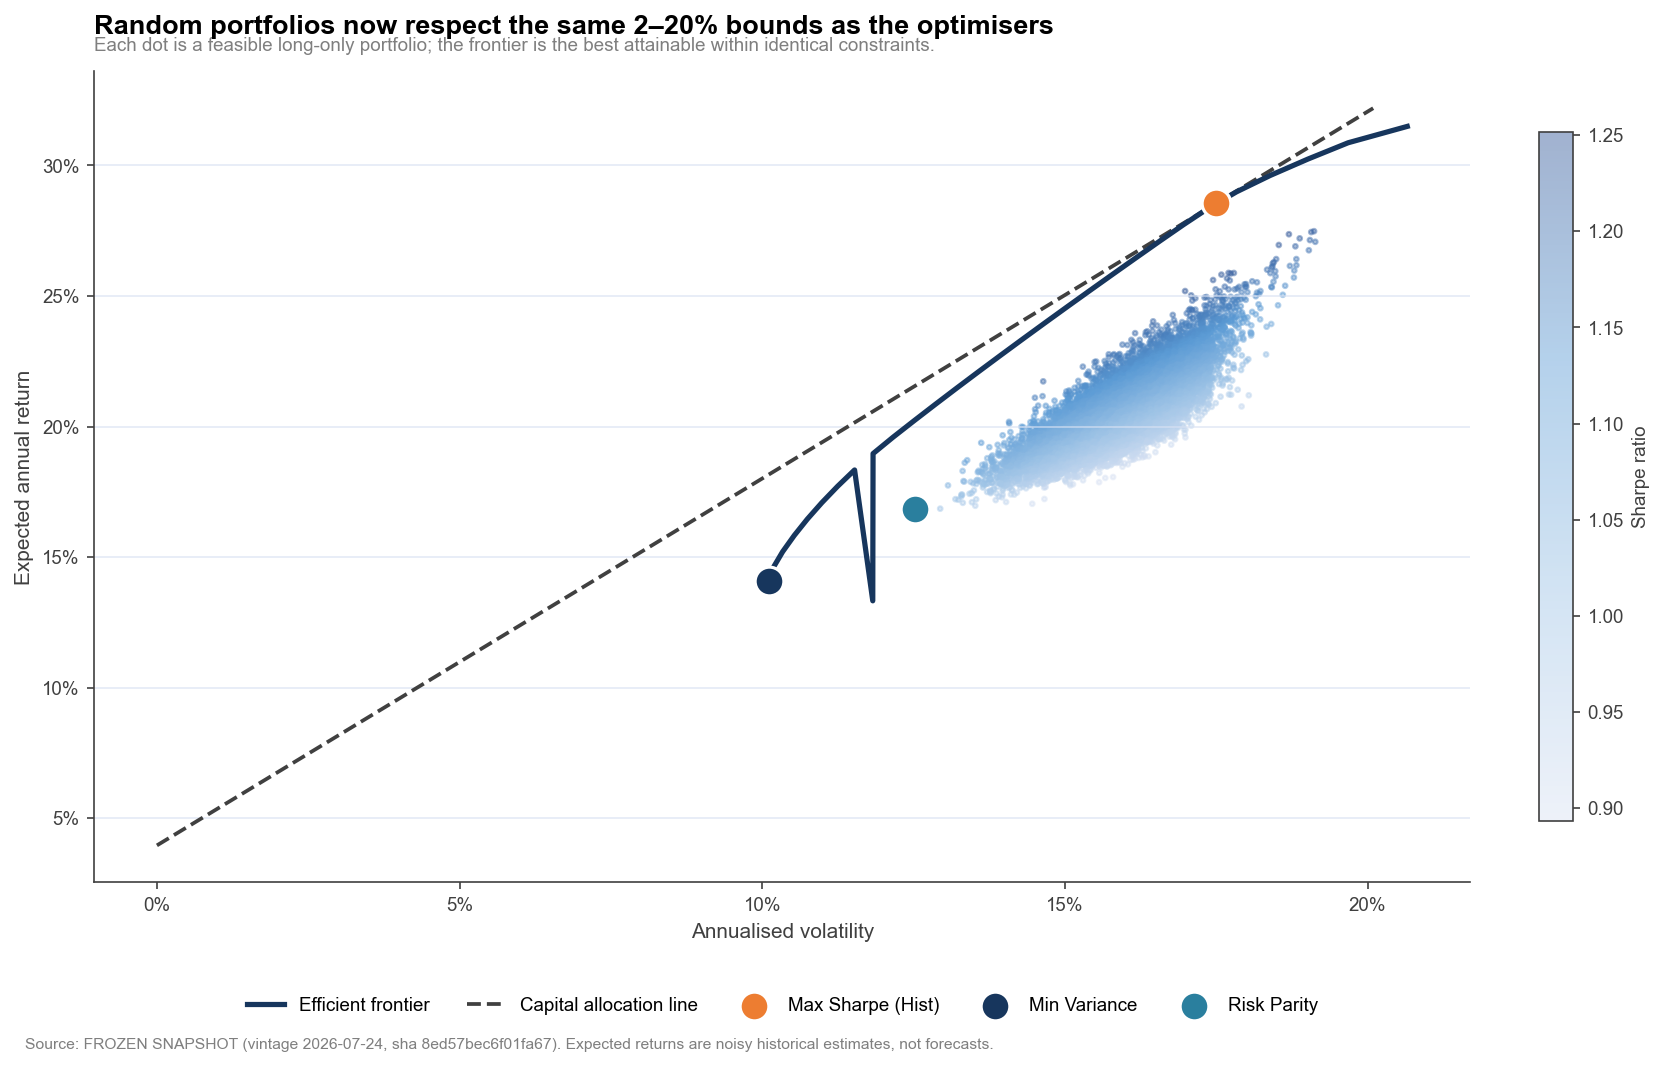

In [ ]:
# Efficient frontier vs constrained random portfolios 
mu_full  = expected_returns_hist(daily)          # noisy historical estimate
cov_full = _cov_full

def feasible_return_range(mu, min_w=None, max_w=None):
    """Highest/lowest expected return achievable inside the SAME box constraints."""
    min_w = CFG["MIN_WEIGHT"] if min_w is None else min_w
    max_w = CFG["MAX_WEIGHT"] if max_w is None else max_w
    n = len(mu)
    def extreme(best_first):
        order = mu.sort_values(ascending=not best_first).index
        w = pd.Series(min_w, index=mu.index)
        budget = 1.0 - min_w * n
        for t in order:
            add = min(max_w - min_w, budget)
            w[t] += add; budget -= add
            if budget <= 1e-12:
                break
        return float(w @ mu)
    return extreme(False), extreme(True)

def random_feasible_portfolios(mu, cov, n_port=None, min_w=None, max_w=None, seed_key="random_portfolios"):
    """Sample long-only portfolios from the SAME feasible set as the optimisers.

    The original drew unconstrained Dirichlet weights and plotted them against a
    box-constrained frontier, which is not a like-for-like comparison.
    """
    n_port = n_port or CFG["N_RANDOM_PORTFOLIOS"]
    min_w = CFG["MIN_WEIGHT"] if min_w is None else min_w
    max_w = CFG["MAX_WEIGHT"] if max_w is None else max_w
    rng, n = new_rng(seed_key), len(mu)
    free = 1.0 - min_w * n
    assert free >= 0, "min weight infeasible for this universe size"
    kept, attempts, batch = [], 0, max(n_port, 1000)
    while sum(len(k) for k in kept) < n_port and attempts < 60 * n_port:
        draw = min_w + free * rng.dirichlet(np.ones(n), size=batch)
        kept.append(draw[draw.max(axis=1) <= max_w + 1e-12])
        attempts += batch
    W = np.vstack(kept)[:n_port]
    m, C = mu.to_numpy(), cov.to_numpy()
    rets = W @ m
    vols = np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", W, C, W), 0.0))
    return pd.DataFrame({"Return": rets, "Volatility": vols,
                         "Sharpe": (rets - RF_CURRENT) / vols}), W.shape[0] / attempts

cloud, accept_rate = random_feasible_portfolios(mu_full, cov_full)
lo_ret, hi_ret = feasible_return_range(mu_full)
_rows, _infeasible = [], 0
for t in np.linspace(lo_ret, hi_ret * 0.999, 30):
    try:                                   # a target near the feasible boundary may have no solution
        w = target_return(mu_full, cov_full, t)
        _rows.append({"Return": port_return(w, mu_full), "Volatility": port_vol(w, cov_full)})
    except OptimizationError:
        _infeasible += 1
frontier = pd.DataFrame(_rows).sort_values("Volatility")
if _infeasible:
    print(f"  note: {_infeasible} frontier target(s) had no feasible solution and were skipped")

is_portfolios = {"Min Variance": min_variance(mu_full, cov_full),
                 "Max Sharpe (Hist)": max_sharpe(mu_full, cov_full),
                 "Risk Parity": _rp_full}
is_table = pd.DataFrame({k: {"Expected Return": port_return(w, mu_full),
                             "Volatility": port_vol(w, cov_full),
                             "Sharpe": port_sharpe(w.to_numpy(), mu_full.to_numpy(),
                                                   cov_full.to_numpy(), RF_CURRENT)}
                         for k, w in is_portfolios.items()}).T

print("In-sample illustration only — uses the latest available risk-free rate, not a full-sample average.")
print(f"Random portfolios drawn from the constrained feasible set | acceptance rate {accept_rate:.1%}")
print("In-sample optimiser outputs (expected returns, not realised performance):")
display(is_table.style.format({"Expected Return": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(11, 6.8))
sc = ax.scatter(cloud["Volatility"], cloud["Return"], c=cloud["Sharpe"], s=5, alpha=0.45, zorder=1,
                cmap=mpl.colors.LinearSegmentedColormap.from_list("b", [LIGHT_GRAY, LIGHT_BLUE, BLUE, DARK_BLUE]))
cb = fig.colorbar(sc, ax=ax, shrink=0.85); cb.set_label("Sharpe ratio", fontsize=9)
ax.plot(frontier["Volatility"], frontier["Return"], color=NAVY, lw=2.5, zorder=3, label="Efficient frontier")
tang = is_portfolios["Max Sharpe (Hist)"]
tv, tr = port_vol(tang, cov_full), port_return(tang, mu_full)
xs = np.linspace(0, cloud["Volatility"].max() * 1.05, 50)
ax.plot(xs, RF_CURRENT + (tr - RF_CURRENT) / tv * xs,
        color=DARK_GRAY, ls="--", lw=1.8, zorder=2, label="Capital allocation line")
for nm, col in {"Max Sharpe (Hist)": ORANGE, "Min Variance": NAVY, "Risk Parity": TEAL}.items():
    w = is_portfolios[nm]
    ax.scatter(port_vol(w, cov_full), port_return(w, mu_full), s=190, color=col,
               edgecolors="white", linewidth=1.5, zorder=5, label=nm)
ax.set_xlabel("Annualised volatility"); ax.set_ylabel("Expected annual return")
pct_axis(ax); ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, fontsize=9)
titled(ax, "Random portfolios now respect the same 2–20% bounds as the optimisers",
       "Each dot is a feasible long-only portfolio; the frontier is the best attainable within identical constraints.",
       f"Source: {DATA_SOURCE}. Expected returns are noisy historical estimates, not forecasts.")
plt.show()

# Phase 2 - Advanced Analytics

## 2.1 Fama–French Factor Exposure with Statistical Inference

Is a portfolio's excess return explained by well-known risk factors, or is there
something left over?

Five-factor regressions with Newey–West (HAC) standard errors (lag = 21 trading days) to
account for heteroskedasticity and autocorrelation in daily returns. We report coefficients, HAC
t-statistics, p-values, R² and the number of observations.

The intercept is reported as "return not explained by the included
factors", not as "genuine skill". Three reasons it may not be skill:

1. The portfolio was selected using the same sample that the regression evaluates.
2. Alpha may reflect omitted factors (momentum, quality, low-volatility).
3. Statistical significance in one sample does not establish that an effect persists.

In [ ]:
# Fama-French factors with HAC inference 
def get_fama_french(index, **_ignored):
    """Read the frozen factor snapshot. No download path."""
    if not FF_CSV.exists():
        raise FileNotFoundError(f"{FF_CSV} not found — factor analysis needs the snapshot")
    ff = read_frozen_csv(FF_CSV).reindex(index).dropna(how="all")
    return ff, f"FROZEN SNAPSHOT ({FF_CSV.name}, sha {_sha256(FF_CSV)})"

ff, FF_SOURCE = get_fama_french(daily.index)
FACTORS = [c for c in ["Mkt-RF", "SMB", "HML", "RMW", "CMA"] if c in ff.columns]
print(f"Fama-French source: {FF_SOURCE} | {len(ff)} aligned days | factors: {FACTORS}")
_ff_end = ff.dropna(how="all").index.max()
if _ff_end < daily.index.max():
    print(f"  note: factor data ends {_ff_end.date()}, {(daily.index.max()-_ff_end).days} days before "
          f"the price series (Ken French publishes with a lag). Regressions use the overlap only.")

def factor_regression(series, ff, hac_lags=21, label=""):
    """OLS with Newey-West HAC errors -> coefficients, t-stats, p-values, R2, N."""
    import statsmodels.api as sm
    cols = FACTORS + (["RF"] if "RF" in ff.columns else [])
    d = pd.concat([series.rename("y"), ff[cols]], axis=1, join="inner").dropna()
    rf_d = d["RF"] if "RF" in d.columns else daily_rf_for(d.index)
    y = d["y"] - rf_d
    X = sm.add_constant(d[FACTORS])
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    out = {"Alpha (ann.)": m.params["const"] * CFG["TRADING_DAYS"],
           "Alpha t-stat": m.tvalues["const"], "Alpha p-value": m.pvalues["const"]}
    for f in FACTORS:
        out[f] = m.params[f]
        out[f + " t"] = m.tvalues[f]
    out["R²"] = m.rsquared
    out["N obs"] = int(m.nobs)
    return pd.Series(out, name=label or series.name)

port_ms = (daily @ is_portfolios["Max Sharpe (Hist)"]).rename("Max Sharpe (in-sample)")
port_ew = daily.mean(axis=1).rename("Equal Weight")
factor_table = pd.DataFrame([factor_regression(port_ms, ff), factor_regression(port_ew, ff)])

fmt = {"Alpha (ann.)": "{:.2%}", "Alpha t-stat": "{:.2f}", "Alpha p-value": "{:.3f}",
       "R²": "{:.2f}", "N obs": "{:,.0f}"}
fmt.update({f: "{:.2f}" for f in FACTORS}); fmt.update({f + " t": "{:.2f}" for f in FACTORS})
display(factor_table.style.format(fmt))

_a = factor_table.loc["Max Sharpe (in-sample)"]
print(f"\nInterpretation: the in-sample Max-Sharpe portfolio shows {_a['Alpha (ann.)']:.2%} annualised "
      f"return not explained by the included factors (HAC t = {_a['Alpha t-stat']:.2f}, "
      f"p = {_a['Alpha p-value']:.3f}, R² = {_a['R²']:.2f}, N = {int(_a['N obs']):,}).")

Fama-French source: FROZEN SNAPSHOT (ff_factors.csv, sha 5f0eaf2b7a91ad34) | 2867 aligned days | factors: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
  note: factor data ends 2026-05-29, 56 days before the price series (Ken French publishes with a lag). Regressions use the overlap only.


,Alpha (ann.),Alpha t-stat,Alpha p-value,Mkt-RF,Mkt-RF t,SMB,SMB t,HML,HML t,RMW,RMW t,CMA,CMA t,R²,N obs
Max Sharpe (in-sample),15.60%,6.59,0.000,0.85,71.07,-0.14,-6.50,-0.22,-10.46,0.05,1.68,0.11,2.55,0.78,"2,867"
Equal Weight,6.99%,6.27,0.000,0.87,71.96,-0.15,-13.17,0.04,2.69,0.11,7.28,0.01,0.28,0.94,"2,867"



Interpretation: the in-sample Max-Sharpe portfolio shows 15.60% annualised return not explained by the included factors (HAC t = 6.59, p = 0.000, R² = 0.78, N = 2,867).
Caution: this portfolio was CHOSEN using the same sample, so the intercept is upward-biased by
construction. It is not evidence of repeatable skill.


## 2.2 Black–Litterman - Point-in-time Safe

Can we produce expected returns stable enough to optimise on, without using
information we could not have had at the time?

Four safeguards:

| Original | Problem | Current |
|----------|---------|---------|
| Prior = today's market caps | Current caps were unknowable in 2016 → look-ahead | Equal-weight equilibrium prior, explicitly disclosed as a proxy |
| Caps mixed `marketCap` with ETF `totalAssets` | Two different concepts summed together | Not used at all |
| Views hard-coded ("Tech beats Energy by 4%") | Chosen with hindsight → selection bias | Mechanical momentum views recomputed at each rebalance from trailing data only |
| Full-sample average risk-free rate | Future interest rates leaked into δ, Π and the tangency solve | `rf_at(rebalance_date)` — the latest observation on or before that date |

**Remaining limitations of the views:**

* An equal-weight prior is not the market portfolio, it over-weights small companies relative to
  cap weighting. Point-in-time market caps are unavailable in this dataset.
* The momentum view is a mechanical rule chosen by the analyst, and the spread
  (`BL_VIEW_SPREAD = 2%`) and confidence (`τ = 0.05`) are judgement calls, not estimates. Different
  values give different portfolios.
* View confidence Ω is set proportional to `τ·P·Σ·Pᵀ`, a convention — not a measurement of how
  confident we actually are.
* Because the whole universe is drawn from ex-post winners, even a "mechanical" momentum view operates
  inside a favourable selection.

In [ ]:
# Black-Litterman, point-in-time safe 
def equilibrium_prior_weights(assets):
    """DISCLOSED PROXY: equal-weight prior. Point-in-time market caps unavailable."""
    return pd.Series(1.0 / len(assets), index=assets)

def implied_risk_aversion(window, prior_w, rf, cov):
    """delta = (E[r_mkt] - rf) / var(r_mkt), using ONLY the estimation window."""
    proxy = window @ prior_w.reindex(window.columns).fillna(0.0)
    excess = arithmetic_annual(proxy) - rf
    var = float(prior_w.to_numpy() @ cov.to_numpy() @ prior_w.to_numpy())
    delta = excess / var if var > 0 else 2.5
    return float(np.clip(delta, CFG["BL_DELTA_FLOOR"], CFG["BL_DELTA_CAP"]))

def momentum_views(window, assets, k=None, spread=None):
    """Mechanical view computable at every rebalance: trailing winners beat losers.

    Returns (P, Q). No hindsight: momentum is measured on the estimation window only.
    """
    k = k or CFG["BL_BASKET_SIZE"]
    spread = CFG["BL_VIEW_SPREAD"] if spread is None else spread
    look = min(CFG["BL_MOMENTUM_LOOKBACK"], len(window))
    mom = (1.0 + window.tail(look)).prod() - 1.0
    winners, losers = mom.nlargest(k).index, mom.nsmallest(k).index
    row = pd.Series(0.0, index=assets)
    row[winners] = 1.0 / k
    row[losers] = -1.0 / k
    return row.to_numpy().reshape(1, -1), np.array([[spread]])

def black_litterman_posterior(cov, prior_w, rf, delta, P, Q, tau=None):
    """Master formula. Returns TOTAL expected returns (excess + rf)."""
    tau = CFG["BL_TAU"] if tau is None else tau
    S = cov.to_numpy()
    w = prior_w.reindex(cov.index).fillna(0.0).to_numpy().reshape(-1, 1)
    pi = delta * S @ w                                            # equilibrium excess returns
    P = np.atleast_2d(P).astype(float); Q = np.asarray(Q, float).reshape(-1, 1)
    omega = np.diag(np.diag(P @ (tau * S) @ P.T))
    omega[omega <= 0] = 1e-10
    tsi = np.linalg.inv(tau * S)
    oi = np.linalg.inv(omega)
    post = np.linalg.inv(tsi + P.T @ oi @ P) @ (tsi @ pi + P.T @ oi @ Q)
    return (pd.Series(pi.ravel() + rf, index=cov.index, name="Equilibrium"),
            pd.Series(post.ravel() + rf, index=cov.index, name="Black-Litterman"), delta)

def bl_expected_returns(window, rf=None, context=None, **opt_kw):
    """End-to-end BL estimate from one estimation window (no future data used).

    `rf` MUST be the point-in-time rate at the rebalance date during walk-forward use.
    """
    rf = RF_CURRENT if rf is None else rf
    cov = covariance_matrix(window)
    prior = equilibrium_prior_weights(window.columns)
    delta = implied_risk_aversion(window, prior, rf, cov)
    P, Q = momentum_views(window, list(window.columns))
    pi, post, _ = black_litterman_posterior(cov, prior, rf, delta, P, Q)
    return post, pi, cov, delta

# In-sample illustration (for comparison only — the real test is the backtest)
_rf_now, _rf_src = rf_at(daily.index[-1])
bl_post, bl_pi, _covbl, bl_delta = bl_expected_returns(daily, rf=_rf_now)
bl_compare = pd.concat([mu_full.rename("Historical mean (noisy)"),
                        bl_pi.rename("Equilibrium Π"), bl_post.rename("Black-Litterman")], axis=1)
print(f"Risk-free used here: {_rf_now:.3%} observed {_rf_src.date()} (latest available, not a sample mean)")
print(f"Implied risk aversion δ = {bl_delta:.2f} | prior = equal-weight proxy (disclosed) | "
      f"views = trailing-momentum, spread {CFG['BL_VIEW_SPREAD']:.1%}")
display(bl_compare.sort_values("Black-Litterman", ascending=False).head(8).style.format("{:.2%}"))
print(f"Dispersion of estimates (std across assets): historical {mu_full.std():.2%} -> "
      f"BL {bl_post.std():.2%}  (BL shrinks extreme estimates toward the equilibrium)")

Risk-free used here: 3.960% observed 2026-07-24 (latest available, not a sample mean)
Implied risk aversion δ = 6.00 | prior = equal-weight proxy (disclosed) | views = trailing-momentum, spread 2.0%


,Historical mean (noisy),Equilibrium Π,Black-Litterman
NVDA,64.15%,32.39%,32.33%
META,24.86%,25.92%,25.27%
GS,21.02%,23.49%,24.10%
AAPL,26.88%,23.58%,23.76%
AMZN,28.89%,23.68%,23.50%
GOOGL,25.90%,23.13%,23.30%
MSFT,23.35%,23.30%,23.00%
MA,20.05%,23.14%,22.95%


Dispersion of estimates (std across assets): historical 11.70% -> BL 6.43%  (BL shrinks extreme estimates toward the equilibrium)


## 2.3 The Walk-forward Backtest Engine

**Business question:** If we had actually run these strategies, paying costs and never seeing the
future, what would have happened?

### What this revision fixes

**A. Invalid final rebalance removed.** The previous schedule took the last trading day of
every month in the data, including the final - incomplete - month. That produced a rebalance with
no holding period: turnover and a transaction cost were recorded for a trade that was never held.
A rebalance date is now valid only if it is the last trading day of a completed month,
has at least one subsequent trading day, and is not the last observation in the dataset.
A month-by-month audit table below shows every inclusion and exclusion with its reason.

**B. Initial transaction cost now flows through the results** The previous simulator computed
the first day's return against post-cost wealth, so the initial purchase cost was recorded in the
cost total but never reduced the return path. The value series now begins with an explicit
gross-capital observation at the first rebalance date, before trading:

```
value[rd₀]      = initial capital                (gross, pre-trade)
wealth          = initial capital × (1 − cost)   (post-trade)
value[rd₀ + 1d] = wealth × (1 + r₁)
```

so `pct_change()` on that series carries the cost into the first return, and from there into net CAGR,
net Sharpe and terminal wealth. The cost is charged once — it is not also subtracted from the
return, which would double-count it.

**Turnover conventions, stated explicitly.**

| Quantity | Definition | At the initial purchase |
|---|---|---|
| Traded notional | `Σ\|w_target − w_pretrade\|` | **100%** (buying the whole portfolio from cash) |
| One-way turnover | `0.5 × Σ\|w_target − w_pretrade\|` | **50%** |
| Transaction cost | `traded notional × rate` | `100% × 10bps` |

The ×0.5 exists so a matched sell-and-buy is not counted twice. The initial purchase has no matching
sell, so its "50% one-way turnover" understates the trading actually done — which is why costs are
charged on traded notional, and why the initial turnover is reported separately and excluded from
the average ongoing turnover statistic.

**C. Look-ahead.** The estimation window ends on the rebalance date, the holding period starts the
next trading day; the risk-free rate is `rf_at(rebalance_date)`. All three are audited.

**D. Ablation-ready.** The simulator takes explicit flags (`drift`, `turnover_vs_pretrade`, `cost_mode`)
so the original implementation can be reproduced and each correction isolated, rather than
asserting which correction mattered most.

In [ ]:
# Valid rebalance schedule with month-by-month audit 
def build_rebalance_schedule(returns, lookback=None, min_obs=None):
    """Last trading day of each COMPLETED month that also has a holding period.

    Returns (DatetimeIndex, audit DataFrame). Every month in the sample appears in
    the audit table with an explicit inclusion or exclusion reason.
    """
    lookback = lookback or CFG["LOOKBACK_DAYS"]
    min_obs = min_obs or CFG["MIN_OBS_FOR_ESTIMATION"]
    idx = returns.index
    periods = idx.to_period("M")
    last_period = periods.max()
    last_obs = idx.max()
    need = max(lookback, min_obs)

    rows, selected = [], []
    for per, grp in returns.groupby(periods):
        d = grp.index.max()
        expected_eom = pd.Period(per, freq="M").end_time.normalize()
        expected_trading = idx[idx <= expected_eom].max() if (idx <= expected_eom).any() else pd.NaT
        complete = per != last_period          # the final month in the data is partial by construction
        has_history = returns.loc[:d].shape[0] >= need
        has_future = d < last_obs
        include = bool(complete and has_history and has_future)
        if not complete:
            reason = "excluded — final month in dataset is incomplete (no confirmed month-end)"
        elif not has_history:
            reason = f"excluded — only {returns.loc[:d].shape[0]} obs, needs {need}"
        elif not has_future:
            reason = "excluded — no subsequent trading day (holding period would be empty)"
        else:
            reason = "included"
        rows.append({"Month": str(per), "Expected final trading date": expected_trading,
                     "Selected rebalance date": d if include else pd.NaT,
                     "Month complete": complete, "Sufficient history": has_history,
                     "Has holding period": has_future, "Decision": reason})
        if include:
            selected.append(d)

    dates = pd.DatetimeIndex(selected)
    for i, r in enumerate(rows):
        if r["Decision"] != "included":
            r["Holding start"], r["Holding end"] = pd.NaT, pd.NaT
    for i, d in enumerate(dates):
        end = dates[i + 1] if i + 1 < len(dates) else last_obs
        nxt = idx[idx > d]
        row = next(r for r in rows if r["Selected rebalance date"] == d)
        row["Holding start"] = nxt.min() if len(nxt) else pd.NaT
        row["Holding end"] = end
    audit = pd.DataFrame(rows)[["Month", "Expected final trading date", "Selected rebalance date",
                                "Month complete", "Sufficient history", "Has holding period",
                                "Holding start", "Holding end", "Decision"]]
    return dates, audit

def legacy_rebalance_dates(returns):
    """The ORIGINAL notebook's date logic — calendar month-ends silently dropped
    when they are not trading days. Kept only to drive the Part 8 ablation."""
    return pd.DatetimeIndex([d for d in returns.resample("ME").last().index if d in returns.index])

REBAL_DATES, SCHEDULE_AUDIT = build_rebalance_schedule(daily)
LEGACY_DATES = legacy_rebalance_dates(daily)

print(f"Valid rebalance dates: {len(REBAL_DATES)} | {REBAL_DATES.min().date()} -> {REBAL_DATES.max().date()}")
print(f"Months examined: {len(SCHEDULE_AUDIT)} | included {int((SCHEDULE_AUDIT['Decision']=='included').sum())} | "
      f"excluded {int((SCHEDULE_AUDIT['Decision']!='included').sum())}")
print(f"Last dataset date {daily.index.max().date()} is NOT a rebalance date: "
      f"{daily.index.max() not in REBAL_DATES}")
print(f"All rebalance dates are valid trading dates: {bool(REBAL_DATES.isin(daily.index).all())}")
for reason in SCHEDULE_AUDIT.loc[SCHEDULE_AUDIT["Decision"] != "included", "Decision"].unique():
    n = int((SCHEDULE_AUDIT["Decision"] == reason).sum())
    print(f"   {n:>3} month(s): {reason}")

Valid rebalance dates: 126 | 2016-01-29 -> 2026-06-30
Months examined: 139 | included 126 | excluded 13
Last dataset date 2026-07-24 is NOT a rebalance date: True
All rebalance dates are valid trading dates: True
     1 month(s): excluded — only 19 obs, needs 252
     1 month(s): excluded — only 38 obs, needs 252
     1 month(s): excluded — only 60 obs, needs 252
     1 month(s): excluded — only 81 obs, needs 252
     1 month(s): excluded — only 101 obs, needs 252
     1 month(s): excluded — only 123 obs, needs 252
     1 month(s): excluded — only 145 obs, needs 252
     1 month(s): excluded — only 166 obs, needs 252
     1 month(s): excluded — only 187 obs, needs 252
     1 month(s): excluded — only 209 obs, needs 252
     1 month(s): excluded — only 229 obs, needs 252
     1 month(s): excluded — only 251 obs, needs 252
     1 month(s): excluded — final month in dataset is incomplete (no confirmed month-end)


In [ ]:
# Monthly schedule audit table 
_show = pd.concat([SCHEDULE_AUDIT.head(4), SCHEDULE_AUDIT.tail(4)])
display(_show.style.format({
    "Expected final trading date": lambda d: d.date() if pd.notna(d) else "-",
    "Selected rebalance date": lambda d: d.date() if pd.notna(d) else "-",
    "Holding start": lambda d: d.date() if pd.notna(d) else "-",
    "Holding end": lambda d: d.date() if pd.notna(d) else "-"}))
print("The first rows are excluded for insufficient estimation history; the final row is excluded")
print("because an incomplete month cannot supply a confirmed month-end or a holding period.")

,Month,Expected final trading date,Selected rebalance date,Month complete,Sufficient history,Has holding period,Holding start,Holding end,Decision
0,2015-01,2015-01-30,-,True,False,True,-,-,"excluded — only 19 obs, needs 252"
1,2015-02,2015-02-27,-,True,False,True,-,-,"excluded — only 38 obs, needs 252"
2,2015-03,2015-03-31,-,True,False,True,-,-,"excluded — only 60 obs, needs 252"
3,2015-04,2015-04-30,-,True,False,True,-,-,"excluded — only 81 obs, needs 252"
135,2026-04,2026-04-30,2026-04-30,True,True,True,2026-05-01,2026-05-29,included
136,2026-05,2026-05-29,2026-05-29,True,True,True,2026-06-01,2026-06-30,included
137,2026-06,2026-06-30,2026-06-30,True,True,True,2026-07-01,2026-07-24,included
138,2026-07,2026-07-24,-,False,True,False,-,-,excluded — final month in dataset is incomplete (no confirmed month-end)


The first rows are excluded for insufficient estimation history; the final row is excluded
because an incomplete month cannot supply a confirmed month-end or a holding period.


In [ ]:
# Simulator: explicit gross-capital anchor + ablation flags
def simulate_portfolio(schedule, returns, cost_rate=None, initial_capital=1.0,
                       drift=True, turnover_vs_pretrade=True, cost_mode="value"):
    """Simulate a rebalanced portfolio and return (daily_returns, values, log, raw).

    drift=True                -> asset-level holdings compound and weights drift (correct)
    drift=False               -> holding returns applied to fixed target weights daily (original-like)
    turnover_vs_pretrade=True -> turnover measured against DRIFTED pre-trade weights (correct)
    cost_mode="value"         -> cost deducted from portfolio wealth at each rebalance (correct)
    cost_mode="first_day_return" -> cost subtracted from the first return of the segment (original-like)
    cost_mode="none"          -> costless

    The value series begins with an explicit GROSS capital observation at the first
    rebalance date, so the initial purchase cost flows into the first return (Part 2).
    """
    cost_rate = TRANSACTION_COST_RATE if cost_rate is None else cost_rate
    if cost_mode == "none":
        cost_rate = 0.0
    dates = sorted(schedule)
    idx, cols = returns.index, returns.columns
    last_obs = idx.max()

    value_parts = [pd.Series([float(initial_capital)], index=[dates[0]])]   # gross anchor
    holdings, prev_target, log, total_cost = None, None, [], 0.0

    for i, rd in enumerate(dates):
        target = schedule[rd].reindex(cols).fillna(0.0)
        if holdings is None:
            value = float(initial_capital)
            pretrade_w = pd.Series(0.0, index=cols)
        else:
            value = float(holdings.sum())
            pretrade_w = holdings / value if value > 0 else pd.Series(0.0, index=cols)
        ref_w = pretrade_w if turnover_vs_pretrade else (
            prev_target if prev_target is not None else pd.Series(0.0, index=cols))
        traded_notional = float((target - ref_w).abs().sum())
        one_way = 0.5 * traded_notional
        cost_frac = traded_notional * cost_rate
        cost_paid = value * cost_frac
        total_cost += cost_paid

        start_value = value - cost_paid if cost_mode == "value" else value
        holdings_pre = start_value * target

        end = dates[i + 1] if i + 1 < len(dates) else last_obs
        seg = returns.loc[(idx > rd) & (idx <= end)]
        log.append({"Rebalance": rd, "One-way turnover": one_way,
                    "Traded notional": traded_notional, "Cost paid": cost_paid,
                    "Value before trade": value, "Holding days": len(seg)})
        if seg.empty:
            continue

        if drift:
            growth = (1.0 + seg).cumprod()
            raw_vals = growth.mul(holdings_pre, axis=1).sum(axis=1)
            port_r = raw_vals / raw_vals.shift(1)
            port_r.iloc[0] = raw_vals.iloc[0] / start_value
            port_r = port_r - 1.0
            drifted_w = growth.iloc[-1] * target
            drifted_w = drifted_w / drifted_w.sum()
        else:
            port_r = seg @ target                      # implicit DAILY rebalancing to target
            drifted_w = target.copy()

        if cost_mode == "first_day_return":
            port_r = port_r.copy()
            port_r.iloc[0] = port_r.iloc[0] - cost_frac

        seg_values = start_value * (1.0 + port_r).cumprod()
        value_parts.append(seg_values)
        holdings = drifted_w * float(seg_values.iloc[-1])
        prev_target = target

    values = pd.concat(value_parts).sort_index()
    values = values[~values.index.duplicated(keep="first")]
    daily_ret = values.pct_change().dropna()
    log = pd.DataFrame(log)
    raw = {"initial_capital": float(initial_capital),
           "initial_cost": float(log["Cost paid"].iloc[0]),
           "total_cost": float(total_cost),
           "terminal_wealth": float(values.iloc[-1]),
           "mean_value": float(values.mean()),
           "n_rebalances": int(len(log)),
           "sum_one_way": float(log["One-way turnover"].sum()),
           "sum_traded_notional": float(log["Traded notional"].sum()),
           "ongoing_one_way": float(log["One-way turnover"].iloc[1:].mean()) if len(log) > 1 else np.nan,
           "initial_one_way": float(log["One-way turnover"].iloc[0]),
           "empty_holding_periods": int((log["Holding days"] == 0).sum())}
    return daily_ret, values, log, raw

# Cost reporting: gross vs net 
def evaluate_strategy(schedule, returns, cost_rate=None, initial_capital=1.0, **flags):
    """Run the same weight schedule with and without costs; return both plus cost metrics."""
    cost_rate = TRANSACTION_COST_RATE if cost_rate is None else cost_rate
    net_r, net_v, log, raw = simulate_portfolio(schedule, returns, cost_rate=cost_rate,
                                                initial_capital=initial_capital, **flags)
    gross_r, gross_v, _lg, graw = simulate_portfolio(schedule, returns, cost_rate=0.0,
                                                     initial_capital=initial_capital, **flags)
    years = max(len(net_r) / CFG["TRADING_DAYS"], 1e-9)
    g_cagr, n_cagr = cagr(gross_r), cagr(net_r)
    stats = {
        "Gross CAGR": g_cagr, "Net CAGR": n_cagr,
        "CAGR drag (pp)": (g_cagr - n_cagr) * 100 if np.isfinite(g_cagr) and np.isfinite(n_cagr) else np.nan,
        "Gross Terminal Wealth": graw["terminal_wealth"],
        "Net Terminal Wealth": raw["terminal_wealth"],
        "Terminal Wealth Drag": (graw["terminal_wealth"] - raw["terminal_wealth"]) / graw["terminal_wealth"]
                                if graw["terminal_wealth"] > 0 else np.nan,
        "Total Cost ($)": raw["total_cost"],
        "Cost % of Gross Terminal": raw["total_cost"] / graw["terminal_wealth"] if graw["terminal_wealth"] > 0 else np.nan,
        "Total Cost % of Initial": raw["total_cost"] / raw["initial_capital"],   # secondary diagnostic only
        "Avg Annual Turnover (1-way)": raw["sum_one_way"] / years,
        "Avg Annual Traded Notional": raw["sum_traded_notional"] / years,
        "Annual Cost % of Avg Value": (raw["total_cost"] / years) / raw["mean_value"] if raw["mean_value"] > 0 else np.nan,
        "Initial one-way turnover": raw["initial_one_way"],
        "Initial cost ($)": raw["initial_cost"],
        "Rebalances": raw["n_rebalances"],
        "Empty holding periods": raw["empty_holding_periods"],
    }
    return {"net_returns": net_r, "gross_returns": gross_r, "net_values": net_v,
            "gross_values": gross_v, "log": log, "raw": raw, "stats": stats}

print("Simulator loaded | gross-capital anchor carries the initial cost into returns")
print("Cost convention: charged on TRADED NOTIONAL; turnover reported one-way (0.5 x traded notional)")
print("Ablation flags available: drift / turnover_vs_pretrade / cost_mode")

Simulator loaded | gross-capital anchor carries the initial cost into returns
Cost convention: charged on TRADED NOTIONAL; turnover reported one-way (0.5 x traded notional)
Ablation flags available: drift / turnover_vs_pretrade / cost_mode


In [ ]:
# Strategies: point-in-time rf + full context threading
STRATEGY_FUNCS = {}

def register_strategy(name):
    def deco(fn):
        STRATEGY_FUNCS[name] = fn
        return fn
    return deco

@register_strategy("Equal Weight")
def _s_ew(window, rf, ctx):
    return pd.Series(1.0 / window.shape[1], index=window.columns)

@register_strategy("Min Variance")
def _s_mv(window, rf, ctx):
    return min_variance(expected_returns_hist(window), covariance_matrix(window),
                        context=ctx, previous_weights=ctx.get("previous_weights"))

@register_strategy("Max Sharpe (Hist)")
def _s_ms(window, rf, ctx):
    return max_sharpe(expected_returns_hist(window), covariance_matrix(window), rf=rf,
                      context=ctx, previous_weights=ctx.get("previous_weights"))

@register_strategy("Risk Parity")
def _s_rp(window, rf, ctx):
    return risk_parity(expected_returns_hist(window), covariance_matrix(window),
                       context=ctx, previous_weights=ctx.get("previous_weights"))

@register_strategy("HRP")
def _s_hrp(window, rf, ctx):
    return hrp_weights(window, max_w=CFG["MAX_WEIGHT"])

@register_strategy("Black-Litterman")
def _s_bl(window, rf, ctx):
    post, _pi, cov, _d = bl_expected_returns(window, rf=rf)      # rf is point-in-time
    return max_sharpe(post, cov, rf=rf, context=ctx,
                      previous_weights=ctx.get("previous_weights"))

def build_weight_schedule(strategy, returns, rebal_dates, lookback=None):
    """{date: weights} using ONLY data up to and including that date, plus an audit log.

    The risk-free rate at each date is rf_at(date) — never a full-sample average.
    Full context (date, window bounds, previous weights) is threaded into the optimiser
    so no solver-log entry can have an empty context.
    """
    lookback = lookback or CFG["LOOKBACK_DAYS"]
    fn, schedule, audit, prev_w = STRATEGY_FUNCS[strategy], {}, [], None
    idx = returns.index
    for i, rd in enumerate(rebal_dates):
        window = returns.loc[:rd].tail(lookback)
        rf_val, rf_src = rf_at(rd)
        nxt = idx[idx > rd]
        hold_start = nxt.min() if len(nxt) else pd.NaT
        hold_end = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else idx.max()
        ctx = {"strategy": strategy, "rebalance_date": rd,
               "window_start": window.index.min(), "window_end": window.index.max(),
               "previous_weights": prev_w}
        w = fn(window, rf_val, ctx).reindex(returns.columns).fillna(0.0)
        w = w / w.sum()
        schedule[rd] = w
        prev_w = w
        audit.append({"Rebalance": rd, "Est. start": window.index.min(), "Est. end": window.index.max(),
                      "Hold start": hold_start, "Hold end": hold_end, "Est. obs": len(window),
                      "RF used": rf_val, "RF obs date": rf_src})
    return schedule, pd.DataFrame(audit)

print("Strategies registered:", ", ".join(STRATEGY_FUNCS))

Strategies registered: Equal Weight, Min Variance, Max Sharpe (Hist), Risk Parity, HRP, Black-Litterman


In [ ]:
# Build schedules, audit look-ahead, simulate 
STRATEGIES = ["Max Sharpe (Hist)", "Black-Litterman", "Min Variance",
              "Risk Parity", "HRP", "Equal Weight"]

schedules, audits = {}, {}
for s in STRATEGIES:
    schedules[s], audits[s] = build_weight_schedule(s, daily, REBAL_DATES)
    print(f"  schedule built: {s:20s} ({len(schedules[s])} rebalances)")

_a = audits["Max Sharpe (Hist)"]
print("\nLOOK-AHEAD AUDIT — estimation window, holding period and risk-free source date:")
display(pd.concat([_a.head(3), _a.tail(2)]).style.format({
    "Rebalance": lambda d: d.date(), "Est. start": lambda d: d.date(), "Est. end": lambda d: d.date(),
    "Hold start": lambda d: d.date() if pd.notna(d) else "-", "Hold end": lambda d: d.date(),
    "RF used": "{:.3%}", "RF obs date": lambda d: d.date() if pd.notna(d) else "-"}))

_leak_est = bool((_a["Est. end"] > _a["Rebalance"]).any())
_leak_hold = bool((_a["Hold start"] <= _a["Rebalance"]).any())
_leak_rf = bool((_a["RF obs date"] > _a["Rebalance"]).any())
_no_leak = not (_leak_est or _leak_hold or _leak_rf)
print(f"Estimation ends on/before rebalance: {not _leak_est} | holding starts strictly after: {not _leak_hold} "
      f"| risk-free source date never after rebalance: {not _leak_rf}")

# Fair benchmarks through the SAME engine and cost assumptions 
bench_cols = {"SPY": benchmark_returns.rename("SPY")}
for t in ("IEF", "GLD"):
    if t in daily.columns:
        bench_cols[t] = daily[t]
bench_panel = pd.concat(bench_cols.values(), axis=1).reindex(daily.index).dropna()

BENCH_DEFS = {"SPY": {"SPY": 1.0}}
if "IEF" in bench_panel.columns:
    BENCH_DEFS["60/40"] = {"SPY": 0.60, "IEF": 0.40}
    if "GLD" in bench_panel.columns:
        BENCH_DEFS["Diversified (60/30/10)"] = {"SPY": 0.60, "IEF": 0.30, "GLD": 0.10}

def fixed_weight_schedule(panel, weights, rebal_dates):
    w = pd.Series(weights, index=panel.columns).fillna(0.0)
    w = w / w.sum()
    return {d: w for d in rebal_dates if d in panel.index}

evals = {}
for s in STRATEGIES:
    evals[s] = evaluate_strategy(schedules[s], daily)
for bname, wdef in BENCH_DEFS.items():
    evals[bname] = evaluate_strategy(fixed_weight_schedule(bench_panel, wdef, REBAL_DATES), bench_panel)

common = None
for e in evals.values():
    common = e["net_returns"].index if common is None else common.intersection(e["net_returns"].index)
strat_ret = pd.DataFrame({k: e["net_returns"].reindex(common) for k, e in evals.items()})
gross_ret = pd.DataFrame({k: e["gross_returns"].reindex(common) for k, e in evals.items()})
spy_oos = strat_ret["SPY"]

print(f"\nOut-of-sample window: {common.min().date()} -> {common.max().date()} "
      f"({len(common)} trading days, {len(common)/CFG['TRADING_DAYS']:.1f} years) — identical for every series")
print(f"Empty holding periods across all runs: "
      f"{sum(e['raw']['empty_holding_periods'] for e in evals.values())} (must be 0)")

  schedule built: Max Sharpe (Hist)    (126 rebalances)
  schedule built: Black-Litterman      (126 rebalances)
  schedule built: Min Variance         (126 rebalances)
  schedule built: Risk Parity          (126 rebalances)
  schedule built: HRP                  (126 rebalances)
  schedule built: Equal Weight         (126 rebalances)

LOOK-AHEAD AUDIT — estimation window, holding period and risk-free source date:


,Rebalance,Est. start,Est. end,Hold start,Hold end,Est. obs,RF used,RF obs date
0,2016-01-29,2015-01-30,2016-01-29,2016-02-01,2016-02-29,252,0.330%,2016-01-29
1,2016-02-29,2015-03-02,2016-02-29,2016-03-01,2016-03-31,252,0.330%,2016-02-29
2,2016-03-31,2015-04-01,2016-03-31,2016-04-01,2016-04-29,252,0.210%,2016-03-31
124,2026-05-29,2025-05-29,2026-05-29,2026-06-01,2026-06-30,252,3.690%,2026-05-29
125,2026-06-30,2025-06-30,2026-06-30,2026-07-01,2026-07-24,252,3.870%,2026-06-30


Estimation ends on/before rebalance: True | holding starts strictly after: True | risk-free source date never after rebalance: True

Out-of-sample window: 2016-02-01 -> 2026-07-24 (2635 trading days, 10.5 years) — identical for every series
Empty holding periods across all runs: 0 (must be 0)


In [ ]:
# Out-of-sample performance table 
perf = pd.DataFrame([
    performance_summary(strat_ret[s], benchmark=spy_oos, cost_stats=evals[s]["stats"], name=s)
    for s in strat_ret.columns
]).sort_values("Sharpe", ascending=False)

ACTIVE = [s for s in perf.index if s not in BENCHMARKS]

# Describing the tested sample, not a recommendation.
HISTORICAL_SHARPE_LEADER = perf.loc[ACTIVE, "Sharpe"].idxmax()
HISTORICAL_RETURN_LEADER = perf.loc[ACTIVE, "CAGR"].idxmax()
LOWEST_DRAWDOWN_STRATEGY = perf.loc[ACTIVE, "Max Drawdown"].idxmax()      # least negative
LOWEST_TURNOVER_ACTIVE = perf.loc[[s for s in ACTIVE if s != "Equal Weight"],
                                  "Avg Annual Turnover (1-way)"].idxmin()
LOWEST_COST_DRAG = perf.loc[ACTIVE, "CAGR drag (pp)"].idxmin()

ROLE_LABELS = {
    HISTORICAL_SHARPE_LEADER: "Historical Sharpe leader",
    HISTORICAL_RETURN_LEADER: "Historical return leader",
    LOWEST_DRAWDOWN_STRATEGY: "Shallowest historical drawdown",
    LOWEST_TURNOVER_ACTIVE: "Lowest-turnover active strategy",
    LOWEST_COST_DRAG: "Lowest cost drag",
}

PERF_FMT = {"CAGR": "{:.2%}", "Arith. Ann. Return": "{:.2%}", "Volatility": "{:.2%}",
            "Sharpe": "{:.2f}", "Sortino": "{:.2f}", "Max Drawdown": "{:.2%}", "Calmar": "{:.2f}",
            "VaR 95%": "{:.2%}", "CVaR 95%": "{:.2%}", "Beta": "{:.2f}", "Alpha": "{:.2%}",
            "Info Ratio": "{:.2f}", "Tracking Error": "{:.2%}",
            "Gross CAGR": "{:.2%}", "Net CAGR": "{:.2%}", "CAGR drag (pp)": "{:.2f}",
            "Net Terminal Wealth": "{:.3f}", "Terminal Wealth Drag": "{:.2%}",
            "Total Cost ($)": "{:.4f}", "Cost % of Gross Terminal": "{:.2%}",
            "Avg Annual Turnover (1-way)": "{:.2f}", "Avg Annual Traded Notional": "{:.2f}",
            "Annual Cost % of Avg Value": "{:.3%}"}

def style_perf(df, role_map=None):
    """Highlight the LEADER OF EACH METRIC in orange — never one row across every column."""
    role_map = role_map or {}
    sty = (df.style.format({k: v for k, v in PERF_FMT.items() if k in df.columns})
             .set_table_styles([{"selector": "th.col_heading",
                                 "props": [("background-color", NAVY), ("color", "white"),
                                           ("font-size", "10pt")]},
                                {"selector": "th.row_heading",
                                 "props": [("background-color", VERY_LIGHT_GRAY),
                                           ("font-weight", "bold")]}])
             .set_properties(**{"font-size": "10pt"}))
    sty = sty.apply(lambda row: [f"background-color: {LIGHT_GRAY}" if row.name in BENCHMARKS else ""
                                 for _ in row], axis=1)
    def hi(col, best):
        if col in df.columns and best in df.index:
            return [f"background-color: {LIGHT_ORANGE}; font-weight: bold" if i == best else ""
                    for i in df.index]
        return ["" for _ in df.index]
    for col, best in [("Sharpe", HISTORICAL_SHARPE_LEADER), ("CAGR", HISTORICAL_RETURN_LEADER),
                      ("Max Drawdown", LOWEST_DRAWDOWN_STRATEGY),
                      ("Avg Annual Turnover (1-way)", LOWEST_TURNOVER_ACTIVE),
                      ("CAGR drag (pp)", LOWEST_COST_DRAG)]:
        if col in df.columns:
            sty = sty.apply(lambda _c, c=col, b=best: hi(c, b), subset=[col])
    if "Max Drawdown" in df.columns:
        sty = sty.map(lambda v: f"color: {RED}" if isinstance(v, float) and v < -0.20 else "",
                      subset=["Max Drawdown"])
    return sty

_core = ["CAGR", "Volatility", "Sharpe", "Sortino", "Max Drawdown", "Calmar",
         "Beta", "Alpha", "Info Ratio"]
print("OUT-OF-SAMPLE RESULTS — realised and net of costs. Orange marks the leader of EACH metric;")
print("no single strategy is labelled 'recommended' on the basis of historical Sharpe alone.")
display(style_perf(perf[_core], ROLE_LABELS))

_cost_cols = ["Gross CAGR", "Net CAGR", "CAGR drag (pp)", "Net Terminal Wealth",
              "Terminal Wealth Drag", "Total Cost ($)", "Cost % of Gross Terminal",
              "Avg Annual Turnover (1-way)", "Avg Annual Traded Notional", "Annual Cost % of Avg Value"]
print("\nCOST DECOMPOSITION — gross vs net (per $1 of initial capital):")
display(style_perf(perf[[c for c in _cost_cols if c in perf.columns]], ROLE_LABELS))
print("Dollar transaction costs depend on turnover, portfolio value AND the assumed cost rate —")
print("they do not scale with turnover alone. 'Total cost % of initial capital' is retained only as a")
print("secondary diagnostic because it flatters strategies whose wealth grew the most.")

print("\nROLE LABELS (descriptive, not advice):")
for k, v in ROLE_LABELS.items():
    print(f"  {v:<34s} {k}")

_slog = pd.DataFrame(SOLVER_LOG)
if len(_slog):
    print(f"\nSolver issues logged: {len(_slog)} (all with date/section context)")
    display(_slog.head(10))
else:
    print("\nSolver diagnostics: no failures — every optimisation converged and passed validation.")

OUT-OF-SAMPLE RESULTS — realised and net of costs. Orange marks the leader of EACH metric;
no single strategy is labelled 'recommended' on the basis of historical Sharpe alone.


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Beta,Alpha,Info Ratio
Max Sharpe (Hist),28.22%,15.83%,1.51,1.44,-20.75%,1.36,0.74,13.73%,1.00
Min Variance,15.53%,10.02%,1.26,1.19,-18.01%,0.86,0.47,6.14%,-0.10
Equal Weight,22.33%,15.70%,1.22,1.14,-28.53%,0.78,0.85,7.44%,1.06
Black-Litterman,21.55%,15.13%,1.21,1.13,-28.58%,0.75,0.80,7.40%,0.74
Risk Parity,18.32%,12.85%,1.19,1.13,-26.46%,0.69,0.66,6.36%,0.20
HRP,15.58%,11.09%,1.15,1.08,-20.61%,0.76,0.57,5.04%,-0.10
Diversified (60/30/10),10.99%,10.80%,0.81,0.77,-20.55%,0.53,0.58,0.71%,-0.63
SPY,15.52%,17.76%,0.77,0.73,-33.72%,0.46,1.00,0.00%,nan
60/40,9.68%,10.50%,0.71,0.67,-21.30%,0.45,0.57,-0.35%,-0.77



COST DECOMPOSITION — gross vs net (per $1 of initial capital):


,Gross CAGR,Net CAGR,CAGR drag (pp),Net Terminal Wealth,Terminal Wealth Drag,Total Cost ($),Cost % of Gross Terminal,Avg Annual Turnover (1-way),Avg Annual Traded Notional,Annual Cost % of Avg Value
Max Sharpe (Hist),28.62%,28.22%,0.39,13.458,3.14%,0.1395,1.00%,1.53,3.05,0.290%
Min Variance,15.64%,15.53%,0.12,4.523,1.05%,0.0236,0.52%,0.50,1.01,0.099%
Equal Weight,22.41%,22.33%,0.08,8.227,0.67%,0.0217,0.26%,0.32,0.64,0.061%
Black-Litterman,21.85%,21.55%,0.29,7.696,2.49%,0.0755,0.96%,1.21,2.41,0.225%
Risk Parity,18.45%,18.32%,0.13,5.805,1.17%,0.0292,0.50%,0.56,1.12,0.103%
HRP,15.77%,15.58%,0.19,4.546,1.66%,0.0374,0.81%,0.80,1.60,0.154%
Diversified (60/30/10),11.03%,10.99%,0.03,2.976,0.33%,0.0050,0.17%,0.16,0.31,0.027%
SPY,15.53%,15.52%,0.01,4.520,0.10%,0.0010,0.02%,0.05,0.10,0.004%
60/40,9.71%,9.68%,0.03,2.627,0.31%,0.0044,0.17%,0.15,0.29,0.025%


Dollar transaction costs depend on turnover, portfolio value AND the assumed cost rate —
they do not scale with turnover alone. 'Total cost % of initial capital' is retained only as a
secondary diagnostic because it flatters strategies whose wealth grew the most.

ROLE LABELS (descriptive, not advice):
  Historical return leader           Max Sharpe (Hist)
  Lowest-turnover active strategy    Min Variance
  Lowest cost drag                   Equal Weight

Solver diagnostics: no failures — every optimisation converged and passed validation.


In [ ]:
# Transaction-cost accounting tests 
_ts = "Max Sharpe (Hist)"
_sched = schedules[_ts]

_net_r, _net_v, _log, _raw = simulate_portfolio(_sched, daily, cost_rate=TRANSACTION_COST_RATE)
_zero_r, _zero_v, _zlog, _zraw = simulate_portfolio(_sched, daily, cost_rate=0.0)

_first_traded = float(_log["Traded notional"].iloc[0])
_expected_net_start = 1.0 * (1.0 - _first_traded * TRANSACTION_COST_RATE)
_actual_net_start = float(_net_v.iloc[0] * (1.0 + _net_r.iloc[0]) / (1.0 + _net_r.iloc[0]))  # anchor value
_implied_post_cost = float(_net_v.iloc[1] / (1.0 + (_zero_v.iloc[1] / _zero_v.iloc[0] - 1.0)))

T1 = _implied_post_cost < 1.0 - 1e-12
T2 = abs(_implied_post_cost - _expected_net_start) < 1e-9
T3 = abs(float(_zero_v.iloc[0]) - 1.0) < 1e-12 and abs(_zraw["total_cost"]) < 1e-15
T4 = float(_net_r.iloc[0]) < float(_zero_r.iloc[0]) - 1e-12
T5 = _raw["terminal_wealth"] < _zraw["terminal_wealth"]

print("INITIAL-COST ACCOUNTING")
print(f"  Initial traded notional        : {_first_traded:.1%} of capital (one-way turnover "
      f"{_raw['initial_one_way']:.1%} by the 0.5x convention)")
print(f"  Gross capital anchor at t0     : ${_net_v.iloc[0]:,.4f}")
print(f"  Investable wealth after cost   : ${_implied_post_cost:,.6f}  (expected {_expected_net_start:.6f})")
print(f"  T1 net initial wealth < gross capital when cost > 0   : {T1}")
print(f"  T2 reduction equals notional x rate exactly (no double count): {T2}")
print(f"  T3 zero cost removes the reduction entirely           : {T3}")
print(f"  T4 first NET return is below the first GROSS return   : {T4}")
print(f"  T5 net terminal wealth < gross terminal wealth        : {T5}")

# Monotonicity in the cost rate 
rows = []
for bps in (0, 10, 25, 50, 100):
    e = evaluate_strategy(_sched, daily, cost_rate=bps / 10_000)
    rows.append({"Cost (bps)": bps, "Net CAGR": e["stats"]["Net CAGR"],
                 "Net Terminal Wealth": e["stats"]["Net Terminal Wealth"],
                 "Total Cost ($)": e["stats"]["Total Cost ($)"],
                 "CAGR drag (pp)": e["stats"]["CAGR drag (pp)"]})
cost_test = pd.DataFrame(rows).set_index("Cost (bps)")
MONO_CAGR = bool((cost_test["Net CAGR"].diff().dropna() <= 1e-12).all())
MONO_WEALTH = bool((cost_test["Net Terminal Wealth"].diff().dropna() <= 1e-12).all())
MONO_COST = bool((cost_test["Total Cost ($)"].diff().dropna() >= -1e-12).all())
display(cost_test.style.format({"Net CAGR": "{:.2%}", "Net Terminal Wealth": "{:.4f}",
                                "Total Cost ($)": "{:.4f}", "CAGR drag (pp)": "{:.3f}"}))
print(f"  T6 higher cost never improves net CAGR           : {MONO_CAGR}")
print(f"  T7 higher cost never improves terminal wealth    : {MONO_WEALTH}")
print(f"  T8 total cost is non-decreasing in the cost rate : {MONO_COST}")
COST_TESTS = {"T1 initial cost reduces wealth": T1, "T2 no double counting": T2,
              "T3 zero cost -> no reduction": T3, "T4 net first return < gross": T4,
              "T5 net terminal < gross terminal": T5, "T6 CAGR monotone": MONO_CAGR,
              "T7 wealth monotone": MONO_WEALTH, "T8 cost monotone": MONO_COST}
assert all(COST_TESTS.values()), f"cost accounting tests FAILED: {COST_TESTS}"

INITIAL-COST ACCOUNTING
  Initial traded notional        : 100.0% of capital (one-way turnover 50.0% by the 0.5x convention)
  Gross capital anchor at t0     : $1.0000
  Investable wealth after cost   : $0.999000  (expected 0.999000)
  T1 net initial wealth < gross capital when cost > 0   : True
  T2 reduction equals notional x rate exactly (no double count): True
  T3 zero cost removes the reduction entirely           : True
  T4 first NET return is below the first GROSS return   : True
  T5 net terminal wealth < gross terminal wealth        : True


,Net CAGR,Net Terminal Wealth,Total Cost ($),CAGR drag (pp)
Cost (bps),,,,
0,28.62%,13.8943,0.0000,0.000
10,28.22%,13.4577,0.1395,0.392
25,27.64%,12.8281,0.3374,0.978
50,26.67%,11.8430,0.6386,1.950
100,24.74%,10.0920,1.1452,3.873


  T6 higher cost never improves net CAGR           : True
  T7 higher cost never improves terminal wealth    : True
  T8 total cost is non-decreasing in the cost rate : True


## 2.4 Backtest Methodology Audit & Ablation Analysis

What does each correction actually contribute?

One strategy, one dataset, one estimation convention, five nested implementations. Each
step adds exactly one correction, so the change between consecutive rows is that correction's
measured contribution.

| Variant | Rebalance dates | Between rebalances | Turnover measured against | Cost treatment |
|---|---|---|---|---|
| **V1 Original-like approximation** | calendar month-ends, non-trading dates dropped | fixed target weights applied daily | previous target weights | subtracted from the first return of the segment |
| **V2 + corrected dates** | last trading day of each completed month | daily | previous target | first return |
| **V3 + natural weight drift** | corrected | holdings compound, weights drift | previous target | first return |
| **V4 + pre-trade turnover** | corrected | drift | drifted pre-trade weights | first return |
| **V5 Fully corrected** | corrected | drift | pre-trade | deducted from wealth at each rebalance, incl. initialisation |

Held constant across all five (so they cannot contaminate the comparison): the asset universe, the
estimation window convention, the point-in-time risk-free rate, the cost rate of 10 bps, and the
comparison date range.

In [ ]:
# Controlled ablation
ABLATION_STRATEGY = "Max Sharpe (Hist)"

def _valid_legacy_dates(returns, dates, lookback=None):
    """Legacy calendar-month-end dates, keeping only those that can be estimated and held."""
    lookback = lookback or CFG["LOOKBACK_DAYS"]
    idx = returns.index
    return pd.DatetimeIndex([d for d in dates
                             if returns.loc[:d].shape[0] >= lookback and d < idx.max()])

LEGACY_VALID = _valid_legacy_dates(daily, LEGACY_DATES)
legacy_sched, _ = build_weight_schedule(ABLATION_STRATEGY, daily, LEGACY_VALID)
corrected_sched = schedules[ABLATION_STRATEGY]

ABLATION_VARIANTS = [
    ("V1 Original-like approximation", legacy_sched,
     dict(drift=False, turnover_vs_pretrade=False, cost_mode="first_day_return")),
    ("V2 + corrected month-end dates", corrected_sched,
     dict(drift=False, turnover_vs_pretrade=False, cost_mode="first_day_return")),
    ("V3 + natural weight drift", corrected_sched,
     dict(drift=True, turnover_vs_pretrade=False, cost_mode="first_day_return")),
    ("V4 + pre-trade turnover", corrected_sched,
     dict(drift=True, turnover_vs_pretrade=True, cost_mode="first_day_return")),
    ("V5 Fully corrected", corrected_sched,
     dict(drift=True, turnover_vs_pretrade=True, cost_mode="value")),
]

_runs = {name: evaluate_strategy(sch, daily, **flags) for name, sch, flags in ABLATION_VARIANTS}
_abl_common = None
for e in _runs.values():
    ix = e["net_returns"].index
    _abl_common = ix if _abl_common is None else _abl_common.intersection(ix)

abl_rows = []
for name, _sch, _flags in ABLATION_VARIANTS:
    e = _runs[name]
    r = e["net_returns"].reindex(_abl_common).dropna()
    st = e["stats"]
    abl_rows.append({"Variant": name, "CAGR": cagr(r), "Volatility": ann_vol(r), "Sharpe": sharpe(r),
                     "Max Drawdown": max_drawdown(r),
                     "Avg Annual Turnover": st["Avg Annual Turnover (1-way)"],
                     "Total Cost ($)": st["Total Cost ($)"],
                     "Terminal Wealth": float((1 + r).prod())})
ablation = pd.DataFrame(abl_rows).set_index("Variant")
for c in ["CAGR", "Sharpe", "Max Drawdown", "Terminal Wealth"]:
    ablation[f"Δ {c}"] = ablation[c].diff()

print(f"Ablation on '{ABLATION_STRATEGY}' | common window {_abl_common.min().date()} -> "
      f"{_abl_common.max().date()} ({len(_abl_common)} days) | "
      f"legacy dates {len(LEGACY_VALID)} vs corrected {len(REBAL_DATES)}")
display(ablation.style.format({
    "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}", "Max Drawdown": "{:.2%}",
    "Avg Annual Turnover": "{:.2f}", "Total Cost ($)": "{:.4f}", "Terminal Wealth": "{:.3f}",
    "Δ CAGR": "{:+.2%}", "Δ Sharpe": "{:+.3f}", "Δ Max Drawdown": "{:+.2%}",
    "Δ Terminal Wealth": "{:+.3f}"}, na_rep="—"))

_step = ablation["Δ CAGR"].dropna()
LARGEST_ABLATION_STEP = _step.abs().idxmax() if len(_step) else None
if LARGEST_ABLATION_STEP:
    print(f"\nThe largest measured change in this ablation was associated with '{LARGEST_ABLATION_STEP}' "
          f"({_step[LARGEST_ABLATION_STEP]:+.2%} CAGR, {ablation.loc[LARGEST_ABLATION_STEP, 'Δ Sharpe']:+.3f} Sharpe).")
print("Direction of change is not uniform across metrics — some corrections raise a statistic while")
print("lowering another. The corrected implementation is preferred because it is internally consistent,")
print("not because it produces better numbers.")

Ablation on 'Max Sharpe (Hist)' | common window 2016-03-01 -> 2026-07-24 (2615 days) | legacy dates 88 vs corrected 126


,CAGR,Volatility,Sharpe,Max Drawdown,Avg Annual Turnover,Total Cost ($),Terminal Wealth,Δ CAGR,Δ Sharpe,Δ Max Drawdown,Δ Terminal Wealth
Variant,,,,,,,,,,,
V1 Original-like approximation,28.19%,16.15%,1.48,-21.81%,1.25,0.1114,13.157,—,—,—,—
V2 + corrected month-end dates,29.02%,15.90%,1.54,-20.80%,1.43,0.1340,14.075,+0.84%,+0.062,+1.02%,+0.918
V3 + natural weight drift,28.62%,15.76%,1.53,-20.75%,1.43,0.1307,13.629,-0.40%,-0.007,+0.05%,-0.446
V4 + pre-trade turnover,28.60%,15.76%,1.53,-20.75%,1.53,0.1395,13.601,-0.03%,-0.001,+0.00%,-0.028
V5 Fully corrected,28.60%,15.76%,1.53,-20.75%,1.53,0.1395,13.600,-0.00%,-0.000,-0.00%,-0.001



The largest measured change in this ablation was associated with 'V2 + corrected month-end dates' (+0.84% CAGR, +0.062 Sharpe).
Direction of change is not uniform across metrics — some corrections raise a statistic while
lowering another. The corrected implementation is preferred because it is internally consistent,
not because it produces better numbers.


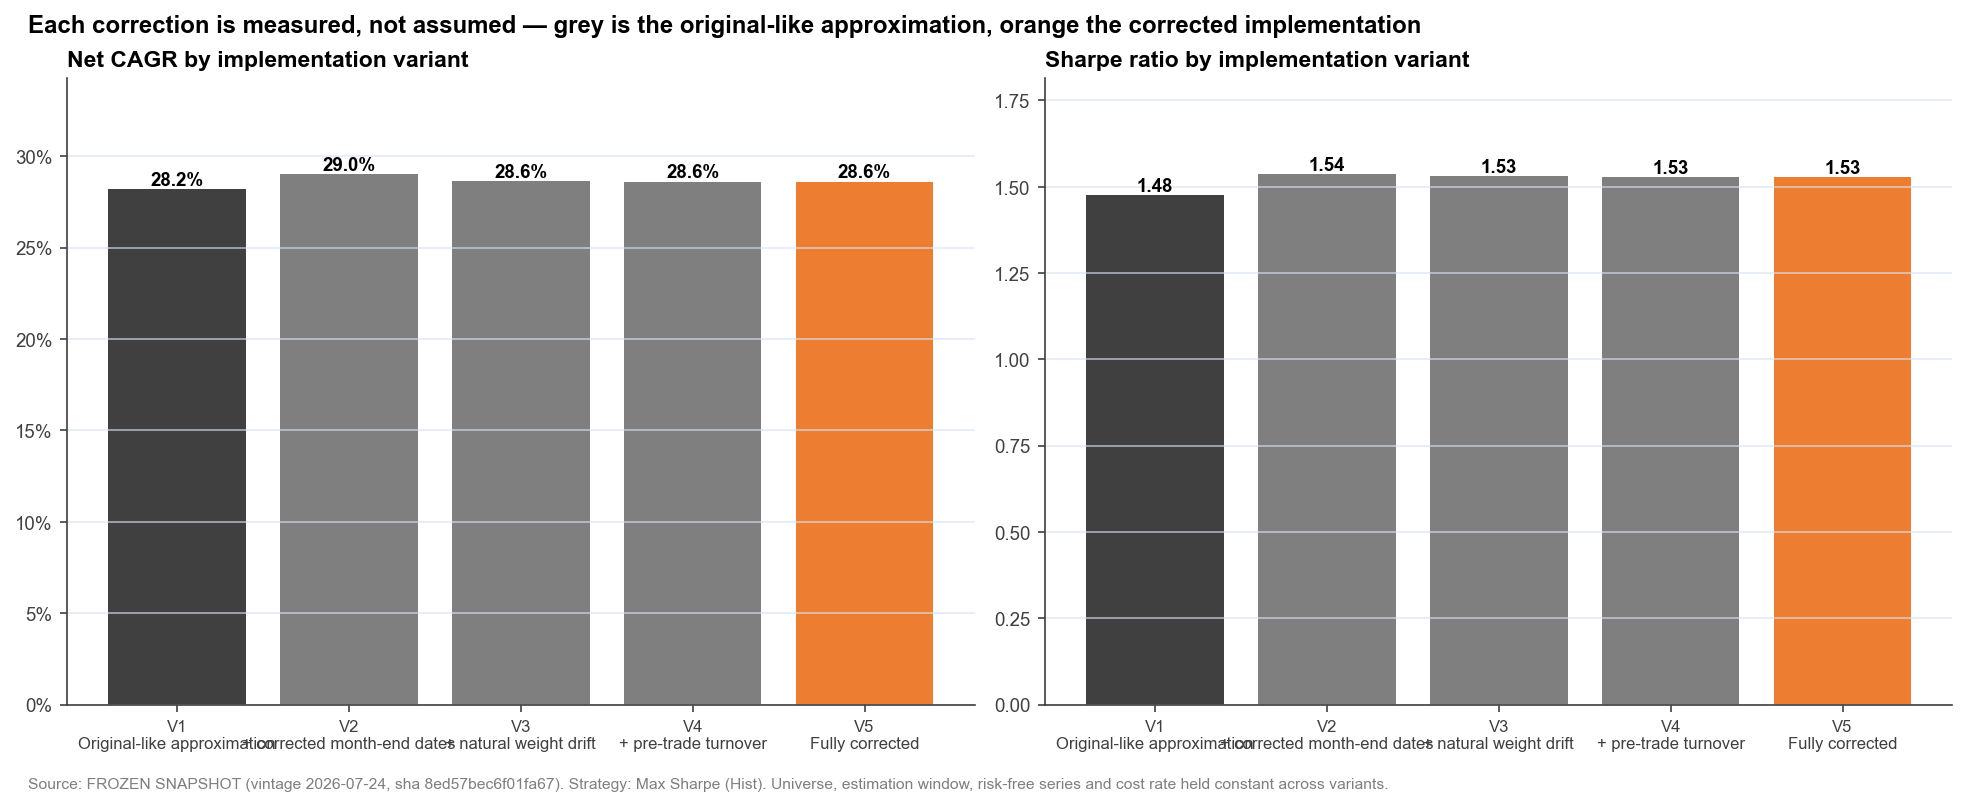

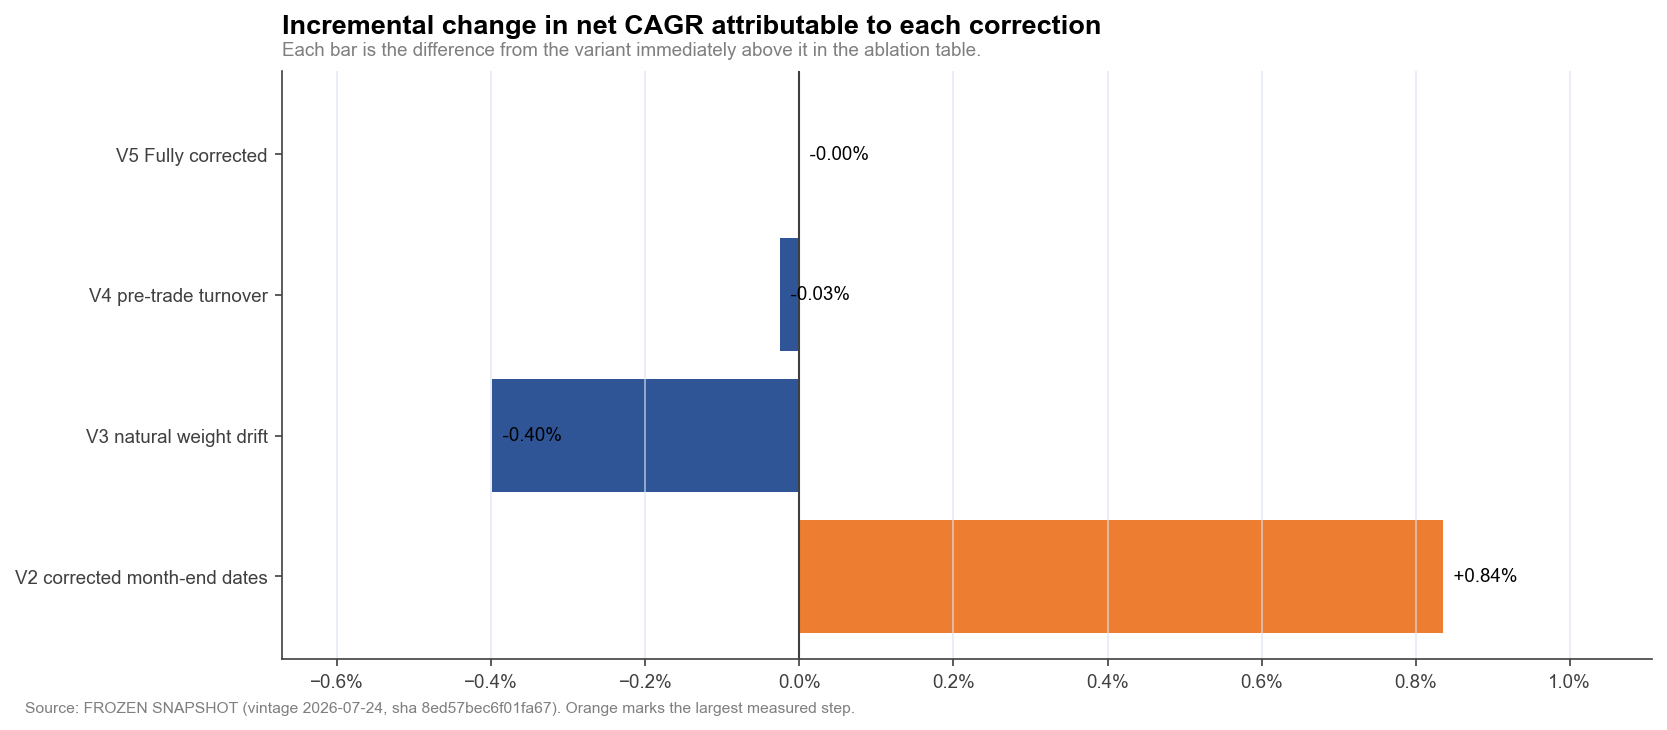

In [ ]:
# Ablation chart: incremental effect of each correction 
_lbl = [v.replace(" + ", "\n+ ").replace("V1 ", "V1\n").replace("V5 ", "V5\n") for v in ablation.index]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, fmt, title in [
        (axes[0], "CAGR", "{:.1%}", "Net CAGR by implementation variant"),
        (axes[1], "Sharpe", "{:.2f}", "Sharpe ratio by implementation variant")]:
    vals = ablation[col].to_numpy()
    cols = [MEDIUM_GRAY] * len(vals)
    cols[0], cols[-1] = DARK_GRAY, ORANGE
    ax.bar(range(len(vals)), vals, color=cols)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(_lbl, fontsize=8)
    for i, v in enumerate(vals):
        ax.text(i, v, fmt.format(v), ha="center",
                va="bottom" if v >= 0 else "top", fontsize=9, fontweight="bold")
    ax.set_title(title, loc="left", fontsize=11)
    ax.margins(y=0.18)
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
fig.suptitle("Each correction is measured, not assumed — grey is the original-like approximation, orange the corrected implementation",
             x=0.01, ha="left", fontsize=11.5, fontweight="bold")
fig.text(0.01, -0.04, f"Source: {DATA_SOURCE}. Strategy: {ABLATION_STRATEGY}. Universe, estimation window, "
                      "risk-free series and cost rate held constant across variants.",
         fontsize=7.5, color=MEDIUM_GRAY)
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.6))
_d = ablation["Δ CAGR"].dropna()
_c = [ORANGE if i == LARGEST_ABLATION_STEP else DARK_BLUE for i in _d.index]
ax.barh(range(len(_d)), _d.to_numpy(), color=_c)
ax.set_yticks(range(len(_d)))
ax.set_yticklabels([i.replace("+ ", "") for i in _d.index], fontsize=9)
ax.axvline(0, color=DARK_GRAY, lw=1)
for i, v in enumerate(_d.to_numpy()):
    ax.text(v, i, f"  {v:+.2%}", va="center", fontsize=9)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
ax.grid(axis="x"); ax.grid(axis="y", visible=False); ax.margins(x=0.22)
titled(ax, "Incremental change in net CAGR attributable to each correction",
       "Each bar is the difference from the variant immediately above it in the ablation table.",
       f"Source: {DATA_SOURCE}. Orange marks the largest measured step.")
plt.show()

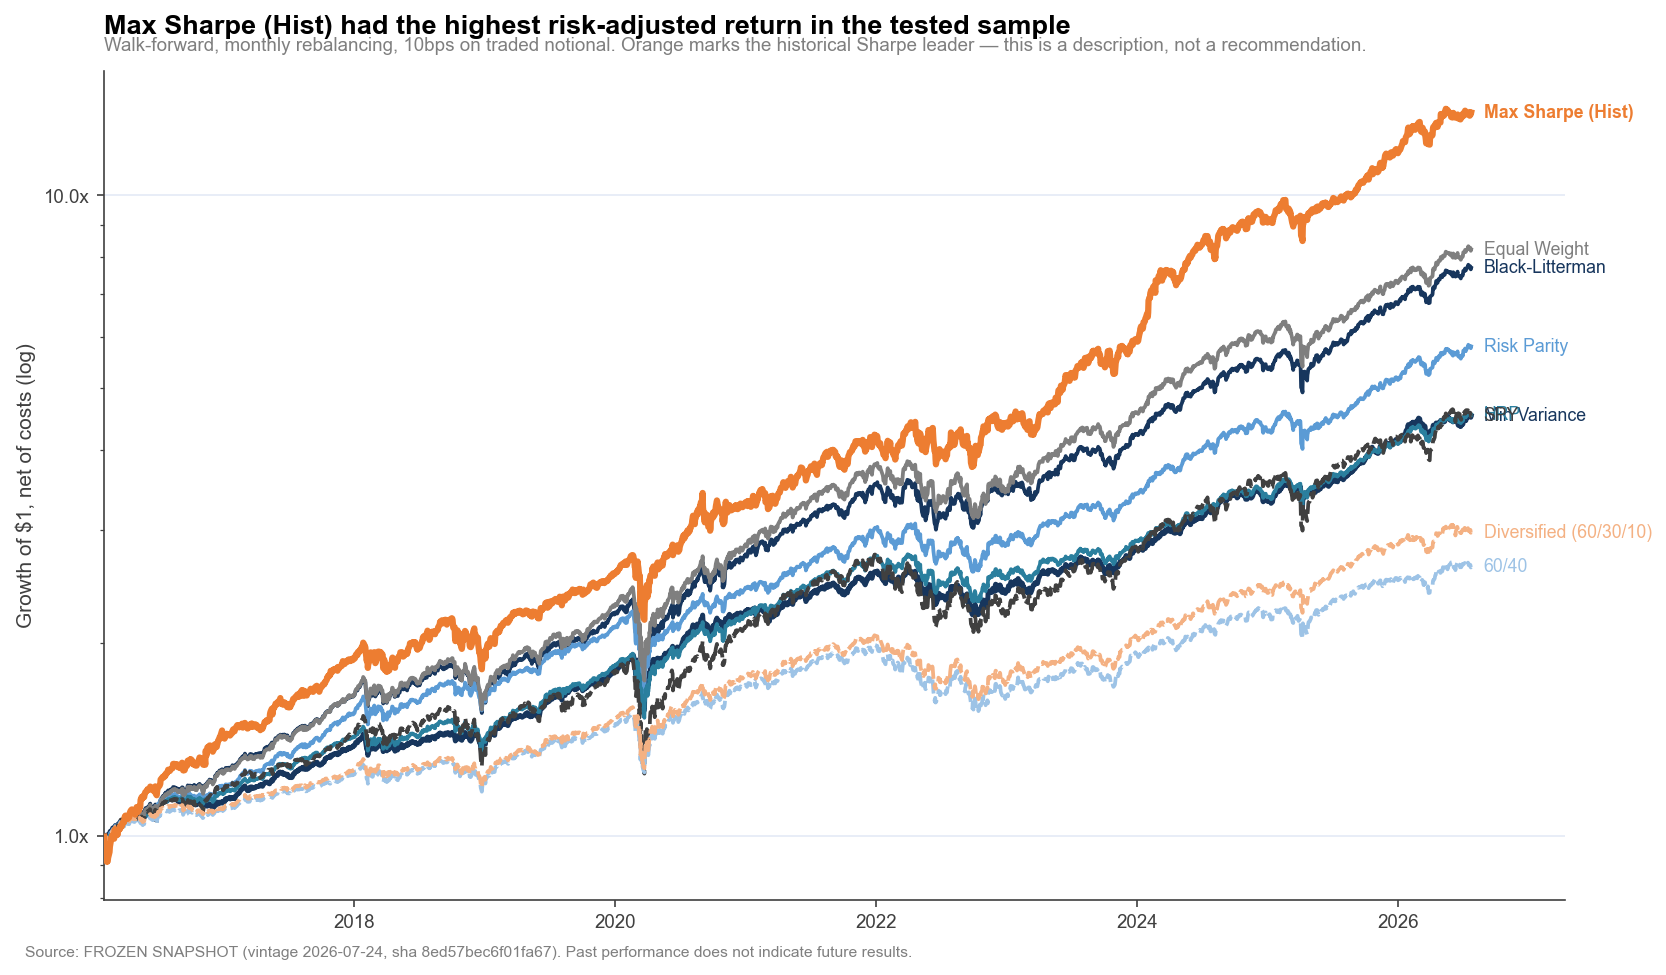

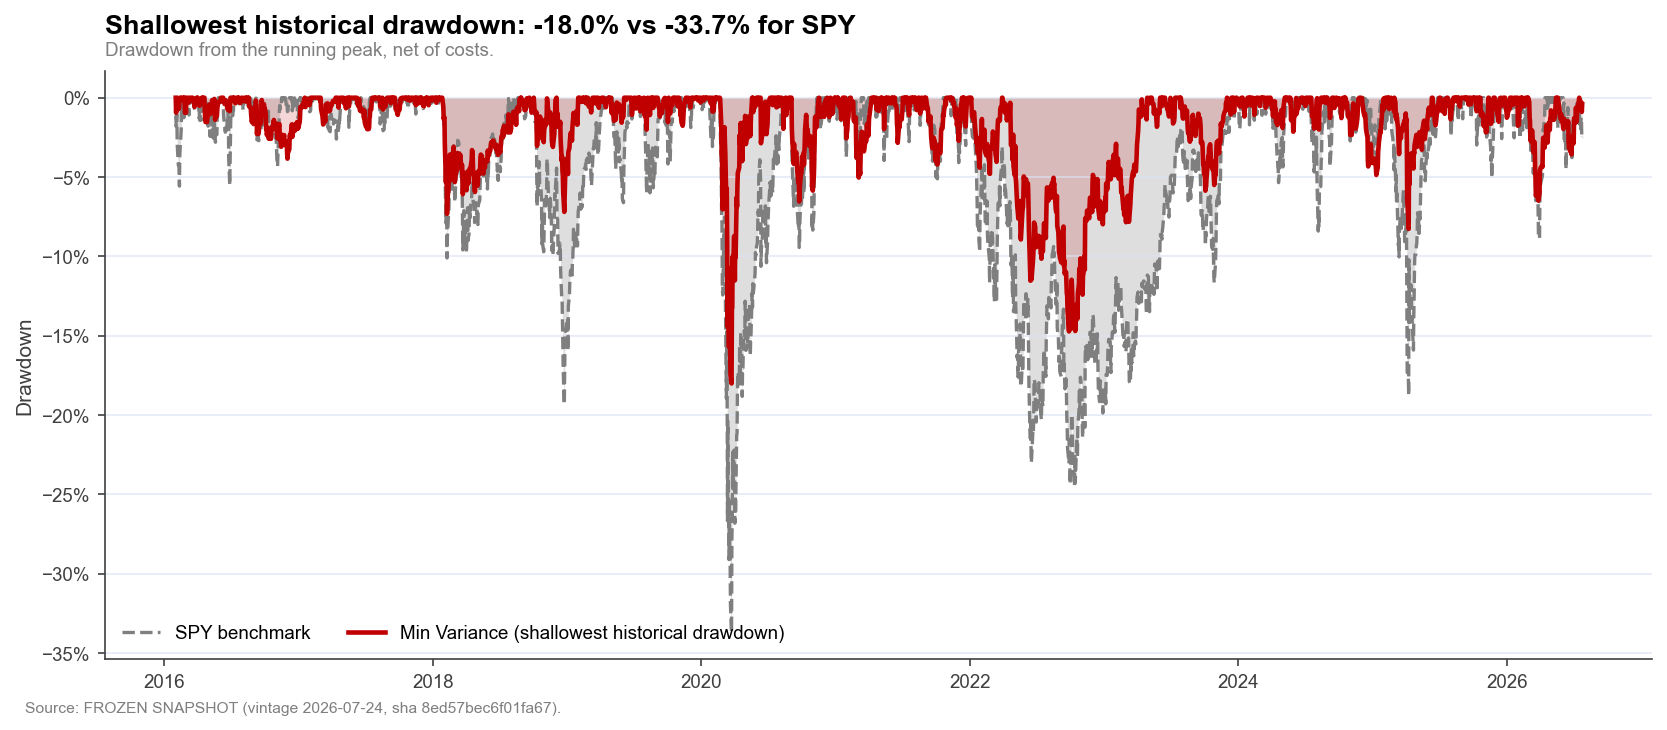

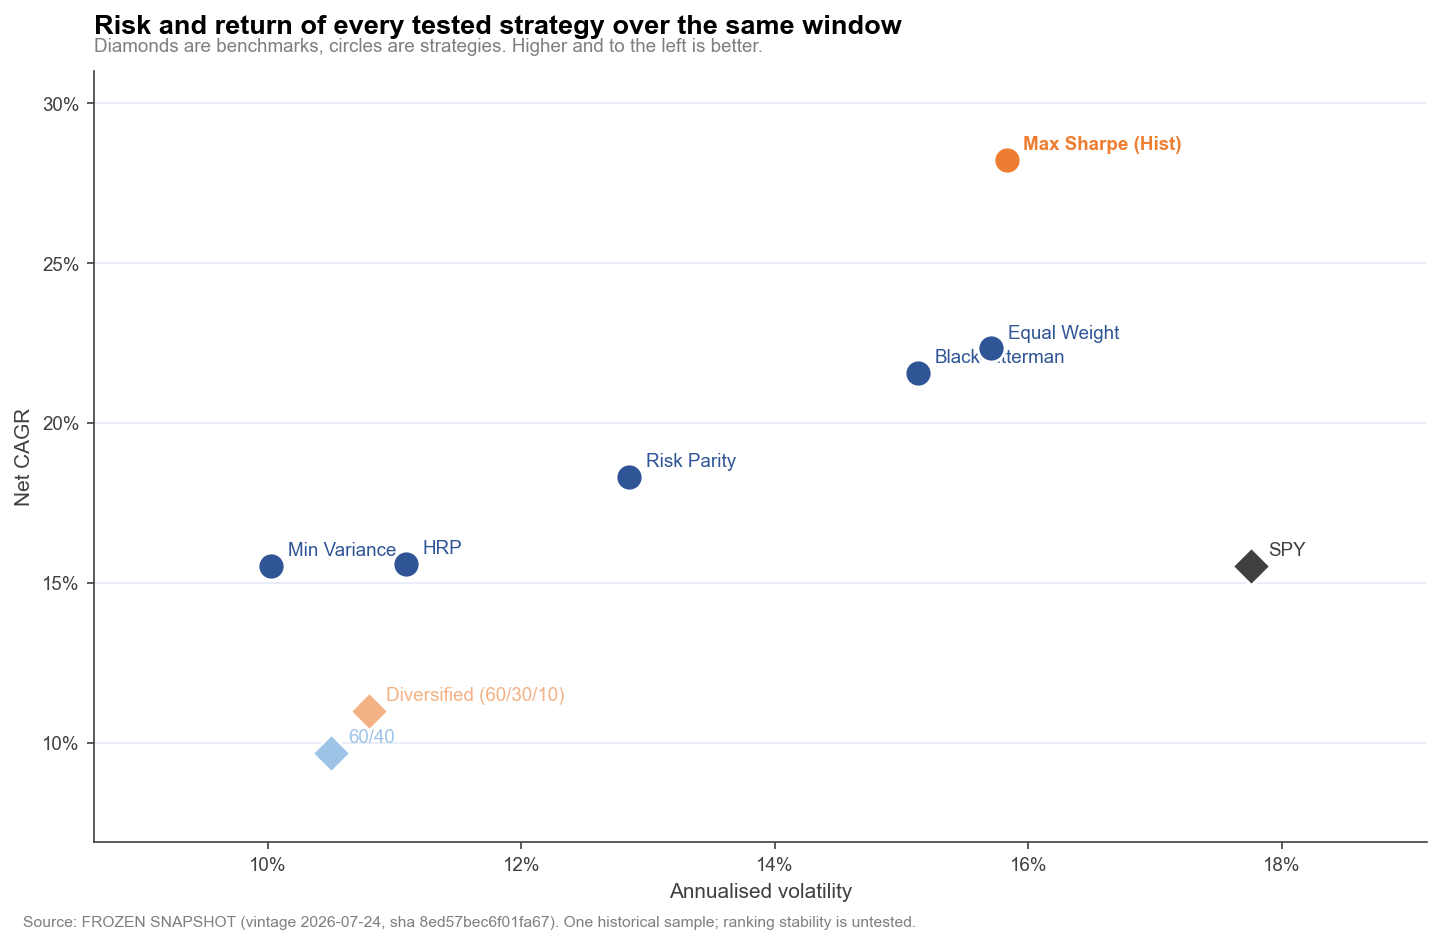

In [ ]:
# Cumulative growth (orange = historical Sharpe leader, NOT a recommendation) 
wealth = cumulative_wealth(strat_ret.fillna(0.0))
ROBUST_ALT = next((s for s in perf.index if s not in BENCHMARKS and s != HISTORICAL_SHARPE_LEADER), None)

fig, ax = plt.subplots(figsize=(11, 6.2))
for s in wealth.columns:
    col, lw, ls = style_for(s, HISTORICAL_SHARPE_LEADER)
    if s == ROBUST_ALT:
        col, lw, ls = NAVY, 2.4, "-"
    ax.plot(wealth.index, wealth[s], color=col, lw=lw, ls=ls,
            zorder=4 if s == HISTORICAL_SHARPE_LEADER else 2)
    ax.annotate(s, (wealth.index[-1], wealth[s].iloc[-1]), xytext=(6, 0),
                textcoords="offset points", fontsize=8.5, color=col, va="center",
                fontweight="bold" if s == HISTORICAL_SHARPE_LEADER else "normal")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.1f}x"))
ax.set_ylabel("Growth of $1, net of costs (log)")
ax.set_xlim(wealth.index.min(), wealth.index.max() + pd.Timedelta(days=int(len(wealth) * 0.10)))
titled(ax, f"{HISTORICAL_SHARPE_LEADER} had the highest risk-adjusted return in the tested sample",
       f"Walk-forward, monthly rebalancing, {CFG['TRANSACTION_COST_BPS']}bps on traded notional. "
       "Orange marks the historical Sharpe leader — this is a description, not a recommendation.",
       f"Source: {DATA_SOURCE}. Past performance does not indicate future results.")
plt.show()

# Drawdowns
fig, ax = plt.subplots(figsize=(11, 4.6))
dd_sel = drawdown_series(strat_ret[LOWEST_DRAWDOWN_STRATEGY].dropna())
dd_spy = drawdown_series(strat_ret["SPY"].dropna())
ax.fill_between(dd_spy.index, dd_spy.values, 0, color=MEDIUM_GRAY, alpha=0.25, lw=0)
ax.plot(dd_spy.index, dd_spy.values, color=MEDIUM_GRAY, lw=1.6, ls="--", label="SPY benchmark")
ax.fill_between(dd_sel.index, dd_sel.values, 0, color=RED, alpha=0.16, lw=0)
ax.plot(dd_sel.index, dd_sel.values, color=RED, lw=2.2,
        label=f"{LOWEST_DRAWDOWN_STRATEGY} (shallowest historical drawdown)")
pct_axis(ax); ax.set_ylabel("Drawdown"); ax.legend(loc="lower left", ncol=2)
titled(ax, f"Shallowest historical drawdown: {max_drawdown(strat_ret[LOWEST_DRAWDOWN_STRATEGY]):.1%} "
           f"vs {max_drawdown(strat_ret['SPY']):.1%} for SPY",
       "Drawdown from the running peak, net of costs.", f"Source: {DATA_SOURCE}.")
plt.show()

# Risk-return scatter 
fig, ax = plt.subplots(figsize=(9.5, 6))
for s in perf.index:
    col = ORANGE if s == HISTORICAL_SHARPE_LEADER else (color_for(s) if s in BENCHMARKS else DARK_BLUE)
    ax.scatter(perf.loc[s, "Volatility"], perf.loc[s, "CAGR"], s=170, color=col,
               edgecolors="white", linewidth=1.4, zorder=4, marker="D" if s in BENCHMARKS else "o")
    ax.annotate(s, (perf.loc[s, "Volatility"], perf.loc[s, "CAGR"]), xytext=(8, 5),
                textcoords="offset points", fontsize=9, color=col,
                fontweight="bold" if s == HISTORICAL_SHARPE_LEADER else "normal")
ax.set_xlabel("Annualised volatility"); ax.set_ylabel("Net CAGR")
pct_axis(ax); ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.margins(x=0.18, y=0.15)
titled(ax, "Risk and return of every tested strategy over the same window",
       "Diamonds are benchmarks, circles are strategies. Higher and to the left is better.",
       f"Source: {DATA_SOURCE}. One historical sample; ranking stability is untested.")
plt.show()

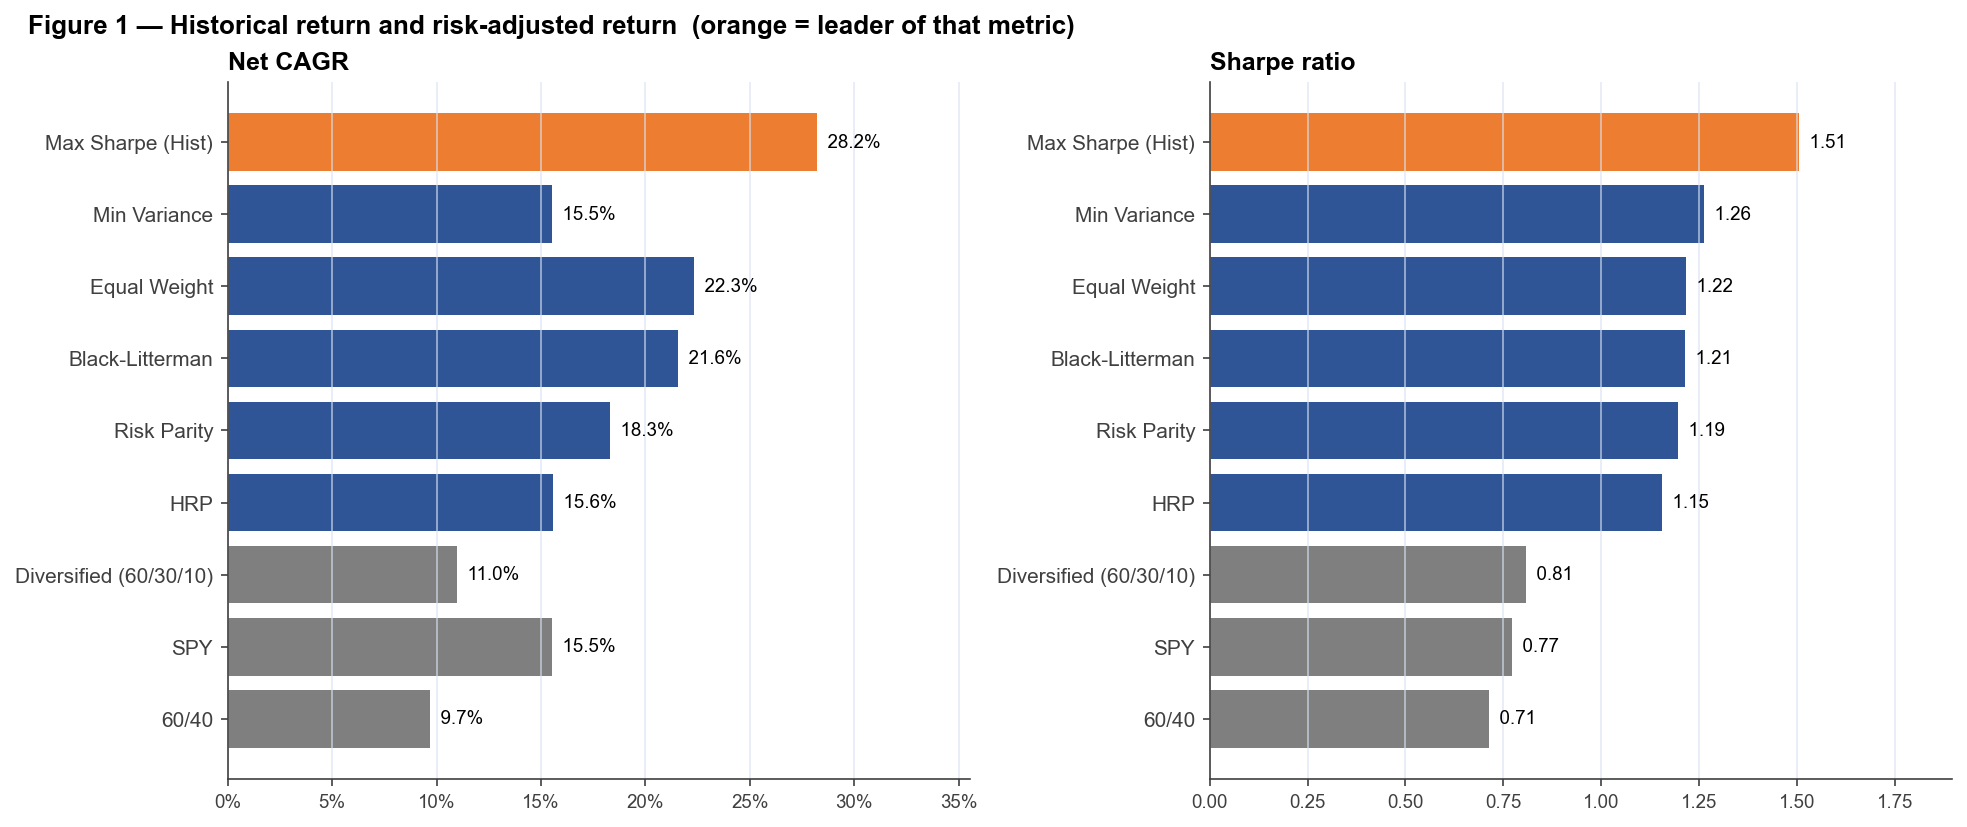

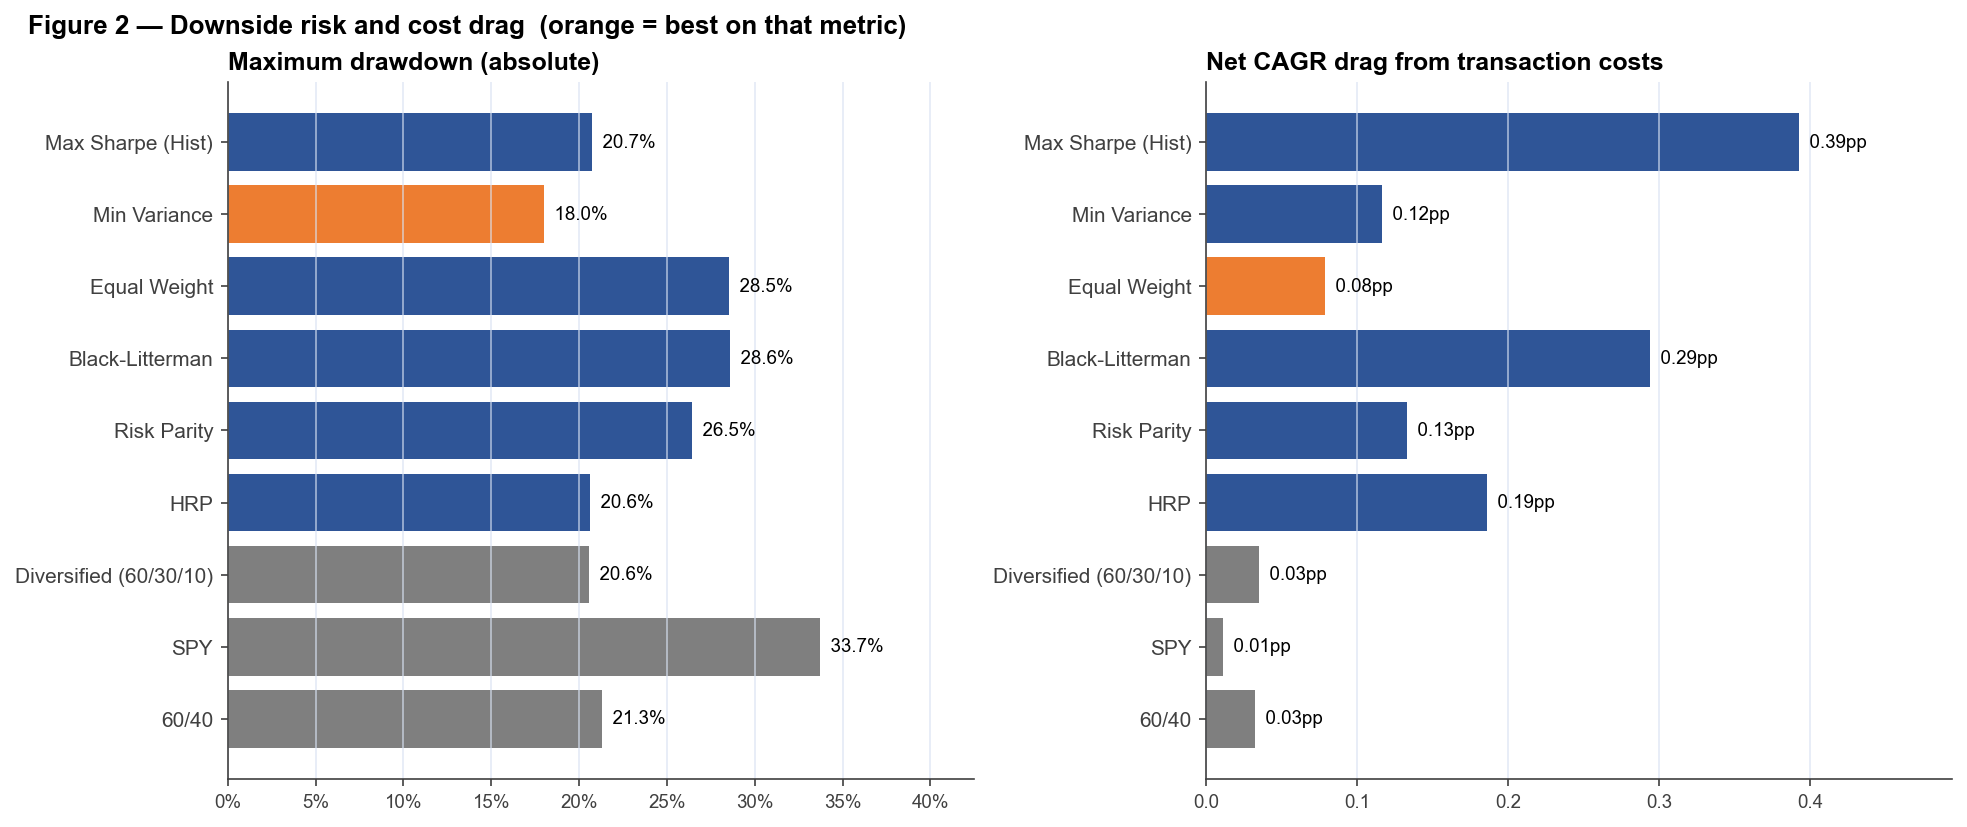

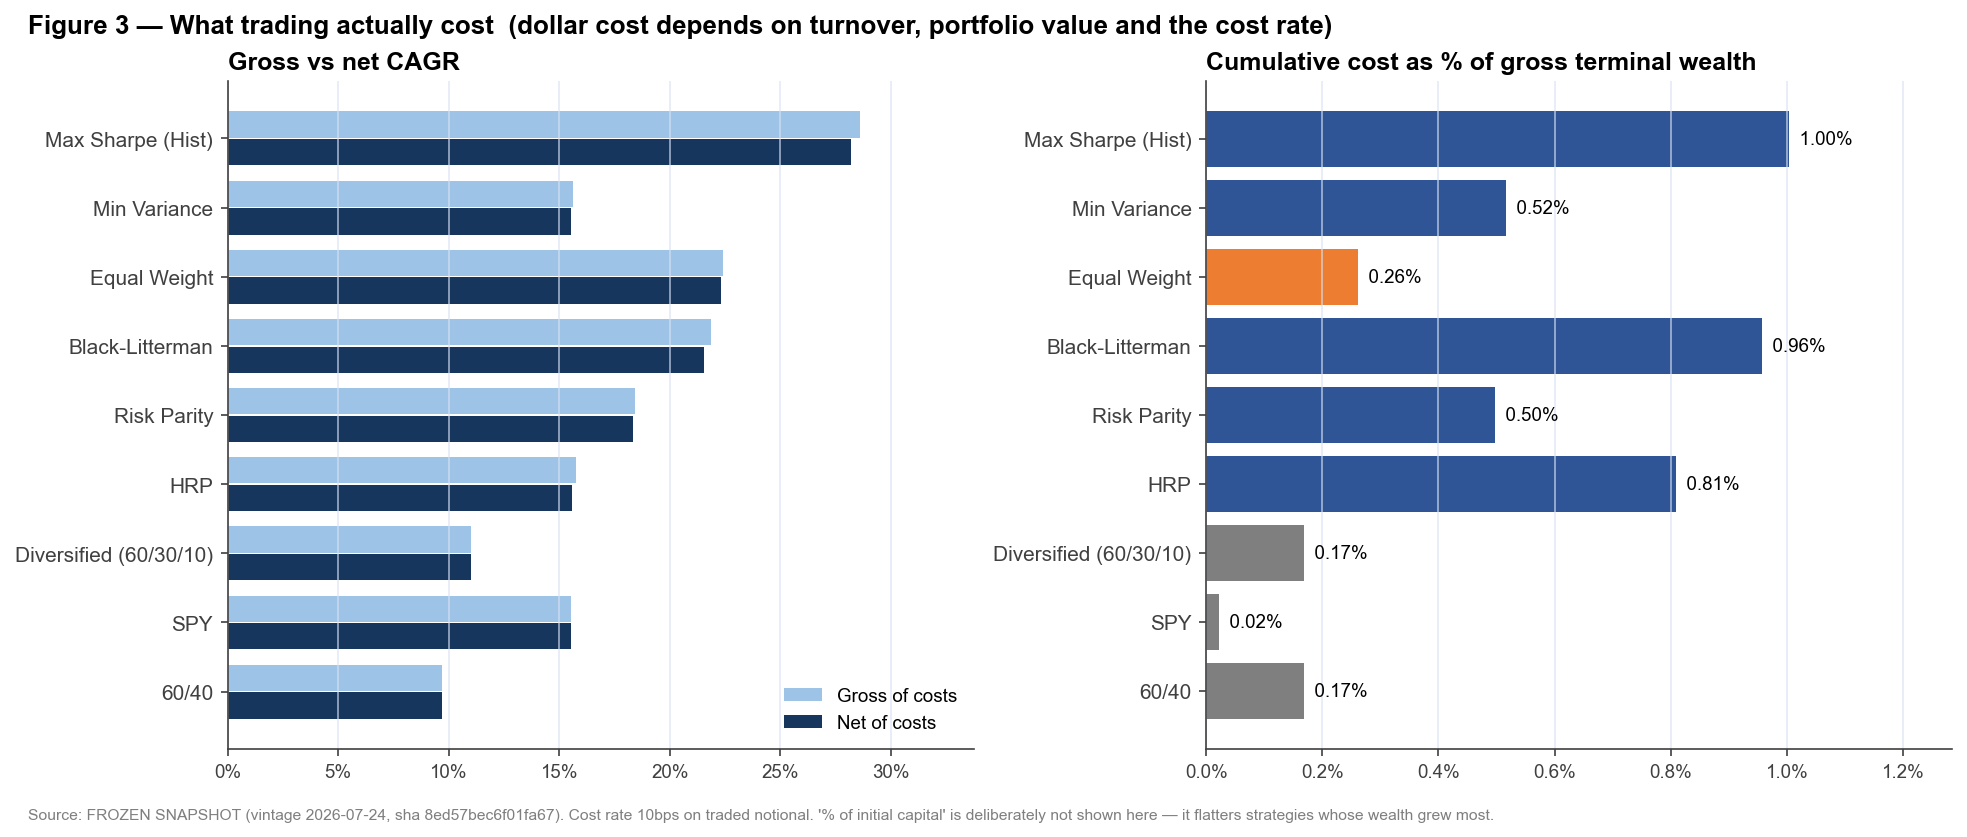

In [ ]:
# Split strategy comparison into two readable figures 
_order = perf.sort_values("Sharpe").index

def _bar(ax, series, fmt, title, highlight, invert_good=False):
    vals = series.reindex(_order)
    cols = [ORANGE if s == highlight else (MEDIUM_GRAY if s in BENCHMARKS else DARK_BLUE)
            for s in _order]
    ax.barh(range(len(vals)), vals.to_numpy(), color=cols)
    ax.set_yticks(range(len(vals))); ax.set_yticklabels(_order, fontsize=10)
    for i, v in enumerate(vals.to_numpy()):
        ax.text(v, i, "  " + fmt.format(v), va="center", fontsize=9)
    ax.set_title(title, loc="left", fontsize=12)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False); ax.margins(x=0.26)

# Figure 1 — return and risk-adjusted return
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
_bar(axes[0], perf["CAGR"], "{:.1%}", "Net CAGR", HISTORICAL_RETURN_LEADER)
_bar(axes[1], perf["Sharpe"], "{:.2f}", "Sharpe ratio", HISTORICAL_SHARPE_LEADER)
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
fig.suptitle("Figure 1 — Historical return and risk-adjusted return  (orange = leader of that metric)",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold")
plt.show()

# Figure 2 — downside and trading cost
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
_bar(axes[0], perf["Max Drawdown"].abs(), "{:.1%}", "Maximum drawdown (absolute)", LOWEST_DRAWDOWN_STRATEGY)
_bar(axes[1], perf["CAGR drag (pp)"], "{:.2f}pp", "Net CAGR drag from transaction costs", LOWEST_COST_DRAG)
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
fig.suptitle("Figure 2 — Downside risk and cost drag  (orange = best on that metric)",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold")
plt.show()

# Gross vs net: the decision-useful cost view
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
y = np.arange(len(_order))
axes[0].barh(y + 0.20, perf["Gross CAGR"].reindex(_order).to_numpy(), height=0.38,
             color=LIGHT_BLUE, label="Gross of costs")
axes[0].barh(y - 0.20, perf["Net CAGR"].reindex(_order).to_numpy(), height=0.38,
             color=NAVY, label="Net of costs")
axes[0].set_yticks(y); axes[0].set_yticklabels(_order, fontsize=10)
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
axes[0].legend(loc="lower right"); axes[0].grid(axis="x"); axes[0].grid(axis="y", visible=False)
axes[0].set_title("Gross vs net CAGR", loc="left", fontsize=12); axes[0].margins(x=0.18)

_ct = perf["Cost % of Gross Terminal"].reindex(_order)
_cols = [ORANGE if s == LOWEST_COST_DRAG else (MEDIUM_GRAY if s in BENCHMARKS else DARK_BLUE) for s in _order]
axes[1].barh(y, _ct.to_numpy(), color=_cols)
axes[1].set_yticks(y); axes[1].set_yticklabels(_order, fontsize=10)
for i, v in enumerate(_ct.to_numpy()):
    axes[1].text(v, i, f"  {v:.2%}", va="center", fontsize=9)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
axes[1].grid(axis="x"); axes[1].grid(axis="y", visible=False); axes[1].margins(x=0.28)
axes[1].set_title("Cumulative cost as % of gross terminal wealth", loc="left", fontsize=12)
fig.suptitle("Figure 3 — What trading actually cost  (dollar cost depends on turnover, portfolio value and the cost rate)",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold")
fig.text(0.01, -0.04, f"Source: {DATA_SOURCE}. Cost rate {CFG['TRANSACTION_COST_BPS']}bps on traded notional. "
                      "'% of initial capital' is deliberately not shown here — it flatters strategies whose wealth grew most.",
         fontsize=7.5, color=MEDIUM_GRAY)
plt.show()

## 2.5 Strategy Scorecard — Beyond a Single Sharpe Ranking 

Ranking by historical Sharpe alone picks whichever strategy happened to fit this
sample best. What does a strategy look like across several dimensions that matter to an investor?

Nine reported diagnostics, eight non-redundant dimensions used in the average rank, each computed over the identical out-of-sample window:
risk-adjusted return, downside, trading intensity, cost drag, concentration, effective number of
holdings, weight stability through time, consistency across three equal sub-periods, and behaviour
during the benchmark's deepest drawdown.

A "best balanced trade-off" row is included as a transparent
equal-weighted rank average: it is a summary of the table, not a recommendation. The word
recommended is reserved for the Phase 3 policy engine, where an allocation is matched to a stated
risk profile, horizon and exposure constraints.

In [ ]:
# Multi-dimensional strategy scorecard 
def weight_stability(schedule):
    """Average one-way turnover of the TARGET weights themselves (drift-independent)."""
    ds = sorted(schedule)
    if len(ds) < 2:
        return np.nan
    diffs = [0.5 * float((schedule[b] - schedule[a]).abs().sum()) for a, b in zip(ds[:-1], ds[1:])]
    return float(np.mean(diffs))

def avg_concentration(schedule):
    hhi = [float((w.to_numpy() ** 2).sum()) for w in schedule.values()]
    return float(np.mean(hhi))

# Benchmark's deepest drawdown window = the "crisis" period, derived from the data
_spy_w = cumulative_wealth(strat_ret["SPY"])
_dd = _spy_w / _spy_w.cummax() - 1.0
_trough = _dd.idxmin()
_peak = _spy_w.loc[:_trough].idxmax()
CRISIS_WINDOW = (_peak, _trough)

_thirds = np.array_split(strat_ret.index, 3)

rows = []
for s in strat_ret.columns:
    r = strat_ret[s]
    sch = schedules.get(s)
    sub = [sharpe(r.loc[t]) for t in _thirds]
    rows.append({
        "Strategy": s,
        "Sharpe": perf.loc[s, "Sharpe"],
        "Max Drawdown": perf.loc[s, "Max Drawdown"],
        "Avg Annual Turnover": perf.loc[s, "Avg Annual Turnover (1-way)"],
        "CAGR drag (pp)": perf.loc[s, "CAGR drag (pp)"],
        "Avg Concentration (HHI)": avg_concentration(sch) if sch else np.nan,
        "Effective Holdings": (1.0 / avg_concentration(sch)) if sch else np.nan,
        "Weight Stability (lower=steadier)": weight_stability(sch) if sch else 0.0,
        "Worst Sub-period Sharpe": float(np.nanmin(sub)),
        "Sub-period Sharpe Range": float(np.nanmax(sub) - np.nanmin(sub)),
        "Crisis-window Return": float((1 + r.loc[_peak:_trough]).prod() - 1),
    })
scorecard = pd.DataFrame(rows).set_index("Strategy")

_act = scorecard.loc[ACTIVE]
_rank = pd.DataFrame({
    "Sharpe": _act["Sharpe"].rank(ascending=False),
    "Drawdown": _act["Max Drawdown"].rank(ascending=False),
    "Turnover": _act["Avg Annual Turnover"].rank(ascending=True),
    "Cost drag": _act["CAGR drag (pp)"].rank(ascending=True),
    "Diversification": _act["Effective Holdings"].rank(ascending=False),
    "Stability": _act["Weight Stability (lower=steadier)"].rank(ascending=True),
    "Consistency": _act["Worst Sub-period Sharpe"].rank(ascending=False),
    "Crisis": _act["Crisis-window Return"].rank(ascending=False),
})
scorecard.loc[ACTIVE, "Avg Rank (lower=better)"] = _rank.mean(axis=1)

MOST_STABLE = _act["Weight Stability (lower=steadier)"].idxmin()
BEST_BALANCED = scorecard.loc[ACTIVE, "Avg Rank (lower=better)"].idxmin()
MOST_DIVERSIFIED = _act["Effective Holdings"].idxmax()
BEST_CRISIS = _act["Crisis-window Return"].idxmax()

print(f"Crisis window used = SPY's deepest drawdown in the tested sample: "
      f"{_peak.date()} to {_trough.date()} (SPY {float(_dd.min()):.1%})")
display(scorecard.style.format({
    "Sharpe": "{:.2f}", "Max Drawdown": "{:.2%}", "Avg Annual Turnover": "{:.2f}",
    "CAGR drag (pp)": "{:.2f}", "Avg Concentration (HHI)": "{:.3f}", "Effective Holdings": "{:.1f}",
    "Weight Stability (lower=steadier)": "{:.3f}", "Worst Sub-period Sharpe": "{:.2f}",
    "Sub-period Sharpe Range": "{:.2f}", "Crisis-window Return": "{:.2%}",
    "Avg Rank (lower=better)": "{:.2f}"}, na_rep="—")
    .set_table_styles([{"selector": "th.col_heading",
                        "props": [("background-color", NAVY), ("color", "white"), ("font-size", "9.5pt")]}]))

print("\nDESCRIPTIVE LABELS — each names the leader on one dimension, in this sample only:")
for lab, val in [("Historical return leader", HISTORICAL_RETURN_LEADER),
                 ("Historical risk-adjusted leader", HISTORICAL_SHARPE_LEADER),
                 ("Shallowest historical drawdown", LOWEST_DRAWDOWN_STRATEGY),
                 ("Lowest-turnover active strategy", LOWEST_TURNOVER_ACTIVE),
                 ("Lowest cost drag", LOWEST_COST_DRAG),
                 ("Most stable allocation", MOST_STABLE),
                 ("Most diversified (effective holdings)", MOST_DIVERSIFIED),
                 ("Best crisis-window return", BEST_CRISIS),
                 ("Best balanced trade-off (equal-weighted rank average)", BEST_BALANCED)]:
    print(f"  {lab:<52s} {val}")
print("\nNone of the above is investment advice. Different weightings of these dimensions select")
print("different strategies, and all of them are fitted to one historical sample.")

Crisis window used = SPY's deepest drawdown in the tested sample: 2020-02-19 to 2020-03-23 (SPY -33.7%)


,Sharpe,Max Drawdown,Avg Annual Turnover,CAGR drag (pp),Avg Concentration (HHI),Effective Holdings,Weight Stability (lower=steadier),Worst Sub-period Sharpe,Sub-period Sharpe Range,Crisis-window Return,Avg Rank (lower=better)
Strategy,,,,,,,,,,,
Max Sharpe (Hist),1.51,-20.75%,1.53,0.39,0.103,9.7,0.115,1.01,0.98,-20.75%,4.00
Black-Litterman,1.21,-28.58%,1.21,0.29,0.048,20.6,0.088,0.83,0.89,-28.22%,4.50
Min Variance,1.26,-18.01%,0.50,0.12,0.103,9.7,0.025,0.84,1.12,-17.88%,2.12
Risk Parity,1.19,-26.46%,0.56,0.13,0.059,17.1,0.034,0.70,1.27,-26.25%,3.88
HRP,1.15,-20.61%,0.80,0.19,0.077,12.9,0.057,0.81,0.96,-20.42%,3.75
Equal Weight,1.22,-28.53%,0.32,0.08,0.042,24.0,0.000,0.81,0.92,-28.11%,2.75
SPY,0.77,-33.72%,0.05,0.01,—,—,0.000,0.49,0.64,-33.40%,—
60/40,0.71,-21.30%,0.15,0.03,—,—,0.000,0.41,0.85,-18.66%,—
Diversified (60/30/10),0.81,-20.55%,0.16,0.03,—,—,0.000,0.48,0.85,-19.48%,—



DESCRIPTIVE LABELS — each names the leader on one dimension, in this sample only:
  Historical return leader                             Max Sharpe (Hist)
  Historical risk-adjusted leader                      Max Sharpe (Hist)
  Shallowest historical drawdown                       Min Variance
  Lowest-turnover active strategy                      Min Variance
  Lowest cost drag                                     Equal Weight
  Most stable allocation                               Equal Weight
  Most diversified (effective holdings)                Equal Weight
  Best crisis-window return                            Min Variance
  Best balanced trade-off (equal-weighted rank average) Min Variance

None of the above is investment advice. Different weightings of these dimensions select
different strategies, and all of them are fitted to one historical sample.


# Phase 3 — Decision Intelligence

## 3.1 Investment Policy Engine

**Business question:** Given a client's risk tolerance, capital and horizon, what allocation follows,
and what range of outcomes does the model imply?

**Method:** Policies are expressed against the corrected taxonomy: a floor on genuine non-equity
exposure (fixed income + commodity) and a ceiling on equity, so a utility stock can no longer be
counted as ballast. Expected returns come from Black–Litterman rather than raw historical means,
because unshrunk means produce optimistic and unstable allocations.

**Limitation:** Policy weights are calibrated on the full sample - this is a forward-looking policy
recommendation, not an out-of-sample result. The honest performance evidence is the walk-forward
backtest in Phase 2.

---

> ## Forward projections are modelled scenarios, not forecasts
>
> The projections below resample historical returns. They assume the future is drawn from the same
> distribution as the sampled past. They are not predictions, do not carry a confidence guarantee,
> and exclude taxes, regime change, and any market behaviour absent from the sample. Percentiles are
> modelled outcomes within the simulated sample, never floors, ceilings or guarantees.

In [ ]:
# Policy definitions against the corrected taxonomy 
RISK_PROFILES = {
    "Conservative": dict(objective="min_variance", min_w=0.0, max_w=0.20,
                         min_non_equity=0.35, max_equity=0.65,
                         goal="lower historical volatility and shallower drawdowns"),
    "Balanced":     dict(objective="risk_parity", min_w=0.0, max_w=0.15,
                         min_non_equity=0.20, max_equity=0.80,
                         goal="growth with moderated drawdowns"),
    "Aggressive":   dict(objective="max_sharpe", min_w=0.0, max_w=0.25,
                         min_non_equity=0.05, max_equity=0.95,
                         goal="long-horizon growth, accepting deeper drawdowns"),
}

def policy_baseline(assets, cfg):
    """A simple allocation that satisfies the profile's group constraints by construction.
    Used as fallback level 2 so a failed solve cannot land on an infeasible equal weight."""
    ne = [t for t in NON_EQUITY_TICKERS if t in assets]
    eq = [t for t in EQUITY_TICKERS if t in assets]
    w = pd.Series(0.0, index=assets)
    ne_target = min(max(cfg["min_non_equity"], 0.0) + 0.02, 1.0) if ne else 0.0
    if ne:
        w[ne] = ne_target / len(ne)
    if eq:
        w[eq] = (1.0 - ne_target) / len(eq)
    w = w.clip(upper=cfg["max_w"])
    return w / w.sum()

def build_policy_portfolio(profile, expected_mu, cov):
    """Optimise under box AND asset-class group constraints, with a feasible fallback."""
    cfg = RISK_PROFILES[profile]
    assets = list(cov.index)
    ne_idx = [assets.index(t) for t in NON_EQUITY_TICKERS if t in assets]
    eq_idx = [assets.index(t) for t in EQUITY_TICKERS if t in assets]
    cons = [
        {"type": "ineq", "fun": lambda w, i=ne_idx, f=cfg["min_non_equity"]: w[i].sum() - f},
        {"type": "ineq", "fun": lambda w, i=eq_idx, c=cfg["max_equity"]: c - w[i].sum()},
    ]
    groups = {"non-equity": (ne_idx, cfg["min_non_equity"], 1.0),
              "equity": (eq_idx, 0.0, cfg["max_equity"])}
    m, C = expected_mu.to_numpy(), cov.to_numpy()
    objs = {"min_variance": lambda w: port_vol(w, C),
            "max_sharpe": lambda w: -port_sharpe(w, m, C, RF_CURRENT),
            "risk_parity": lambda w: float(np.sum((w * (C @ w) - (w @ C @ w) / len(assets)) ** 2))}
    w = optimize(objs[cfg["objective"]], assets, min_w=cfg["min_w"], max_w=cfg["max_w"],
                 extra_constraints=cons, groups=groups, label=f"Policy:{profile}",
                 context={"section": f"policy engine / {profile}"},
                 baseline_weights=policy_baseline(assets, cfg))
    validate_weights(w, cfg["min_w"], cfg["max_w"], groups=groups, label=f"Policy:{profile} [final]")
    exp = exposure_report(w)
    return {"profile": profile, "cfg": cfg, "weights": w, "exposure": exp,
            "exp_return": port_return(w, expected_mu), "volatility": port_vol(w, cov),
            "sharpe": port_sharpe(w.to_numpy(), m, C, RF_CURRENT),
            "effective_holdings": effective_holdings(w)}

policy_portfolios = {p: build_policy_portfolio(p, bl_post, cov_full) for p in RISK_PROFILES}

exp_rows = []
for p, r in policy_portfolios.items():
    e = r["exposure"]
    exp_rows.append({"Profile": p, "Expected Return (BL)": r["exp_return"], "Volatility": r["volatility"],
                     "Effective Holdings": r["effective_holdings"],
                     "Equity": e["equity"], "Fixed Income": e["fixed_income"], "Commodity": e["commodity"],
                     "Defensive-role (any class)": e["defensive_role"]})
exposure_table = pd.DataFrame(exp_rows).set_index("Profile")
print(f"Policy engine risk-free rate: {RF_CURRENT:.3%} — the LATEST available observation "
      f"({RF_SERIES.index[-1].date()}), appropriate for a forward-looking recommendation.")
print("Exposure by TRUE asset class (NEE counted as equity, not as ballast):")
display(exposure_table.style.format({
    "Expected Return (BL)": "{:.2%}", "Volatility": "{:.2%}", "Effective Holdings": "{:.1f}",
    "Equity": "{:.1%}", "Fixed Income": "{:.1%}", "Commodity": "{:.1%}",
    "Defensive-role (any class)": "{:.1%}"}))

Policy engine risk-free rate: 3.960% — the LATEST available observation (2026-07-24), appropriate for a forward-looking recommendation.
Exposure by TRUE asset class (NEE counted as equity, not as ballast):


,Expected Return (BL),Volatility,Effective Holdings,Equity,Fixed Income,Commodity,Defensive-role (any class)
Profile,,,,,,,
Conservative,10.91%,9.33%,7.5,60.0%,20.0%,20.0%,67.1%
Balanced,14.84%,11.82%,15.2,71.3%,14.3%,14.5%,43.8%
Aggressive,18.93%,15.79%,23.1,91.7%,4.2%,4.2%,32.1%


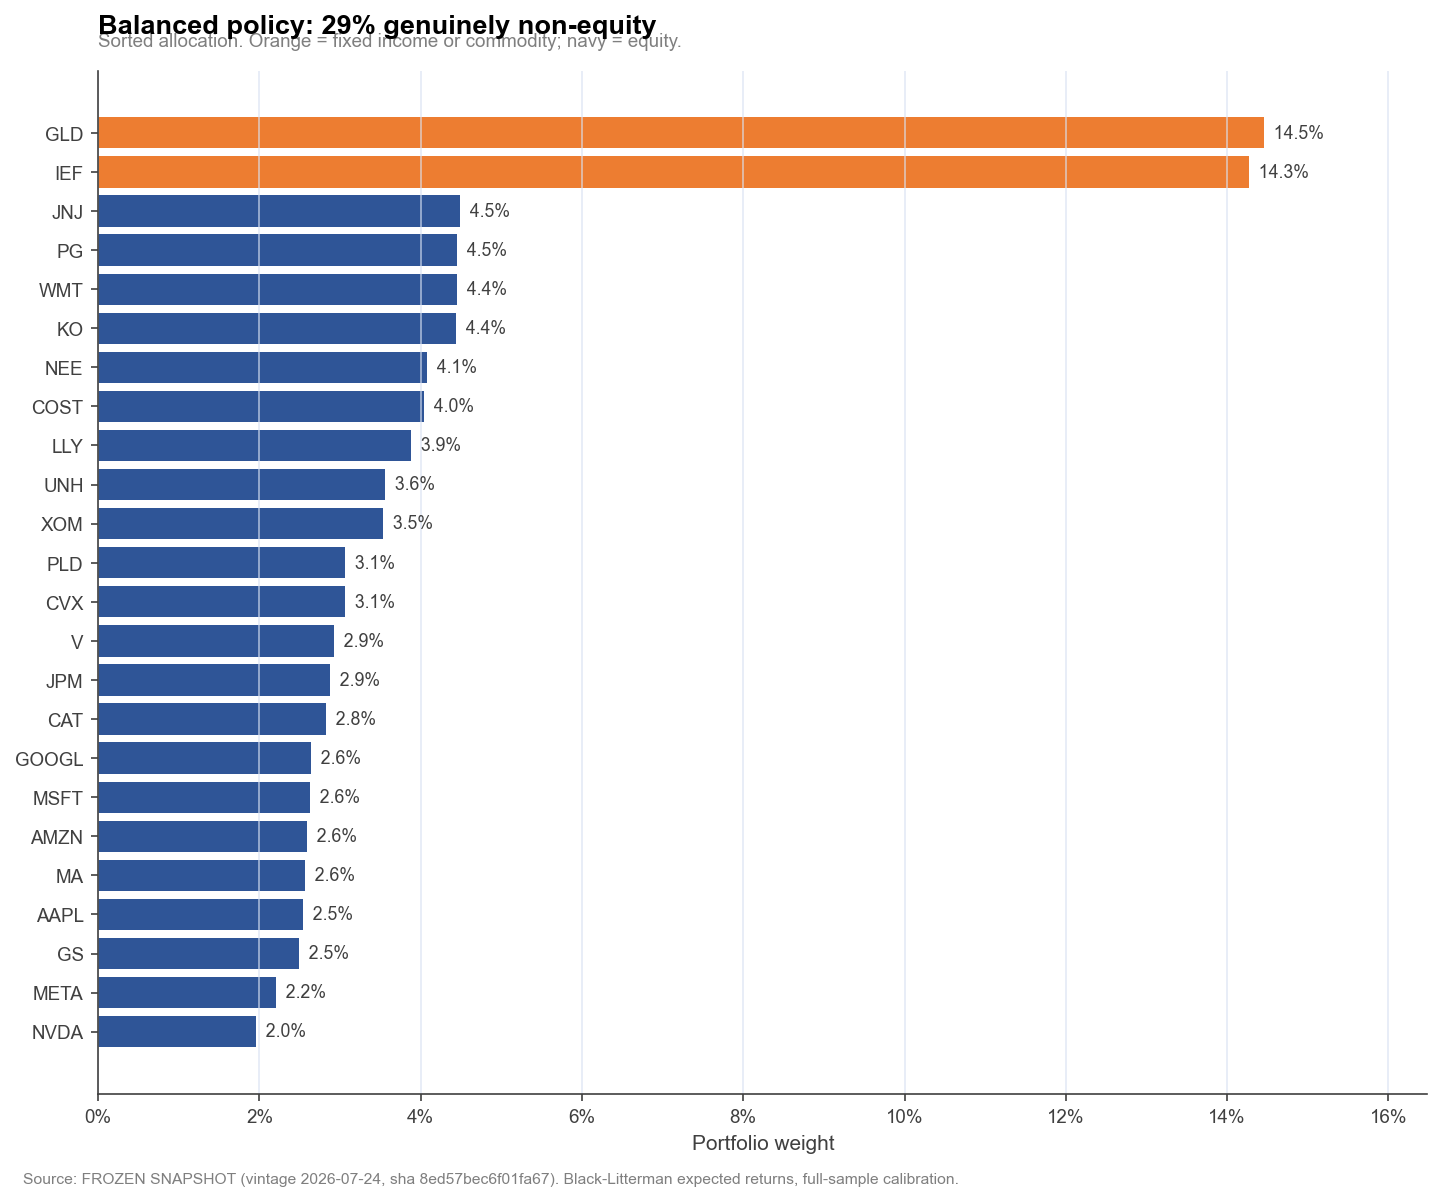

In [ ]:
# Allocation chart: sorted horizontal bars 
SHOW_PROFILE = "Balanced"
_w = policy_portfolios[SHOW_PROFILE]["weights"]
_w = _w[_w > 1e-4].sort_values()
_colors = [ORANGE if ASSET_CLASS[t] != "Equity" else DARK_BLUE for t in _w.index]

fig, ax = plt.subplots(figsize=(9.5, max(4.5, 0.32 * len(_w))))
ax.barh(_w.index, _w.values, color=_colors)
for i, (t, v) in enumerate(_w.items()):
    ax.text(v, i, f"  {v:.1%}", va="center", fontsize=8.5, color=DARK_GRAY)
ax.set_xlabel("Portfolio weight"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0)); ax.margins(x=0.14)
titled(ax, f"{SHOW_PROFILE} policy: {policy_portfolios[SHOW_PROFILE]['exposure']['non_equity']:.0%} genuinely non-equity",
       "Sorted allocation. Orange = fixed income or commodity; navy = equity.",
       f"Source: {DATA_SOURCE}. Black-Litterman expected returns, full-sample calibration.")
plt.show()

## 3.2 Forward Projections — Multivariate Resampling 

1. Resamples overlapping blocks of the multivariate asset-return matrix (all 24 assets together, same
   dates), so cross-sectional correlations, serial dependence and volatility clustering are preserved.
2. Reconstructs each simulated asset path.
3. Applies the fixed policy target allocation to every simulated path, allowing drift and periodic rebalancing
   (rebalance every 21 trading days back to the profile's target weights).
4. Charges transaction costs on traded notional at every simulated rebalance.
5. Computes portfolio returns from drifting holdings, exactly as the backtest engine does.

Block length defaults to 21 trading days, with sensitivity at 21 / 42 / 63 reported for every profile so
the reader can see whether conclusions hold across settings. Seeds are explicit integers per profile.

---

> ### These are modelled scenarios, not forecasts
> Every path is built by resampling this historical sample. Percentiles describe the simulated
> distribution only - a 5th-percentile modelled outcome is not a floor, and a high simulated
> probability is not a guarantee. Results exclude taxes, market impact, and any regime absent from the
> sampled history.
>
> ### Selection bias makes these projections optimistic
> The 24-asset universe was chosen in 2026 and contains ex-post winners (NVDA, META, LLY). Resampling
> that history propagates their realised success into every simulated future. The true forward
> distribution for a universe chosen without hindsight would almost certainly be worse.

In [ ]:
# Multivariate block bootstrap + full policy simulation 
def multivariate_block_indices(n_obs, n_days, n_paths, block_length, rng):
    """Overlapping moving-block indices shared across ALL assets (preserves cross-correlation)."""
    L = int(min(block_length, n_obs))
    n_blocks = int(np.ceil(n_days / L))
    starts = rng.integers(0, n_obs - L + 1, size=(n_paths, n_blocks))
    idx = (starts[:, :, None] + np.arange(L)[None, None, :]).reshape(n_paths, -1)[:, :n_days]
    return idx.astype(np.int32)

def simulate_policy_paths(profile, block_length=None, n_paths=None, horizon_years=None,
                          capital=None, cost_rate=None, seed_key=None):
    """Resample multivariate asset blocks, then RERUN the policy allocation on every path.

    Rebalancing, weight drift and transaction costs are simulated inside each path —
    they are not inherited from the sampled history.
    """
    block_length = block_length or CFG["BLOCK_LENGTH"]
    n_paths = n_paths or CFG["N_PROJECTION_PATHS"]
    horizon_years = horizon_years or CFG["PROJECTION_HORIZON_YEARS"]
    capital = capital or CFG["PROJECTION_CAPITAL"]
    cost_rate = TRANSACTION_COST_RATE if cost_rate is None else cost_rate
    seed_key = seed_key or f"projection_{profile}"

    w = policy_portfolios[profile]["weights"].reindex(daily.columns).fillna(0.0).to_numpy()
    R = daily.to_numpy()
    T, N = R.shape
    n_days = int(horizon_years * CFG["TRADING_DAYS"])
    step = CFG["PROJECTION_REBALANCE_DAYS"]
    rng = new_rng(seed_key)
    idx = multivariate_block_indices(T, n_days, n_paths, block_length, rng)

    value = np.full(n_paths, float(capital))
    peak = value.copy()
    mdd = np.zeros(n_paths)
    total_cost = np.zeros(n_paths)
    total_oneway = np.zeros(n_paths)
    holdings = None
    checkpoints = [value.copy()]

    for s0 in range(0, n_days, step):
        s1 = min(s0 + step, n_days)
        if holdings is None:
            pretrade = np.zeros((n_paths, N))
        else:
            value = holdings.sum(axis=1)
            pretrade = holdings / np.maximum(value, 1e-12)[:, None]
        traded = np.abs(w[None, :] - pretrade).sum(axis=1)          # traded notional
        cost = value * traded * cost_rate
        total_cost += cost
        total_oneway += 0.5 * traded
        value = value - cost
        holdings = value[:, None] * w[None, :]

        seg = R[idx[:, s0:s1]]                                       # (paths, k, assets)
        growth = np.cumprod(1.0 + seg, axis=1)
        vals = np.einsum("pkn,pn->pk", growth, holdings)
        run_peak = np.maximum.accumulate(
            np.concatenate([peak[:, None], vals], axis=1), axis=1)[:, 1:]
        mdd = np.minimum(mdd, (vals / run_peak - 1.0).min(axis=1))
        peak = run_peak[:, -1]
        holdings = growth[:, -1, :] * holdings
        checkpoints.append(holdings.sum(axis=1))

    final = holdings.sum(axis=1)
    years = n_days / CFG["TRADING_DAYS"]
    n_below, n_double = int((final < capital).sum()), int((final >= 2 * capital).sum())
    return {
        "final": final, "mdd": mdd, "checkpoints": np.column_stack(checkpoints),
        "metrics": {
            "Median": float(np.median(final)),
            "5th pct": float(np.percentile(final, 5)),
            "25th pct": float(np.percentile(final, 25)),
            "75th pct": float(np.percentile(final, 75)),
            "95th pct": float(np.percentile(final, 95)),
            "Median implied CAGR": float((np.median(final) / capital) ** (1 / horizon_years) - 1),
            "P(end below capital)": n_below / n_paths,
            "P(at least double)": n_double / n_paths,
            "Paths below capital": n_below,
            "Paths at least double": n_double,
            "Median simulated MaxDD": float(np.median(mdd)),
            "5th pct simulated MaxDD": float(np.percentile(mdd, 5)),
            "Median simulated cost ($)": float(np.median(total_cost)),
            "Avg annual 1-way turnover": float(total_oneway.mean() / years),
            "_n_below": n_below, "_n_double": n_double, "_n_paths": n_paths}}

def phrase_probability(count, n_paths):
    """Never print a rounded 100%/0% as if every path satisfied the condition.

    A probability of 0.9996 formats to '100.0%' under {:.1%}, which reads as certainty.
    Near-boundary values therefore report the raw path counts instead.
    """
    if count == n_paths:
        return f"100% within the simulated sample (all {n_paths:,} paths)"
    if count == 0:
        return f"0% within the simulated sample (none of {n_paths:,} paths)"
    p = count / n_paths
    if p > 0.9995:
        return f"{count:,} of {n_paths:,} paths (>99.9%, but NOT all)"
    if p < 0.0005:
        return f"{count:,} of {n_paths:,} paths (<0.1%, but not zero)"
    return f"{p:.1%} ({count:,} of {n_paths:,} paths)"

projections = {p: simulate_policy_paths(p) for p in RISK_PROFILES}
proj_table = pd.DataFrame({p: v["metrics"] for p, v in projections.items()}).T
proj_table = proj_table.drop(columns=[c for c in proj_table.columns if c.startswith("_")])

print(f"MODELLED SCENARIOS — ${CFG['PROJECTION_CAPITAL']:,.0f} over {CFG['PROJECTION_HORIZON_YEARS']} years")
print(f"Method: multivariate moving-block bootstrap ({CFG['BLOCK_LENGTH']}-day blocks), "
      f"{CFG['N_PROJECTION_PATHS']:,} paths, policy rebalanced every {CFG['PROJECTION_REBALANCE_DAYS']} "
      f"trading days with {CFG['TRANSACTION_COST_BPS']}bps costs charged inside each path.")
display(proj_table.style.format({
    "Median": money, "5th pct": money, "25th pct": money, "75th pct": money, "95th pct": money,
    "Median implied CAGR": "{:.2%}", "P(end below capital)": "{:.2%}", "P(at least double)": "{:.2%}",
    "Paths below capital": "{:,.0f}", "Paths at least double": "{:,.0f}",
    "Median simulated MaxDD": "{:.1%}", "5th pct simulated MaxDD": "{:.1%}",
    "Median simulated cost ($)": money, "Avg annual 1-way turnover": "{:.2f}"}))
for p, v in projections.items():
    m = v["metrics"]
    print(f"{p:13s}: median ${m['Median']:,.0f} | 5th-percentile modelled outcome ${m['5th pct']:,.0f} | "
          f"P(double) = {phrase_probability(m['_n_double'], m['_n_paths'])}")
print("\nPercentiles describe the simulated distribution only — not floors, ceilings or guarantees.")
print("Raw path counts are shown alongside every probability so a rounded 100% cannot be mistaken for certainty.")

MODELLED SCENARIOS — $100,000 over 10 years
Method: multivariate moving-block bootstrap (21-day blocks), 4,000 paths, policy rebalanced every 21 trading days with 10bps costs charged inside each path.


,Median,5th pct,25th pct,75th pct,95th pct,Median implied CAGR,P(end below capital),P(at least double),Paths below capital,Paths at least double,Median simulated MaxDD,5th pct simulated MaxDD,Median simulated cost ($),Avg annual 1-way turnover
Conservative,"$291,565","$183,143","$241,578","$353,888","$455,637",11.29%,0.03%,90.92%,1,"3,637",-14.5%,-23.0%,$756,0.23
Balanced,"$460,804","$269,261","$371,747","$571,222","$780,829",16.51%,0.00%,99.50%,0,"3,980",-18.7%,-27.5%,"$1,239",0.29
Aggressive,"$706,455","$337,254","$524,306","$936,134","$1,394,245",21.59%,0.00%,99.72%,0,"3,989",-24.4%,-36.1%,"$1,796",0.32


Conservative : median $291,565 | 5th-percentile modelled outcome $183,143 | P(double) = 90.9% (3,637 of 4,000 paths)
Balanced     : median $460,804 | 5th-percentile modelled outcome $269,261 | P(double) = 99.5% (3,980 of 4,000 paths)
Aggressive   : median $706,455 | 5th-percentile modelled outcome $337,254 | P(double) = 99.7% (3,989 of 4,000 paths)

Percentiles describe the simulated distribution only — not floors, ceilings or guarantees.
Raw path counts are shown alongside every probability so a rounded 100% cannot be mistaken for certainty.


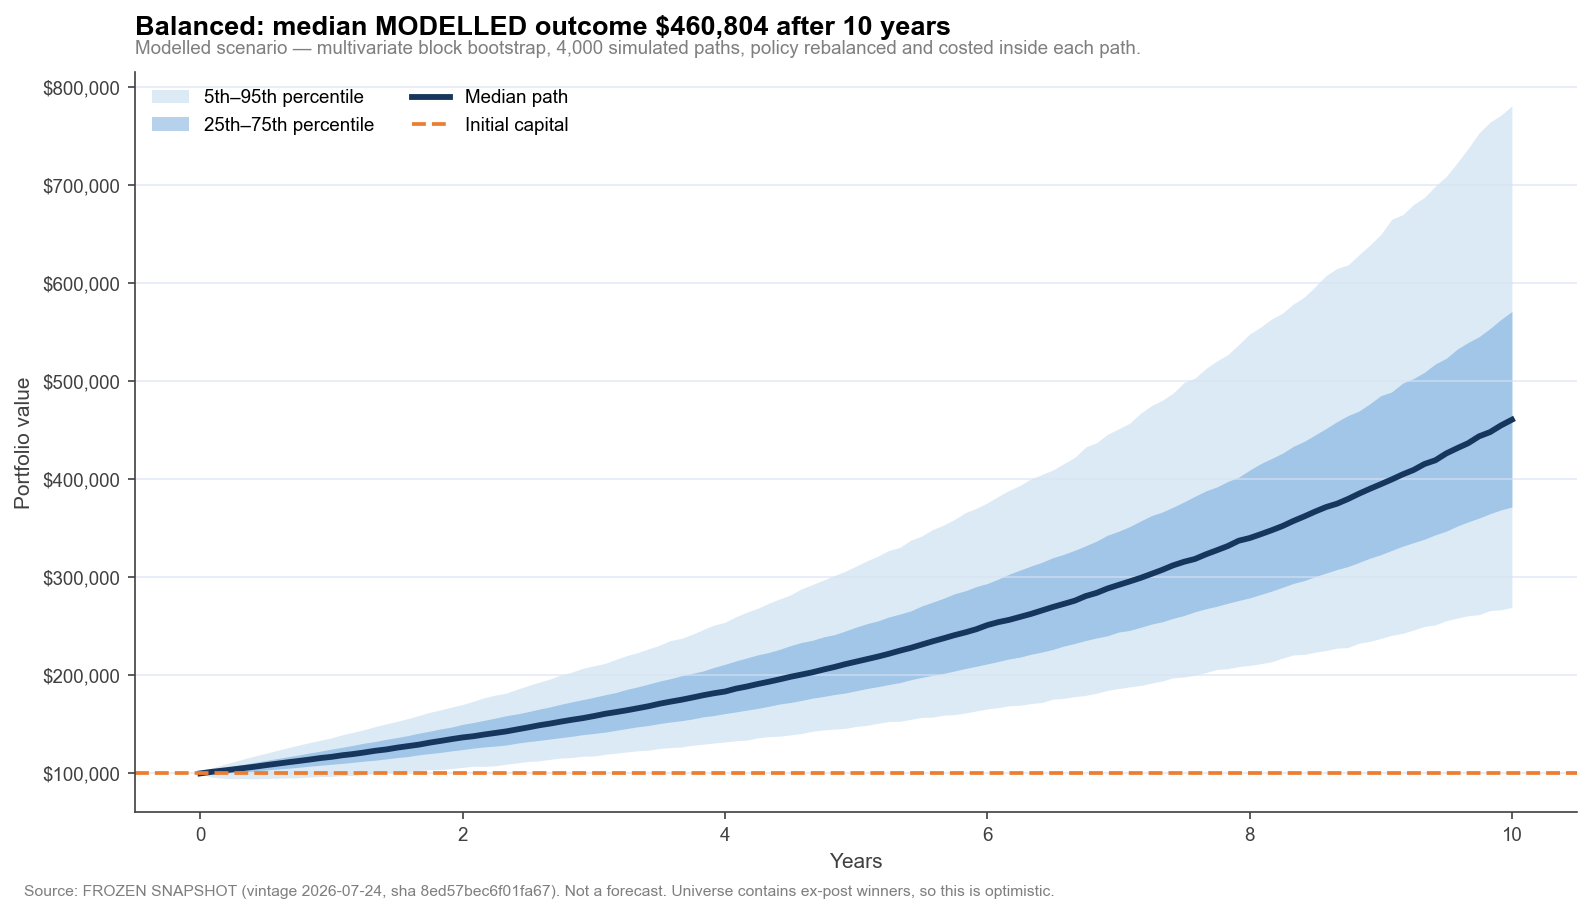

Block-length sensitivity — are the conclusions stable across settings?


Counts are out of 4,000 simulated paths per cell.

Variation in the median outcome across block lengths, by profile:
  Aggressive    0.6% spread — stable
  Balanced      1.5% spread — stable
  Conservative  1.8% spread — stable
Longer blocks retain more serial dependence and volatility clustering, which generally widens
the tails. If a conclusion flips between block lengths, it is a modelling artefact, not a finding.


In [ ]:
# Fan chart + block-length sensitivity across all profiles 
def fan_chart(profile, capital=None):
    capital = capital or CFG["PROJECTION_CAPITAL"]
    cps = projections[profile]["checkpoints"]
    yrs = np.linspace(0, CFG["PROJECTION_HORIZON_YEARS"], cps.shape[1])
    p5, p25, p50, p75, p95 = np.percentile(cps, [5, 25, 50, 75, 95], axis=0)
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    ax.fill_between(yrs, p5, p95, color=LIGHT_BLUE, alpha=0.35, lw=0, label="5th–95th percentile")
    ax.fill_between(yrs, p25, p75, color=BLUE, alpha=0.45, lw=0, label="25th–75th percentile")
    ax.plot(yrs, p50, color=NAVY, lw=2.8, label="Median path")
    ax.axhline(capital, color=ORANGE, lw=1.8, ls="--", label="Initial capital")
    money_axis(ax); ax.set_xlabel("Years"); ax.set_ylabel("Portfolio value")
    ax.legend(loc="upper left", ncol=2)
    m = projections[profile]["metrics"]
    titled(ax, f"{profile}: median MODELLED outcome ${m['Median']:,.0f} after {CFG['PROJECTION_HORIZON_YEARS']} years",
           f"Modelled scenario — multivariate block bootstrap, {m['_n_paths']:,} simulated paths, "
           "policy rebalanced and costed inside each path.",
           f"Source: {DATA_SOURCE}. Not a forecast. Universe contains ex-post winners, so this is optimistic.")
    plt.show()

fan_chart("Balanced")

sens = []
for prof in RISK_PROFILES:
    for L in CFG["BLOCK_LENGTH_SENSITIVITIES"]:
        m = simulate_policy_paths(prof, block_length=L, seed_key=f"sensitivity_{L}")["metrics"]
        sens.append({"Profile": prof, "Block length": L, "Median": m["Median"],
                     "5th pct": m["5th pct"], "95th pct": m["95th pct"],
                     "Paths below capital": m["Paths below capital"],
                     "Paths at least double": m["Paths at least double"],
                     "Median sim. MaxDD": m["Median simulated MaxDD"]})
sensitivity = pd.DataFrame(sens).set_index(["Profile", "Block length"])
print("Block-length sensitivity — are the conclusions stable across settings?")
display(sensitivity.style.format({"Median": money, "5th pct": money, "95th pct": money,
                                  "Paths below capital": "{:,.0f}", "Paths at least double": "{:,.0f}",
                                  "Median sim. MaxDD": "{:.1%}"}))
print(f"Counts are out of {CFG['N_PROJECTION_PATHS']:,} simulated paths per cell.")
_spread = (sensitivity.groupby(level=0)["Median"].max() / sensitivity.groupby(level=0)["Median"].min() - 1)
print("\nVariation in the median outcome across block lengths, by profile:")
for prof, v in _spread.items():
    print(f"  {prof:<13s} {v:.1%} spread — {'stable' if v < 0.10 else 'sensitive to block length'}")
print("Longer blocks retain more serial dependence and volatility clustering, which generally widens")
print("the tails. If a conclusion flips between block lengths, it is a modelling artefact, not a finding.")

In [ ]:
# Automated quality assurance 
qa = []
def check(name, description, condition, value=""):
    qa.append({"Check": name, "Description": description,
               "Value": str(value), "Result": "PASS" if bool(condition) else "FAIL"})

# Data integrity 
check("No missing returns", "Backtest return panel has no NaNs after the start date",
      not strat_ret.isna().any().any(), f"{int(strat_ret.isna().sum().sum())} NaNs")
check("No infinite values", "All returns are finite",
      np.isfinite(strat_ret.to_numpy()).all())
check("No duplicated dates", "Return index has unique, increasing dates",
      (not strat_ret.index.duplicated().any()) and strat_ret.index.is_monotonic_increasing)
check("Common date range", "Every strategy and benchmark uses the identical window",
      all(evals[k]["net_returns"].reindex(common).notna().all() for k in evals),
      f"{common.min().date()} -> {common.max().date()}")

# Risk-free: point-in-time 
_rf_ok, _rf_match = True, True
for s in STRATEGIES:
    a = audits[s]
    if (a["RF obs date"] > a["Rebalance"]).any():
        _rf_ok = False
    for _, row in a.iterrows():
        if abs(rf_at(row["Rebalance"])[0] - row["RF used"]) > 1e-12:
            _rf_match = False
check("RF source date <= rebalance date", "Risk-free observation never postdates the rebalance",
      _rf_ok, f"{sum(len(audits[s]) for s in STRATEGIES)} date pairs checked")
check("RF is point-in-time", "Rate used at each date equals rf_at(date), not a stored constant",
      _rf_match)
check("No full-sample RF average", "CFG risk-free is the LATEST observation, not the sample mean",
      abs(CFG["RISK_FREE_RATE"] - RF_CURRENT) < 1e-15
      and (abs(RF_CURRENT - RF_FULL_SAMPLE_MEAN) > 1e-9 or RF_SERIES.std() < 1e-12),
      f"current {RF_CURRENT:.3%} vs full-sample mean {RF_FULL_SAMPLE_MEAN:.3%}")
check("RF varies over time", "The point-in-time series is not a flat constant",
      float(RF_SERIES.std()) > 0, f"std {RF_SERIES.std():.4%}")

# Rebalance schedule 
check("Rebalance dates are trading dates", "Every selected date exists in the return index",
      bool(REBAL_DATES.isin(daily.index).all()), f"{len(REBAL_DATES)} dates")
check("Final rebalance excluded", "The last dataset date is not used as a rebalance date",
      daily.index.max() not in REBAL_DATES, f"last obs {daily.index.max().date()}")
check("Incomplete final month excluded", "The partial final month is not treated as a month-end",
      bool((SCHEDULE_AUDIT.iloc[-1]["Decision"] != "included")),
      SCHEDULE_AUDIT.iloc[-1]["Decision"][:52])
_empty = sum(e["raw"]["empty_holding_periods"] for e in evals.values())
check("No empty holding periods", "Every rebalance is followed by at least one trading day",
      _empty == 0, f"{_empty} empty")
check("No cost on unused rebalance", "No transaction cost recorded without a holding period",
      all((e["log"].loc[e["log"]["Holding days"] == 0, "Cost paid"].abs() < 1e-15).all()
          for e in evals.values()))

# Look-ahead 
check("Estimation ends by rebalance", "Estimation window never extends past the rebalance date",
      not _leak_est)
check("Holding starts after rebalance", "Holding period begins strictly after the rebalance date",
      not _leak_hold)

# Weights & constraints 
_wsum = max(max(abs(w.sum() - 1) for w in schedules[s].values()) for s in STRATEGIES)
check("Weights sum to 1", "Every target weight vector satisfies the budget constraint",
      _wsum < 1e-6, f"max deviation {_wsum:.2e}")
_bnd = [bool((w > CFG["MAX_WEIGHT"] + 1e-4).any() or (w < -1e-6).any())
        for s in STRATEGIES if s not in ("HRP", "Equal Weight") for w in schedules[s].values()]
check("Bounds & long-only respected", "Optimised strategies stay inside the box constraints",
      not any(_bnd), f"{sum(_bnd)}/{len(_bnd)} violations")
_fb = pd.DataFrame(FALLBACK_LOG)
check("Fallbacks constraint-safe", "Every fallback passed the same validate_weights() as a normal result",
      (len(_fb) == 0) or bool((_fb["Final validation"] == "PASS").all()),
      f"{len(_fb)} fallback(s)")
_sl = pd.DataFrame(SOLVER_LOG)
check("Solver logs have context", "Every solver-log entry carries a rebalance date or section",
      (len(_sl) == 0) or bool(_sl["Rebalance date"].notna().all()), f"{len(_sl)} entries")
check("Covariance symmetric & PSD", "Full-sample covariance is symmetric with non-negative eigenvalues",
      bool(np.allclose(cov_full.to_numpy(), cov_full.to_numpy().T))
      and bool(np.linalg.eigvalsh(cov_full.to_numpy()).min() > -1e-8))
_rc_sum = float(risk_contribution(policy_portfolios["Balanced"]["weights"].to_numpy(), cov_full).sum())
check("Risk contributions sum to 1", "No negative variance in the Euler decomposition",
      abs(_rc_sum - 1.0) < 1e-6, f"{_rc_sum:.8f}")

# Transaction costs 
check("Initial cost reduces wealth", "Net initial wealth is below gross capital when costs are positive",
      COST_TESTS["T1 initial cost reduces wealth"] and COST_TESTS["T2 no double counting"])
check("Zero cost removes reduction", "With a 0bps rate there is no initial wealth reduction",
      COST_TESTS["T3 zero cost -> no reduction"])
check("Gross wealth >= net wealth", "Costless run never ends below the costed run",
      all(e["stats"]["Gross Terminal Wealth"] >= e["stats"]["Net Terminal Wealth"] - 1e-12
          for e in evals.values()))
check("Higher costs never help", "Net CAGR and terminal wealth are non-increasing in the cost rate",
      COST_TESTS["T6 CAGR monotone"] and COST_TESTS["T7 wealth monotone"])
_recon = []
for k, e in evals.items():
    lg = e["log"]
    _recon.append(abs(float((lg["Value before trade"] * lg["Traded notional"] * TRANSACTION_COST_RATE).sum())
                      - e["stats"]["Total Cost ($)"]))
check("Cost total reconciles", "Reported cost equals Σ(pre-trade value × traded notional × rate)",
      max(_recon) < 1e-9, f"max residual {max(_recon):.2e}")
check("Cost metrics reconcile", "Gross wealth − net wealth is consistent with the reported drag",
      all(abs((e["stats"]["Gross Terminal Wealth"] - e["stats"]["Net Terminal Wealth"])
              / e["stats"]["Gross Terminal Wealth"] - e["stats"]["Terminal Wealth Drag"]) < 1e-9
          for e in evals.values()))
check("Portfolio values stay positive", "No simulated portfolio value reaches zero or below",
      all(float(e["net_values"].min()) > 0 for e in evals.values()))

# Reproducibility 
_r1 = multivariate_block_indices(len(daily), 200, 40, 21, new_rng("qa_reproducibility"))
_r2 = multivariate_block_indices(len(daily), 200, 40, 21, new_rng("qa_reproducibility"))
_p1 = simulate_policy_paths("Balanced", n_paths=200, horizon_years=2)["metrics"]["Median"]
_p2 = simulate_policy_paths("Balanced", n_paths=200, horizon_years=2)["metrics"]["Median"]
check("Stochastic output reproducible", "Same seed key produces byte-identical draws and metrics",
      np.array_equal(_r1, _r2) and _p1 == _p2, f"median ${_p1:,.2f} both runs")
try:
    new_rng("an_unregistered_seed_name"); _guard = False
except KeyError:
    _guard = True
check("No hash()-derived seeds", "All seeds are explicit ints; unregistered names are rejected",
      _guard and all(isinstance(v, int) for v in SEEDS.values()), f"{len(SEEDS)} registered seeds")

# Terminology & labelling 
check("No auto-'recommended' label", "Highest-Sharpe strategy is not labelled 'recommended'",
      "RECOMMENDED" not in globals(), f"leader named '{HISTORICAL_SHARPE_LEADER}'")
check("Projections labelled modelled", "Projection outputs are described as simulated/modelled",
      any("simulated" in c.lower() for c in proj_table.columns),
      f"{sum('simulated' in c.lower() for c in proj_table.columns)} labelled columns")
check("Strategy colours consistent", "Every plotted series has a fixed entry in STRATEGY_COLORS",
      all(s in STRATEGY_COLORS for s in strat_ret.columns))

# Frozen data snapshot integrity 
import tempfile
_snap = snapshot_status()
check("Data source reproducible",
      "Results come from a frozen snapshot, or from a window ending in the past",
      IS_FROZEN or CFG["END_DATE"] < date.today().isoformat(),
      f"{DATA_SOURCE[:44]} | vintage {DATA_VINTAGE}")
check("Snapshot hash verified",
      "Prices CSV digest matches the manifest (file not edited after snapshotting)",
      (not PRICES_CSV.exists()) or _snap["usable"] or "HASH MISMATCH" not in _snap["reason"],
      _snap["reason"])
_mcfg = (_snap.get("manifest") or {}).get("config")
check("Snapshot config matches",
      "Snapshot manifest records the current END_DATE and ticker list",
      (not _snap["usable"]) or (_mcfg is None) or (
          _mcfg.get("end") == CFG["END_DATE"] and set(_mcfg.get("tickers", [])) == set(TICKERS)),
      "no manifest — not applicable" if _mcfg is None
      else f"snapshot end {_mcfg.get('end','-')} vs config {CFG['END_DATE']}")
check("No synthetic data persisted",
      "Synthetic prices are in-memory only and never written into data/",
      not (IS_SYNTHETIC and _snap["usable"]),
      "synthetic in use" if IS_SYNTHETIC else "real data in use")
try:
    with tempfile.TemporaryDirectory() as _td:
        write_frozen_csv(prices, Path(_td) / "rt.csv", "qa round-trip")
    _rt_ok = True
except Exception as _e:
    _rt_ok = False
check("CSV round-trip is bitwise exact",
      "Snapshot writer verifies float64 recovery via float_precision='round_trip'",
      _rt_ok, "exact" if _rt_ok else "FAILED — snapshot would corrupt prices")

# Determinism fingerprint 
import hashlib, json
_fp_src = json.dumps({
    "vintage": str(DATA_VINTAGE),
    "perf": {k: round(float(v), 10) for k, v in perf["Sharpe"].items()},
    "cagr": {k: round(float(v), 10) for k, v in perf["CAGR"].items()},
    "proj": {p: round(float(v["metrics"]["Median"]), 6) for p, v in projections.items()},
    "abl": {k: round(float(v), 10) for k, v in ablation["CAGR"].items()},
}, sort_keys=True)
RESULT_FINGERPRINT = hashlib.sha256(_fp_src.encode()).hexdigest()[:16]
check("Deterministic result fingerprint", "SHA-256 of headline results; identical across kernel runs",
      True, RESULT_FINGERPRINT)

qa_df = pd.DataFrame(qa)[["Check", "Description", "Value", "Result"]]
n_fail = int((qa_df["Result"] == "FAIL").sum())
display(qa_df.style.map(lambda v: f"color: {GREEN}; font-weight: bold" if v == "PASS"
                        else (f"color: {RED}; font-weight: bold" if v == "FAIL" else ""),
                        subset=["Result"])
        .set_table_styles([{"selector": "th.col_heading",
                            "props": [("background-color", NAVY), ("color", "white")]}]))
if n_fail == 0:
    print(f"\nQUALITY ASSURANCE: {len(qa_df)}/{len(qa_df)} checks passed.")
else:
    print(f"\nQUALITY ASSURANCE: {len(qa_df)-n_fail}/{len(qa_df)} passed — {n_fail} FAILURE(S):")
    for _, r in qa_df[qa_df["Result"] == "FAIL"].iterrows():
        print(f"   FAIL: {r['Check']} — {r['Description']} ({r['Value']})")
print(f"Result fingerprint: {RESULT_FINGERPRINT}   |   data vintage: {DATA_VINTAGE}")
print("Kernel-restart reproducibility is verified by executing this notebook in a fresh kernel twice")
print("and comparing this fingerprint; the comparison is reported in the changelog, not asserted here.")

,Check,Description,Value,Result
0,No missing returns,Backtest return panel has no NaNs after the start date,0 NaNs,PASS
1,No infinite values,All returns are finite,,PASS
2,No duplicated dates,"Return index has unique, increasing dates",,PASS
3,Common date range,Every strategy and benchmark uses the identical window,2016-02-01 -> 2026-07-24,PASS
4,RF source date <= rebalance date,Risk-free observation never postdates the rebalance,756 date pairs checked,PASS
5,RF is point-in-time,"Rate used at each date equals rf_at(date), not a stored constant",,PASS
6,No full-sample RF average,"CFG risk-free is the LATEST observation, not the sample mean",current 3.960% vs full-sample mean 2.130%,PASS
7,RF varies over time,The point-in-time series is not a flat constant,std 1.9661%,PASS
8,Rebalance dates are trading dates,Every selected date exists in the return index,126 dates,PASS
9,Final rebalance excluded,The last dataset date is not used as a rebalance date,last obs 2026-07-24,PASS



QUALITY ASSURANCE: 39/39 checks passed.
Result fingerprint: bf42baf6357816fa   |   data vintage: 2026-07-24
Kernel-restart reproducibility is verified by executing this notebook in a fresh kernel twice
and comparing this fingerprint; the comparison is reported in the changelog, not asserted here.
